<span style="font-size:2em; font-weight:bold;"> Grenada Rainfall Analysis: Intensity Duration Frequency (IDF) Curve Development - Spatial Distribution of rainfall extremes</span>
***

This code was written to compute the spatial distribution of rainfall extremes across Grenada using the GEV and GPD results of the Bayesian inference. In this regard the following geostatistical analyses are conducted:

1) Variogram/Correlogram Construction on GPD and GEV parameters
2) Variogram/Correlogram construction on various rainfall extremes e.g., Return Period = 5, 10, 25, 50, 75 and 100.
3) Parameters vs. Return Period rainfall extremes correlations with Elevation
4) Cross-variogram/correlogram on Elevation with LMC model
5) Ordinary Kriging
6) Ordinary Cokriging
7) Ordinary Co-located Cokriging using Markov Model 2

It should be noted that this analysis is primarily exploratory with the intent of understanding the spatial variability of the rainfall extremes at various return periods in addition to identification of any possible outlier stations. Map production should be done in a separate notebook once: (a) a general appreciation of the variograms and cross-variograms for rainfall extremes (b) identification of outlier stations (c) selection of preferred geostatistical interpolation techniques.

# 1.0 Import Modules and Data

## 1.1 Import Modules

In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams.update(mpl.rcParamsDefault)
import seaborn as sns
from sklearn.preprocessing import QuantileTransformer
from tqdm.auto import tqdm
from sklearn.metrics import mean_squared_error, mean_absolute_error

# get NZTM coordinates
from pyproj import CRS, Transformer
crs_wgs84 = CRS.from_epsg(4326)
crs_utm20  = CRS.from_epsg(32620)  # UTM Z0N (Grenada coordinate system)
to_proj   = Transformer.from_crs(crs_wgs84, crs_utm20, always_xy=True)

# compute return levels
from return_levels import gev_design_from_summary, gpd_design_from_summary, exceedance_rate_per_year, gev_return_levels_from_posterior, gpd_return_levels_from_posterior

# spatial statistics
from VarioCorreKrigE.variofit import variofit, variofitmulti, crossvariofit
from VarioCorreKrigE.okrig import ordinary_kriging
from VarioCorreKrigE.cckrig import align_lmc_experimental_bins, estimate_collocated_correlation, make_covmodel_spec, search_lmc_model_space, plot_lmc_structures, ordinary_cokriging, OICCK_MM1, OICCK_MM2

## 1.2 Import data

In [2]:
# station names and locations
stations = pd.read_excel(r'Data\GRN_RAINFALL_DATA_NAWASA_2025.xlsx',sheet_name='Raingauge Coordinates')

# imputed rainfall data
grn_rainfall_imput = pd.read_csv(r'Outputs\GRN_RAINFALL_MODELElev_FINAL_n6_thr25mm_var0p25_full.csv')
grn_rainfall_imput['date'] = pd.to_datetime(grn_rainfall_imput['date'], errors='coerce')
grn_rainfall_imput = grn_rainfall_imput.set_index('date').sort_index()

# get thresholds
pots_thr =  pd.read_csv(r'Outputs\pots_thresholds.csv')

# get station names from columns
station_ids = grn_rainfall_imput.columns.tolist()

# Posterior directory
post_dir = Path(r'Outputs\BAYES_MCMC')

# Posterior summary statistics
param_summary = pd.read_csv(post_dir / 'BAYES_MCMC_PARAM_SUMMARY_full.csv')

# grenada elevations
elev = pd.read_csv(r'Data/GRENADA_1970DEM_90M_SMOOTH150m_EPSG32620.xyz', header=None)
elev = elev.rename(columns={0:'X_m', 1:'Y_m', 2:'Elevation'})
elev[['X_km','Y_km']] = elev[['X_m','Y_m']]/1000

# convert station lat/lon to utm
coords_utm = np.array([to_proj.transform(lon, lat) for lon, lat in stations[['Lon', 'Lat']].values])
stations[['X_m','Y_m']] = coords_utm
stations[['X_km','Y_km']] = coords_utm / 1000

# normal-score transformation
x = elev['Elevation'].to_numpy()
x2 = x.reshape(-1, 1)
qt = QuantileTransformer(n_quantiles=30, random_state=0, output_distribution='normal')
x_q = qt.fit_transform(x2).ravel()
elev['Elev_norm'] = x_q

# z-score standardization
elev['Elev_z'] = (elev['Elevation'] - elev['Elevation'].mean())/(elev['Elevation']).std(ddof = 0)

# 2.0 Compute Return levels

## 2.1 Set Return levels and storage dataframe

In [3]:
T = np.array([2, 5, 10, 25, 50, 75, 100])

## 2.2 Run Return levels of summary parameters

In [4]:
rows = []

for sta in station_ids:

    # GPD needs threshold and lambda
    u = pots_thr.loc[pots_thr.station_id == sta, "pots_thr"].iloc[0]
    lam = exceedance_rate_per_year(grn_rainfall_imput[sta], u)

    # Initialise row dicts for this station
    gev_row = {"station": sta, "dist": "GEV"}
    gpd_row = {"station": sta, "dist": "GPD"}

    for T_i in T:

        # GEV
        gev_row[f"TR_{T_i:.0f}_mean"] = float(gev_design_from_summary(param_summary, sta, T_i, quant="mean"))
        gev_row[f"TR_{T_i:.0f}_5"]    = float(gev_design_from_summary(param_summary, sta, T_i, quant="5"))
        gev_row[f"TR_{T_i:.0f}_95"]   = float(gev_design_from_summary(param_summary, sta, T_i, quant="95"))

        # GPD
        gpd_row[f"TR_{T_i:.0f}_mean"] = float(gpd_design_from_summary(param_summary, sta, T_i, u=u, lam_per_year=lam, quant="mean"))
        gpd_row[f"TR_{T_i:.0f}_5"]    = float(gpd_design_from_summary(param_summary, sta, T_i, u=u, lam_per_year=lam, quant="5"))
        gpd_row[f"TR_{T_i:.0f}_95"]   = float(gpd_design_from_summary(param_summary, sta, T_i, u=u, lam_per_year=lam, quant="95"))

    # Add both rows
    rows.append(gev_row)
    rows.append(gpd_row)

# Final wide-format DF
geva_tr = pd.DataFrame(rows)

## 2.3 Run Return levels from posterior

In [5]:
rows = []

for sta in station_ids:

    gev_post = pd.read_csv(post_dir / rf'BAYES_MCMC_PARAMS\{sta}_GEV_full_samples.csv')
    gpd_post = pd.read_csv(post_dir / rf'BAYES_MCMC_PARAMS\{sta}_GPD_full_samples.csv')

    # GPD needs threshold and lambda
    u = pots_thr.loc[pots_thr.station_id == sta, "pots_thr"].iloc[0]
    lam = exceedance_rate_per_year(grn_rainfall_imput[sta], u)

    gev_row = {"station": sta, "dist": "GEV"}
    gpd_row = {"station": sta, "dist": "GPD"}

    # Summaries
    gev_summary = gev_return_levels_from_posterior(T, gev_post, quantiles=(0.05, 0.95))
    gpd_summary = gpd_return_levels_from_posterior(T, gpd_post, u=u, lam_per_year=lam, quantiles=(0.05, 0.95))

    for T_i in T:
        label = f"{T_i:g}"

        mask_gev = gev_summary["T"].astype(float) == float(T_i)
        row_gev = gev_summary.loc[mask_gev].iloc[0]

        gev_row[f"TR_{label}_mean"] = row_gev["mean"]
        gev_row[f"TR_{label}_std"]  = row_gev["std"]
        # gev_row[f"TR_{label}_5"]    = row_gev["q05"]
        # gev_row[f"TR_{label}_95"]   = row_gev["q95"]

        mask_gpd = gpd_summary["T"].astype(float) == float(T_i)
        row_gpd = gpd_summary.loc[mask_gpd].iloc[0]

        gpd_row[f"TR_{label}_mean"] = row_gpd["mean"]
        gpd_row[f"TR_{label}_std"]  = row_gpd["std"]
        # gpd_row[f"TR_{label}_5"]    = row_gpd["q05"]
        # gpd_row[f"TR_{label}_95"]   = row_gpd["q95"]

    rows.append(gev_row)
    rows.append(gpd_row)

geva_tr_post = pd.DataFrame(rows)

# 3.0 Correlation matrix of extremes

## 3.1 Parameters

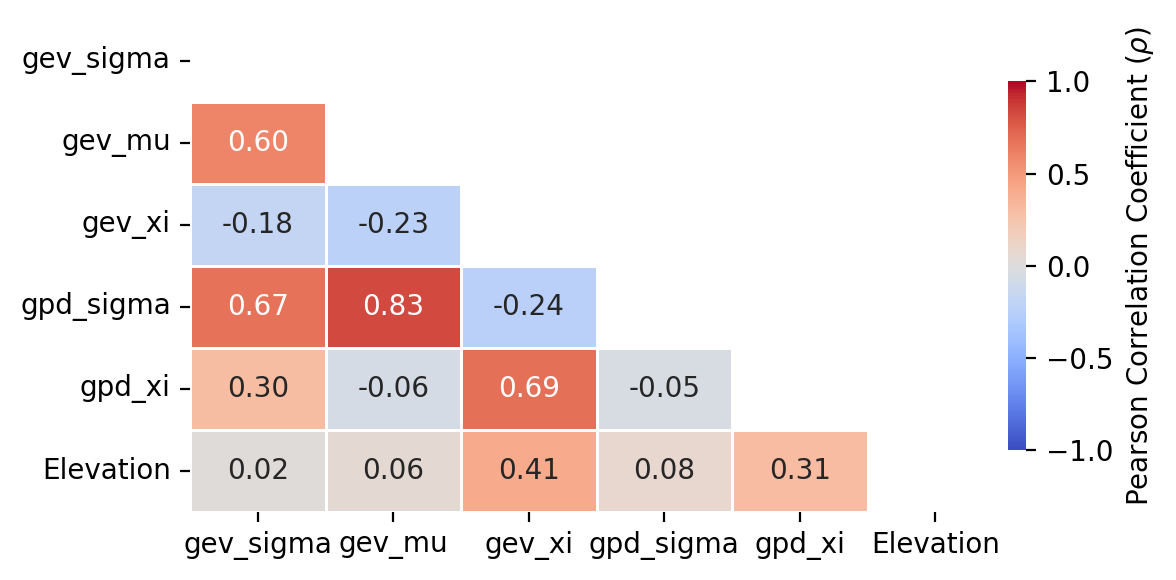

In [6]:
stations = stations.rename(columns={'Stations': 'station_id'})
param_summary_ext = param_summary.merge(stations, on='station_id')

df_corr = param_summary_ext[['gev_sigma', 'gev_mu', 'gev_xi', 'gpd_sigma', 'gpd_xi', 'Elevation']]
corr = df_corr.corr()

# Upper triangle mask
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(6, 3), dpi=200)
ax = sns.heatmap(
    corr, mask=mask, cmap="coolwarm", vmin=-1, vmax=1, center=0,
    annot=True, fmt=".2f", linewidths=0.5,
    cbar_kws={"shrink": 0.75, "pad": 0.005}
)

cbar = ax.collections[0].colorbar
cbar.set_label(r'Pearson Correlation Coefficient ($\rho$)', fontsize=10)
plt.tight_layout()
plt.show()

## 3.2 Rainfall extremes

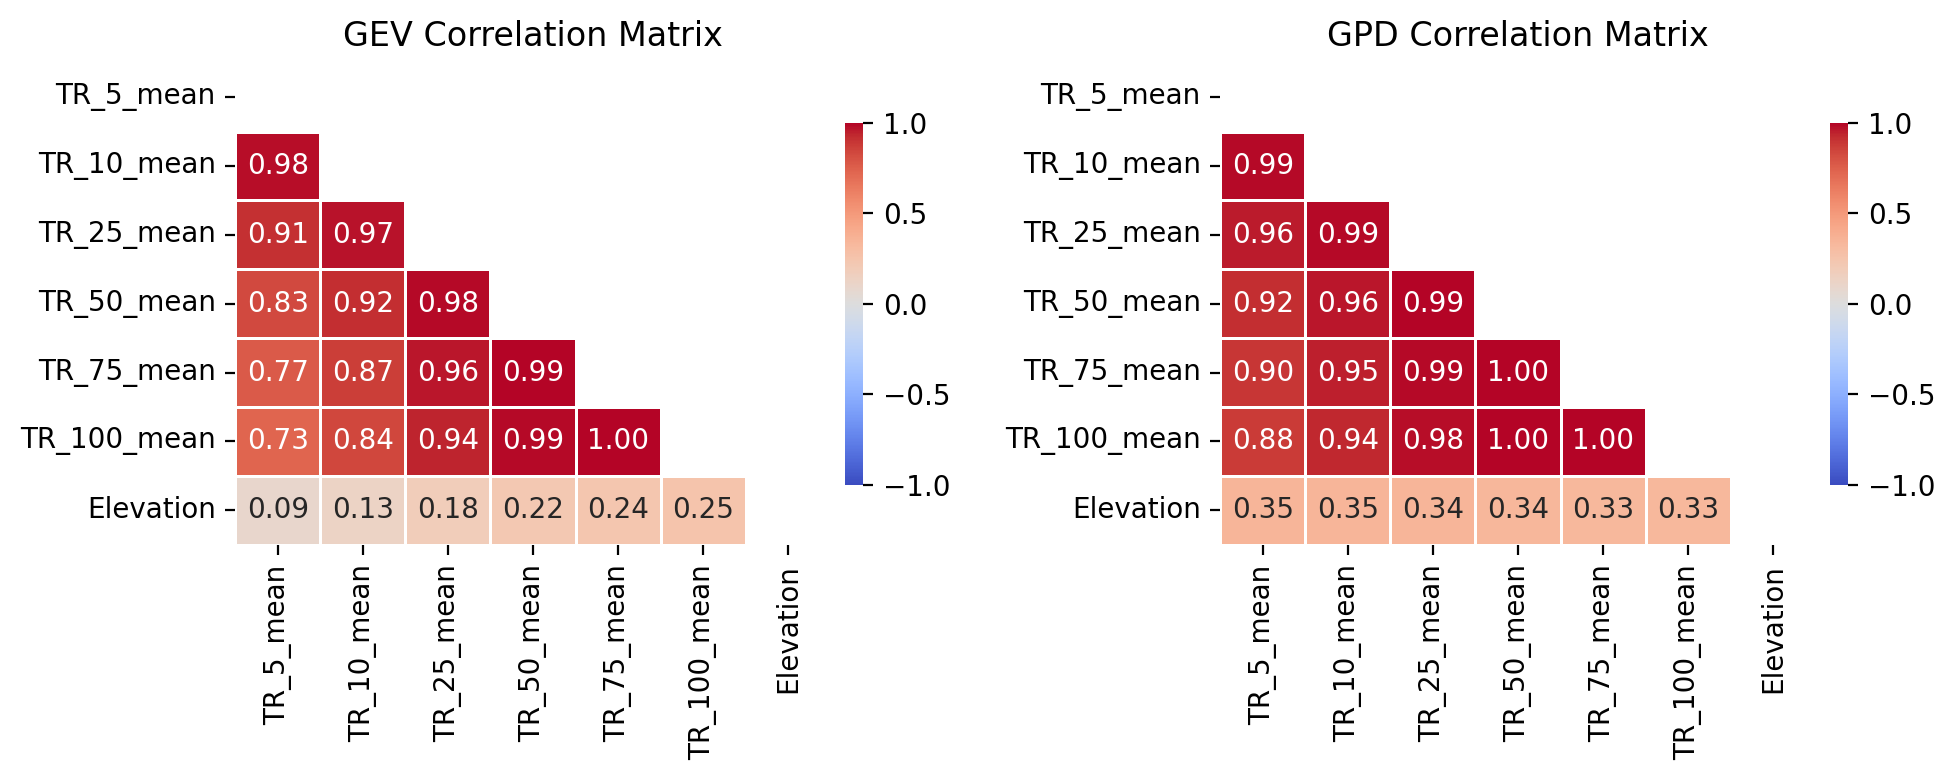

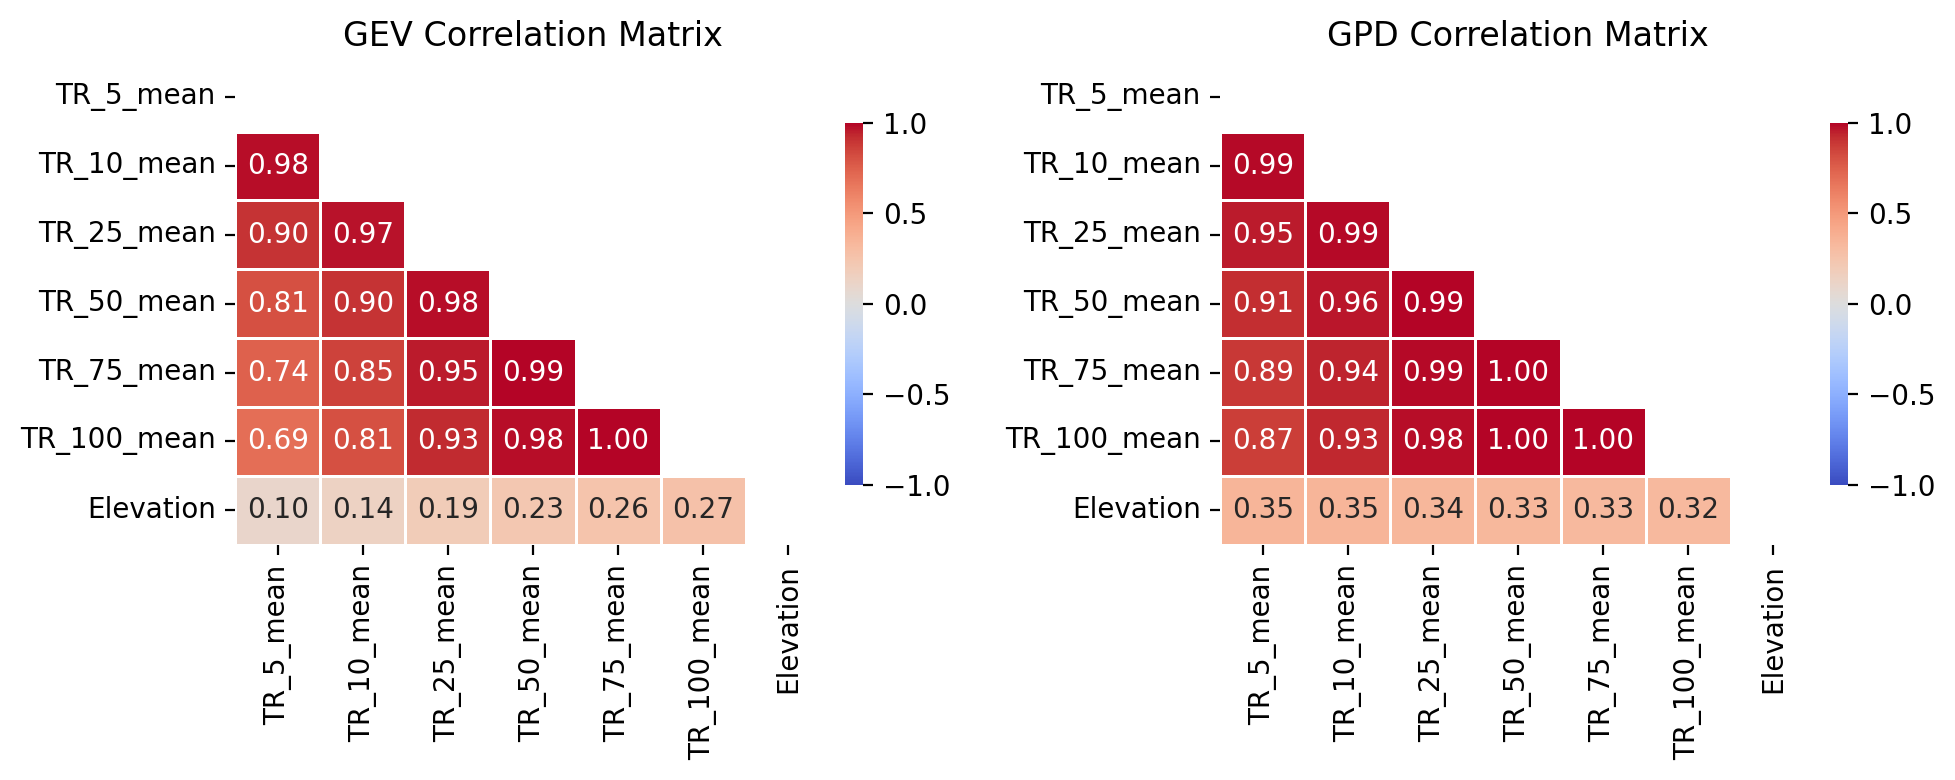

In [7]:
stations = stations.rename(columns={'station_id': 'station'})
geva_tr = geva_tr.merge(stations, on='station')
geva_tr_post = geva_tr_post.merge(stations, on='station')

gev_only     = geva_tr[geva_tr.dist == "GEV"]
gpd_only     = geva_tr[geva_tr.dist == "GPD"]

gev_only_post = geva_tr_post[geva_tr_post.dist == "GEV"]
gpd_only_post = geva_tr_post[geva_tr_post.dist == "GPD"]

cols = ['TR_5_mean', 'TR_10_mean', 'TR_25_mean',
        'TR_50_mean', 'TR_75_mean', 'TR_100_mean', 'Elevation']

df_corr_gev     = gev_only[cols].corr()
df_corr_gpd     = gpd_only[cols].corr()

df_corr_gev_post = gev_only_post[cols].corr()
df_corr_gpd_post = gpd_only_post[cols].corr()

mask = np.triu(np.ones_like(df_corr_gev, dtype=bool))

fig, axes = plt.subplots(1, 2, figsize=(10, 4), dpi=200)

sns.heatmap(df_corr_gev, mask=mask, cmap="coolwarm", vmin=-1, vmax=1, center=0,
            annot=True, fmt=".2f", linewidths=0.5,
            cbar_kws={"shrink": 0.75, "pad": 0.02},
            ax=axes[0])
axes[0].set_title("GEV Correlation Matrix")

sns.heatmap(df_corr_gpd, mask=mask, cmap="coolwarm", vmin=-1, vmax=1, center=0,
            annot=True, fmt=".2f", linewidths=0.5,
            cbar_kws={"shrink": 0.75, "pad": 0.02},
            ax=axes[1])
axes[1].set_title("GPD Correlation Matrix")

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(10, 4), dpi=200)

sns.heatmap(df_corr_gev_post, mask=mask, cmap="coolwarm", vmin=-1, vmax=1, center=0,
            annot=True, fmt=".2f", linewidths=0.5,
            cbar_kws={"shrink": 0.75, "pad": 0.02},
            ax=axes[0])
axes[0].set_title("GEV Correlation Matrix")

sns.heatmap(df_corr_gpd_post, mask=mask, cmap="coolwarm", vmin=-1, vmax=1, center=0,
            annot=True, fmt=".2f", linewidths=0.5,
            cbar_kws={"shrink": 0.75, "pad": 0.02},
            ax=axes[1])
axes[1].set_title("GPD Correlation Matrix")

plt.tight_layout()
plt.show()

# 4.0 Variogram and cross-variograms for rainfall extremes: mean

## 4.1 Z-score standardize rainfall extremes

In [8]:
remove_err_sta = False

err_sta = ["Bon Accord (WTP)", "Grand Etang (LAKE)", "Clozier (Tank)","Plaisance (WTP)" ,"Munich (WTP)"]
if remove_err_sta:
    geva_tr_post = geva_tr_post[~geva_tr_post.station.isin(err_sta)].reset_index(drop = True)

gev_long = pd.melt(
    geva_tr_post[geva_tr_post.dist == 'GEV'],
    id_vars=['station','X_m','Y_m','X_km','Y_km','Elevation_150m'],
    value_vars=[
        'TR_5_mean','TR_10_mean','TR_25_mean','TR_50_mean','TR_75_mean','TR_100_mean',
        'TR_5_std','TR_10_std','TR_25_std','TR_50_std','TR_75_std','TR_100_std'
    ],
    var_name='T_label',
    value_name='TR_value'
)

gpd_long = pd.melt(
    geva_tr_post[geva_tr_post.dist == 'GPD'],
    id_vars=['station','X_m','Y_m','X_km','Y_km','Elevation_150m'],
    value_vars=[
        'TR_5_mean','TR_10_mean','TR_25_mean','TR_50_mean','TR_75_mean','TR_100_mean',
        'TR_5_std','TR_10_std','TR_25_std','TR_50_std','TR_75_std','TR_100_std'
    ],
    var_name='T_label',
    value_name='TR_value'
)

gev_long['TR'] = gev_long['T_label'].str.extract(r'(\d+)').astype(int)
gpd_long['TR'] = gpd_long['T_label'].str.extract(r'(\d+)').astype(int)

gev_long['var_type'] = gev_long['T_label'].str.extract(r'_(mean|std)$')
gpd_long['var_type'] = gpd_long['T_label'].str.extract(r'_(mean|std)$')

gev_long = gev_long.pivot_table(
    index=['station','X_m','Y_m','X_km','Y_km','Elevation_150m','TR'],
    columns='var_type',
    values='TR_value'
).reset_index()

gpd_long = gpd_long.pivot_table(
    index=['station','X_m','Y_m','X_km','Y_km','Elevation_150m','TR'],
    columns='var_type',
    values='TR_value'
).reset_index()

gev_long = gev_long.rename(columns={'mean':'TR_mean', 'std':'TR_std'})
gpd_long = gpd_long.rename(columns={'mean':'TR_mean', 'std':'TR_std'})

# z-score standardization
gev_long['TR_z'] = gev_long.groupby('TR')['TR_mean'].transform(lambda x: (x - x.mean()) / x.std(ddof=0))
gpd_long['TR_z'] = gpd_long.groupby('TR')['TR_mean'].transform(lambda x: (x - x.mean()) / x.std(ddof=0))
gev_long['TR_std_z'] = gev_long.groupby('TR')['TR_std'].transform(lambda x: (x - x.mean()) / x.std(ddof=0))
gpd_long['TR_std_z'] = gpd_long.groupby('TR')['TR_std'].transform(lambda x: (x - x.mean()) / x.std(ddof=0))

# Elevation z-score standardization
mu_elev = geva_tr_post['Elevation_150m'].mean()
sig_elev = geva_tr_post['Elevation_150m'].std(ddof=0)
gev_long['Elev_z'] = (gev_long['Elevation_150m'] - mu_elev) / sig_elev
gpd_long['Elev_z'] = (gpd_long['Elevation_150m'] - mu_elev) / sig_elev

# Elevation normal-score
elev_unique = geva_tr_post[['station', 'Elevation_150m']].drop_duplicates()
x = elev_unique['Elevation_150m'].to_numpy().reshape(-1, 1)
qt = QuantileTransformer(
    n_quantiles=28,
    random_state=0,
    output_distribution='normal'
)
elev_unique['Elev_norm'] = qt.fit_transform(x).ravel()
gev_long = gev_long.merge(elev_unique[['station','Elev_norm']], on='station', how='left')
gpd_long = gpd_long.merge(elev_unique[['station','Elev_norm']], on='station', how='left')

# selected return periods for variograms/correlograms cross-variograms
TR_5_gpd = gpd_long[gpd_long.TR==5].reset_index(drop = True)
TR_10_gpd = gpd_long[gpd_long.TR==10].reset_index(drop = True)
TR_25_gpd = gpd_long[gpd_long.TR==25].reset_index(drop = True)
TR_50_gpd = gpd_long[gpd_long.TR==50].reset_index(drop = True)
TR_5_gev = gev_long[gev_long.TR==5].reset_index(drop = True)
TR_10_gev = gev_long[gev_long.TR==10].reset_index(drop = True)
TR_25_gev = gev_long[gev_long.TR==25].reset_index(drop = True)
TR_50_gev = gev_long[gev_long.TR==50].reset_index(drop = True)

## 4.2 Rainfall mean extremes variograms

### 4.2.1 Multi-variograms across all return periods (TR)

Fitting groups:   0%|          | 0/6 [00:00<?, ?it/s]

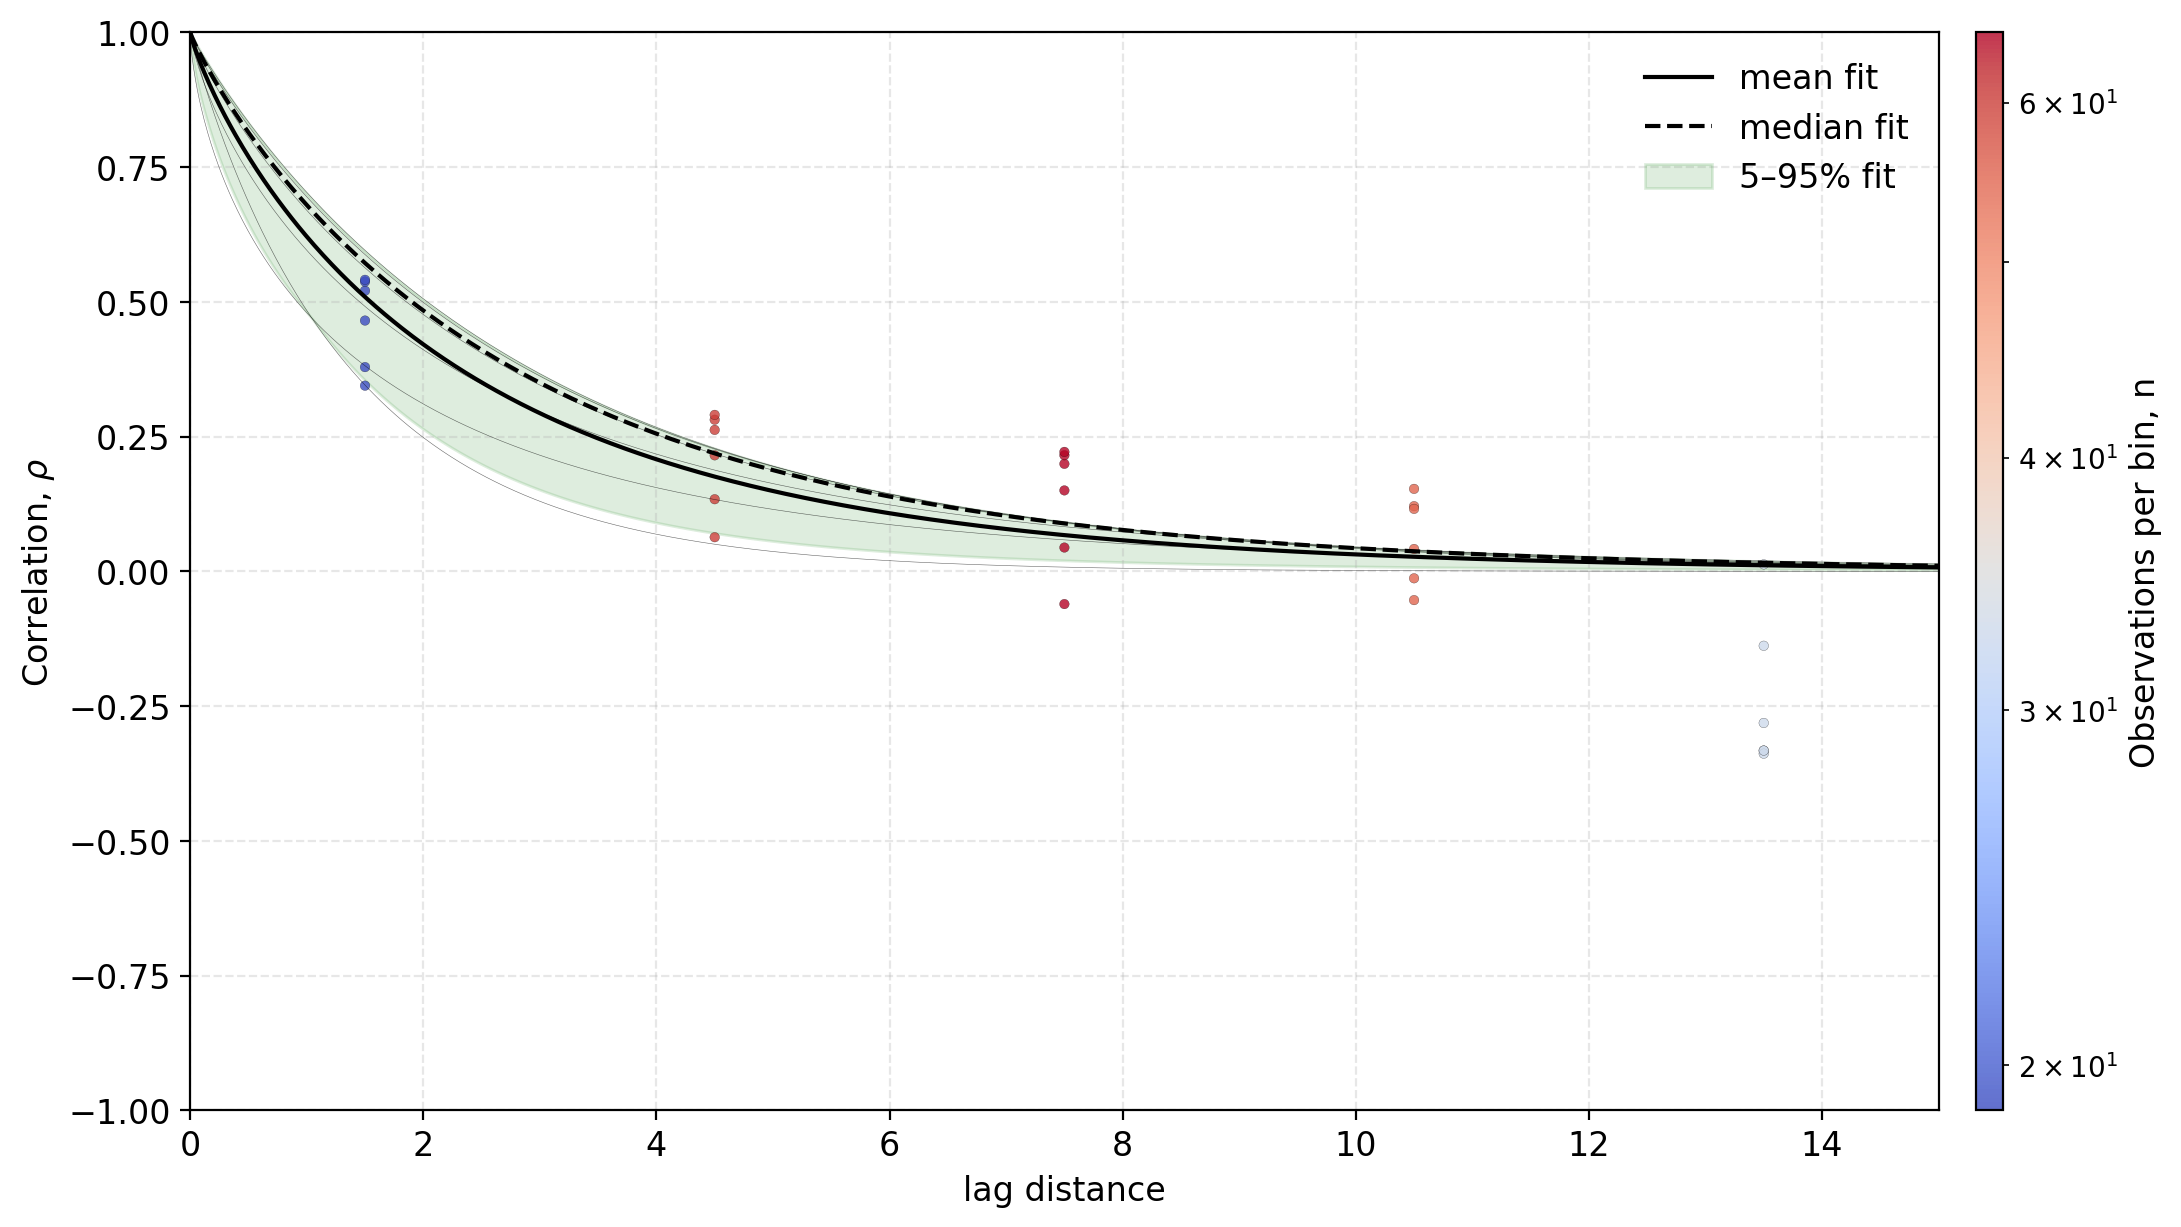

Fitting groups:   0%|          | 0/6 [00:00<?, ?it/s]

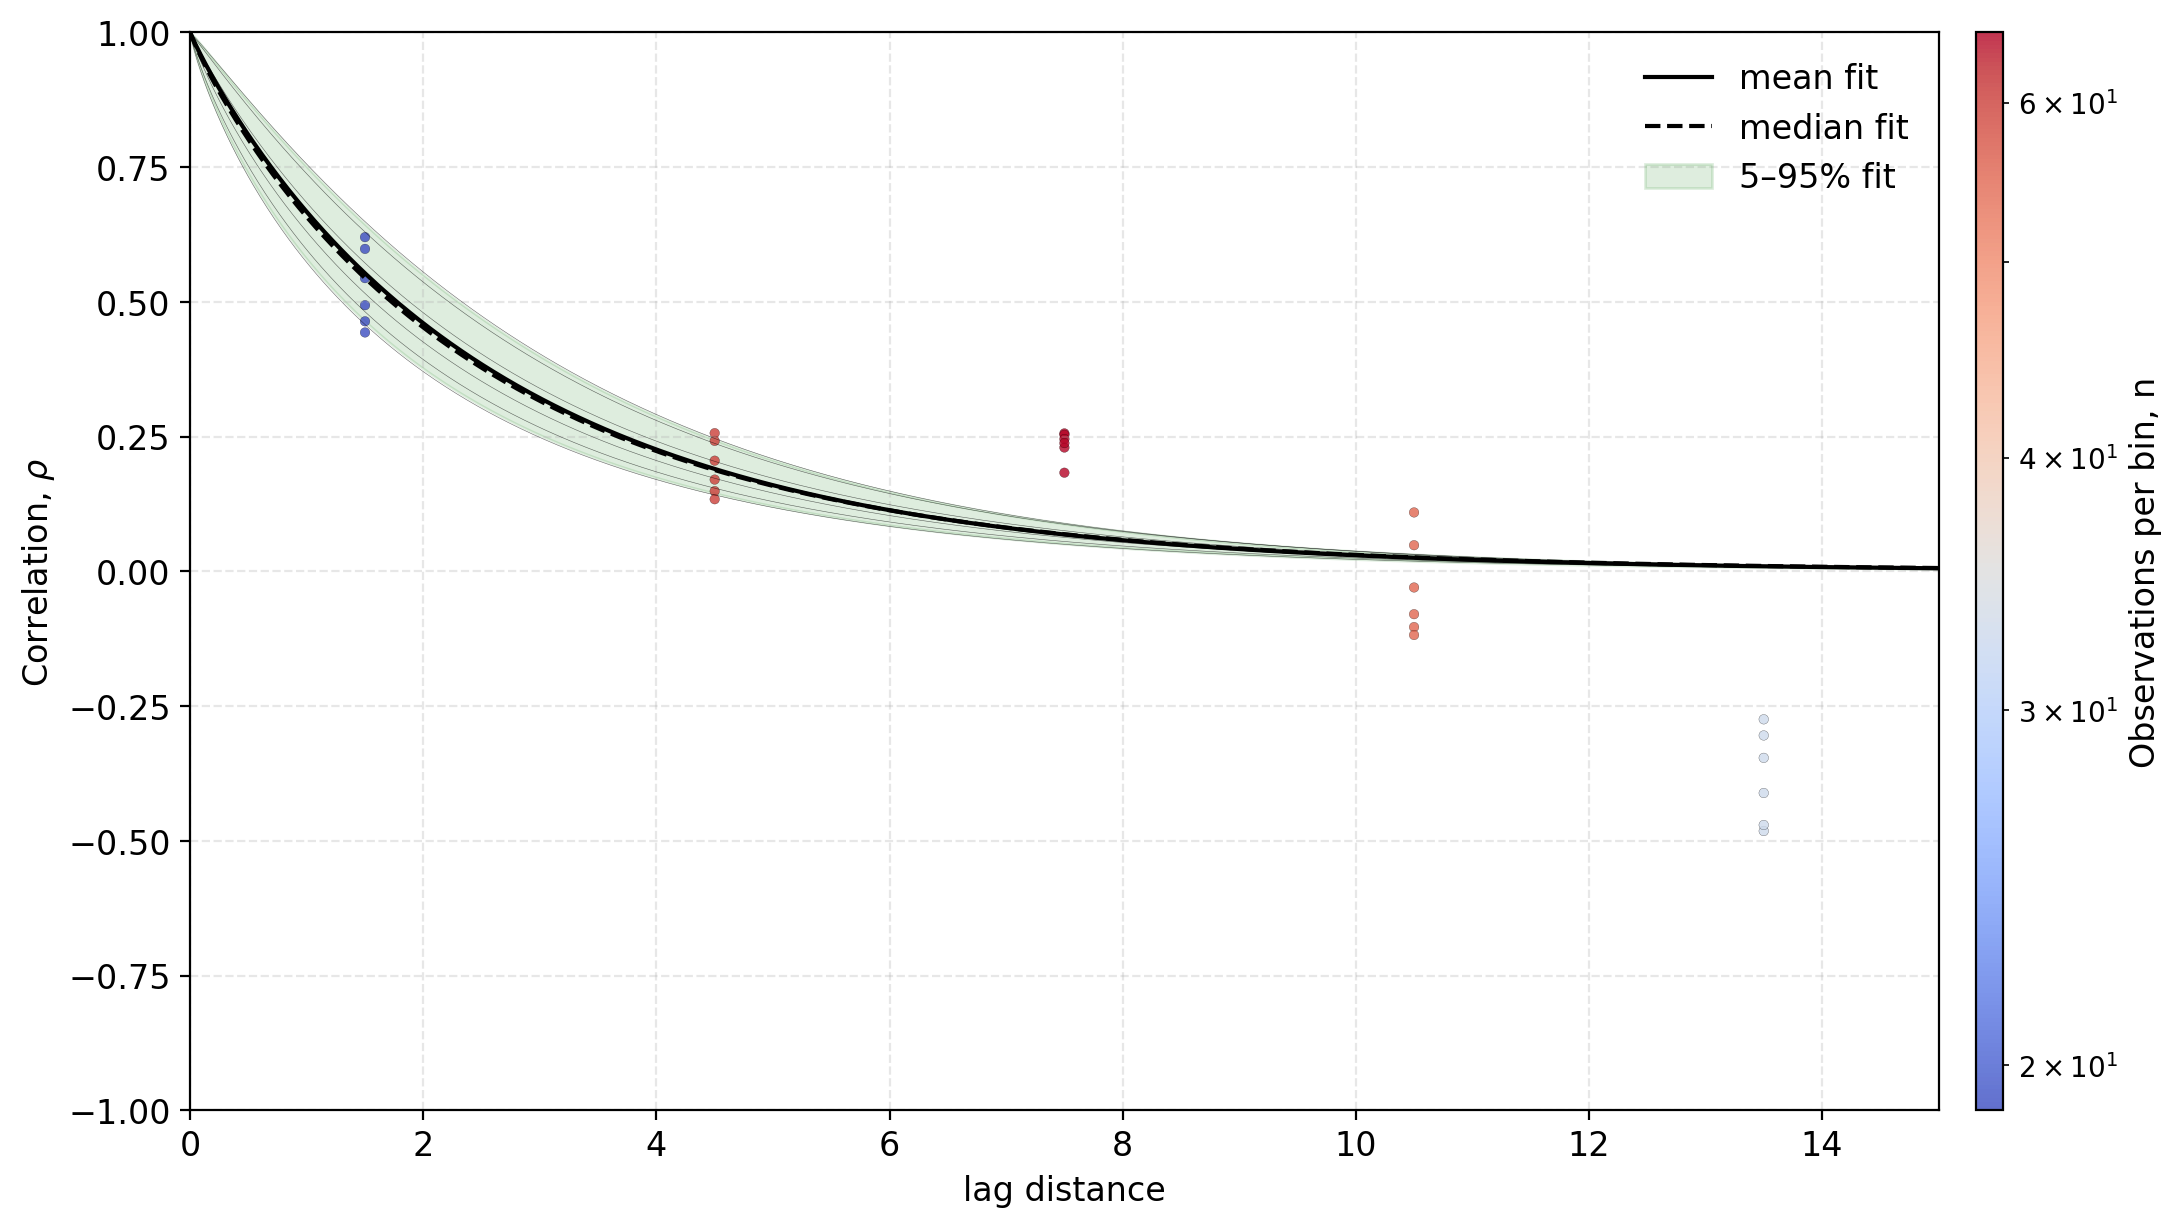

In [304]:
# specify fitting parameters
estimator = "Matheron"
model = "powered_exponential"
weight_fn = None
weight_params = None
xmax_factor = 2

summary_gev, df_n_obs, df_gamma, results = variofitmulti(
    df=gev_long,
    values_col="TR_z",
    index_col="TR",
    coord_cols=("X_km","Y_km"),
    distance_type="cartesian",
    max_distance=15,
    bin_size=3,
    estimator_type=estimator,
    model_type=model,
    weight_fn=weight_fn,
    weight_params = weight_params,
    xmax_factor=xmax_factor,
    fix_sill= True,
    plot_single=False,
    plot_summary=True,
    transform="correlation"
)

summary_gpd, df_n_obs, df_gamma, results = variofitmulti(
    df=gpd_long,
    values_col="TR_z",
    index_col="TR",
    coord_cols=("X_km","Y_km"),
    distance_type="cartesian",
    max_distance=15,
    bin_size=3,
    estimator_type=estimator,
    model_type=model,
    weight_fn=weight_fn,
    weight_params = weight_params,
    xmax_factor=xmax_factor,
    fix_sill= True,
    plot_single=False,
    plot_summary=True,
    transform="correlation"
)

### 4.2.2 Single variograms: GPD

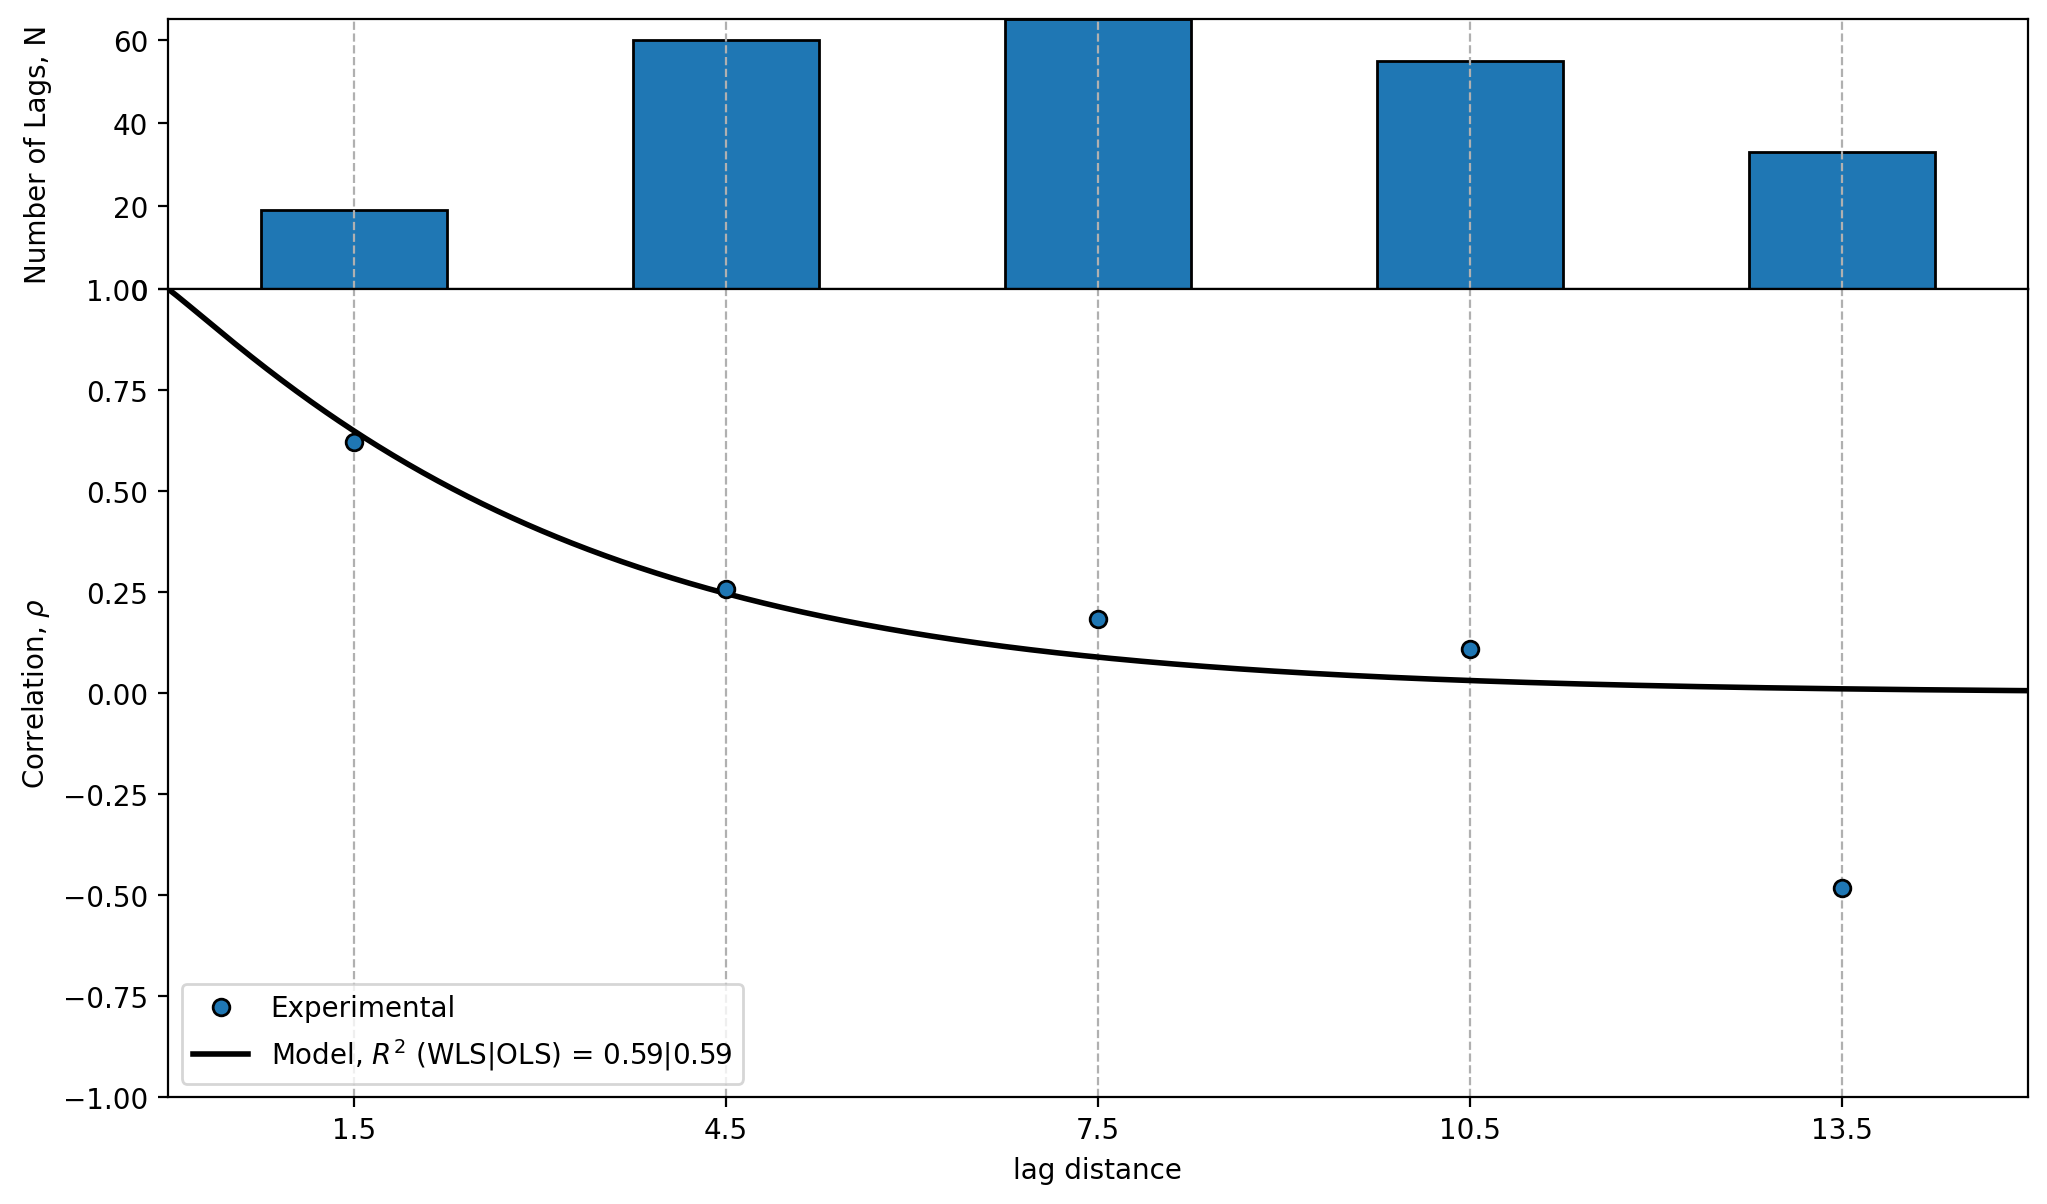

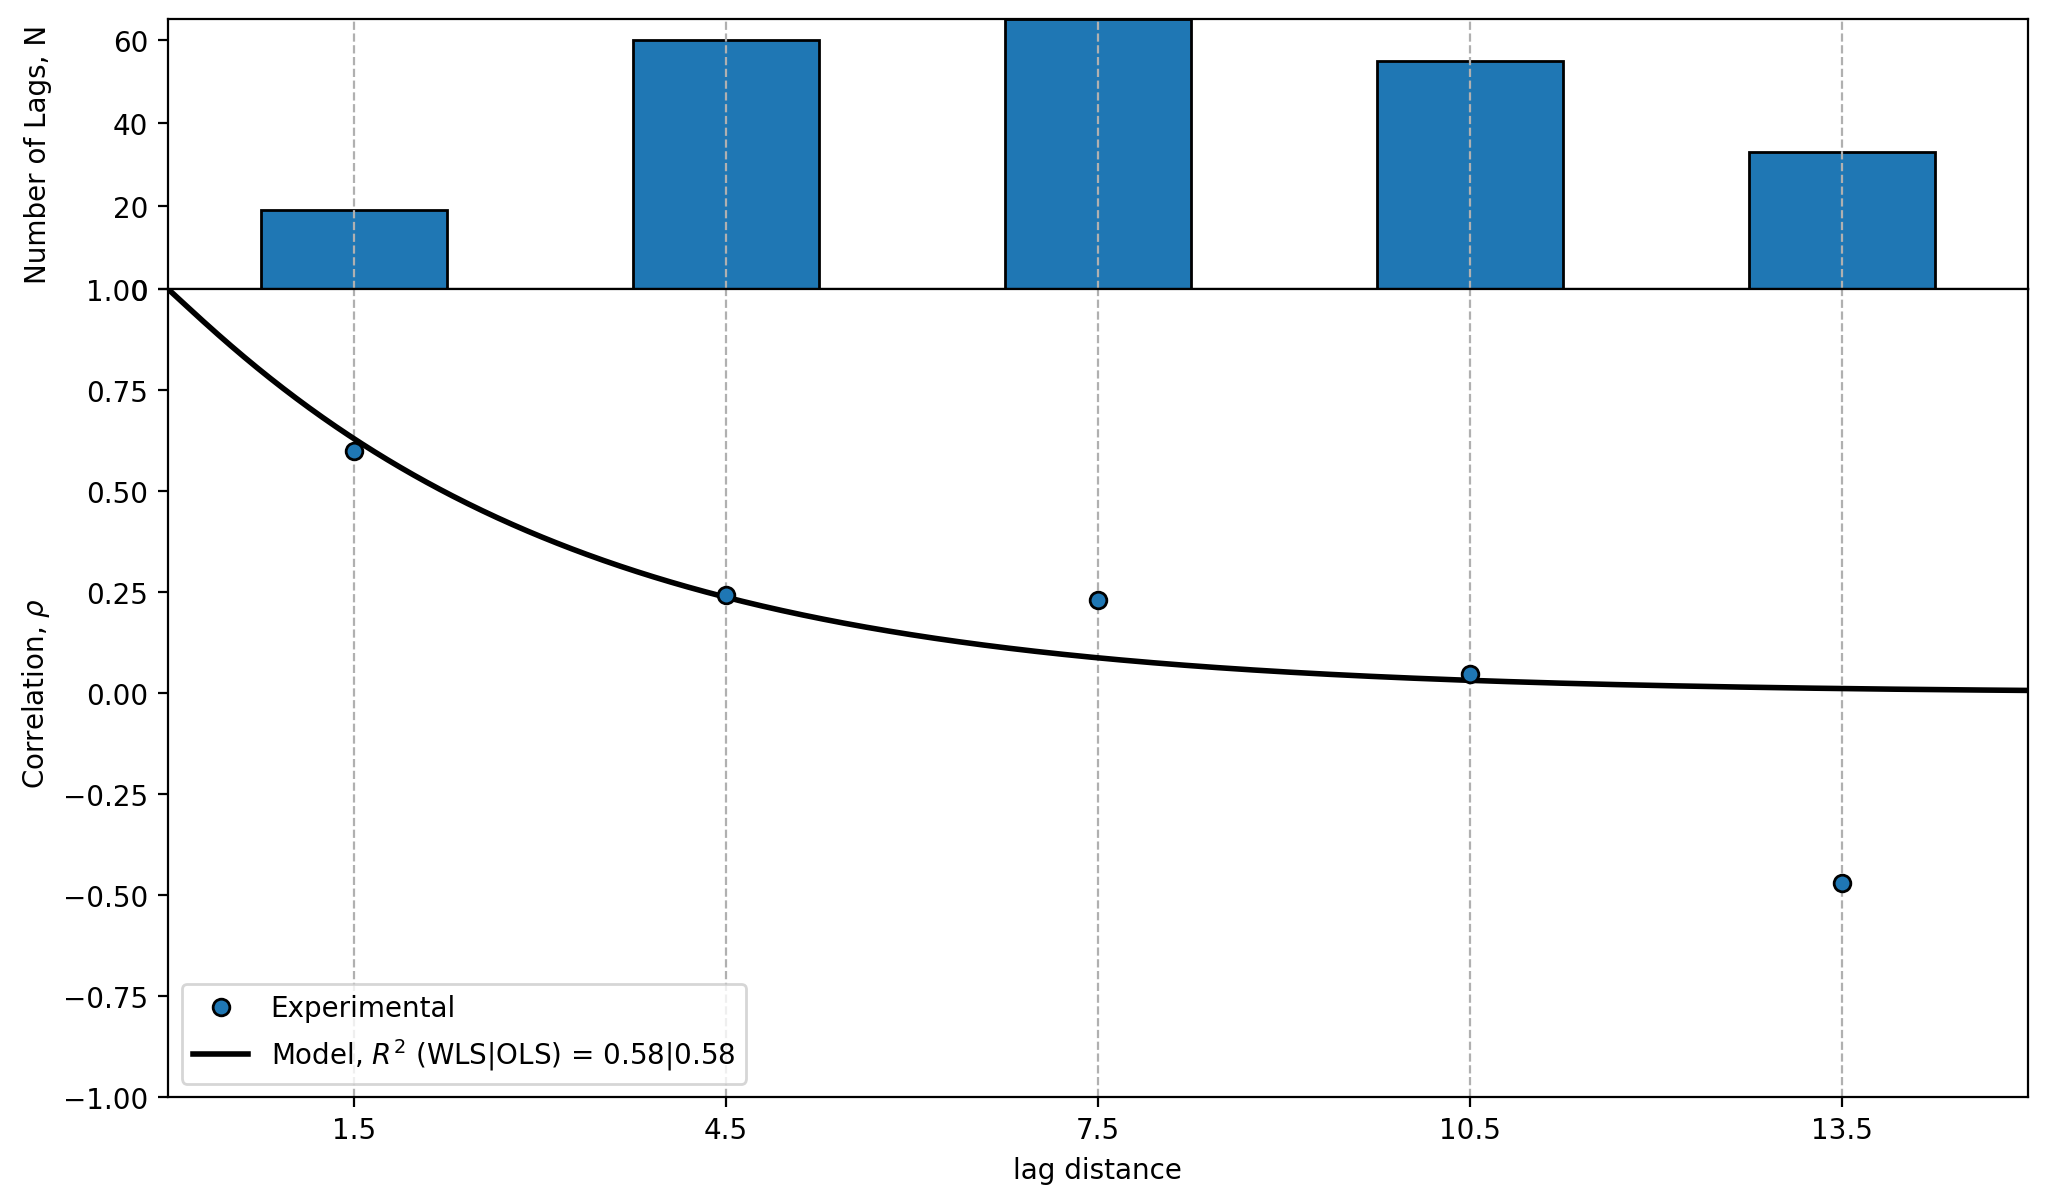

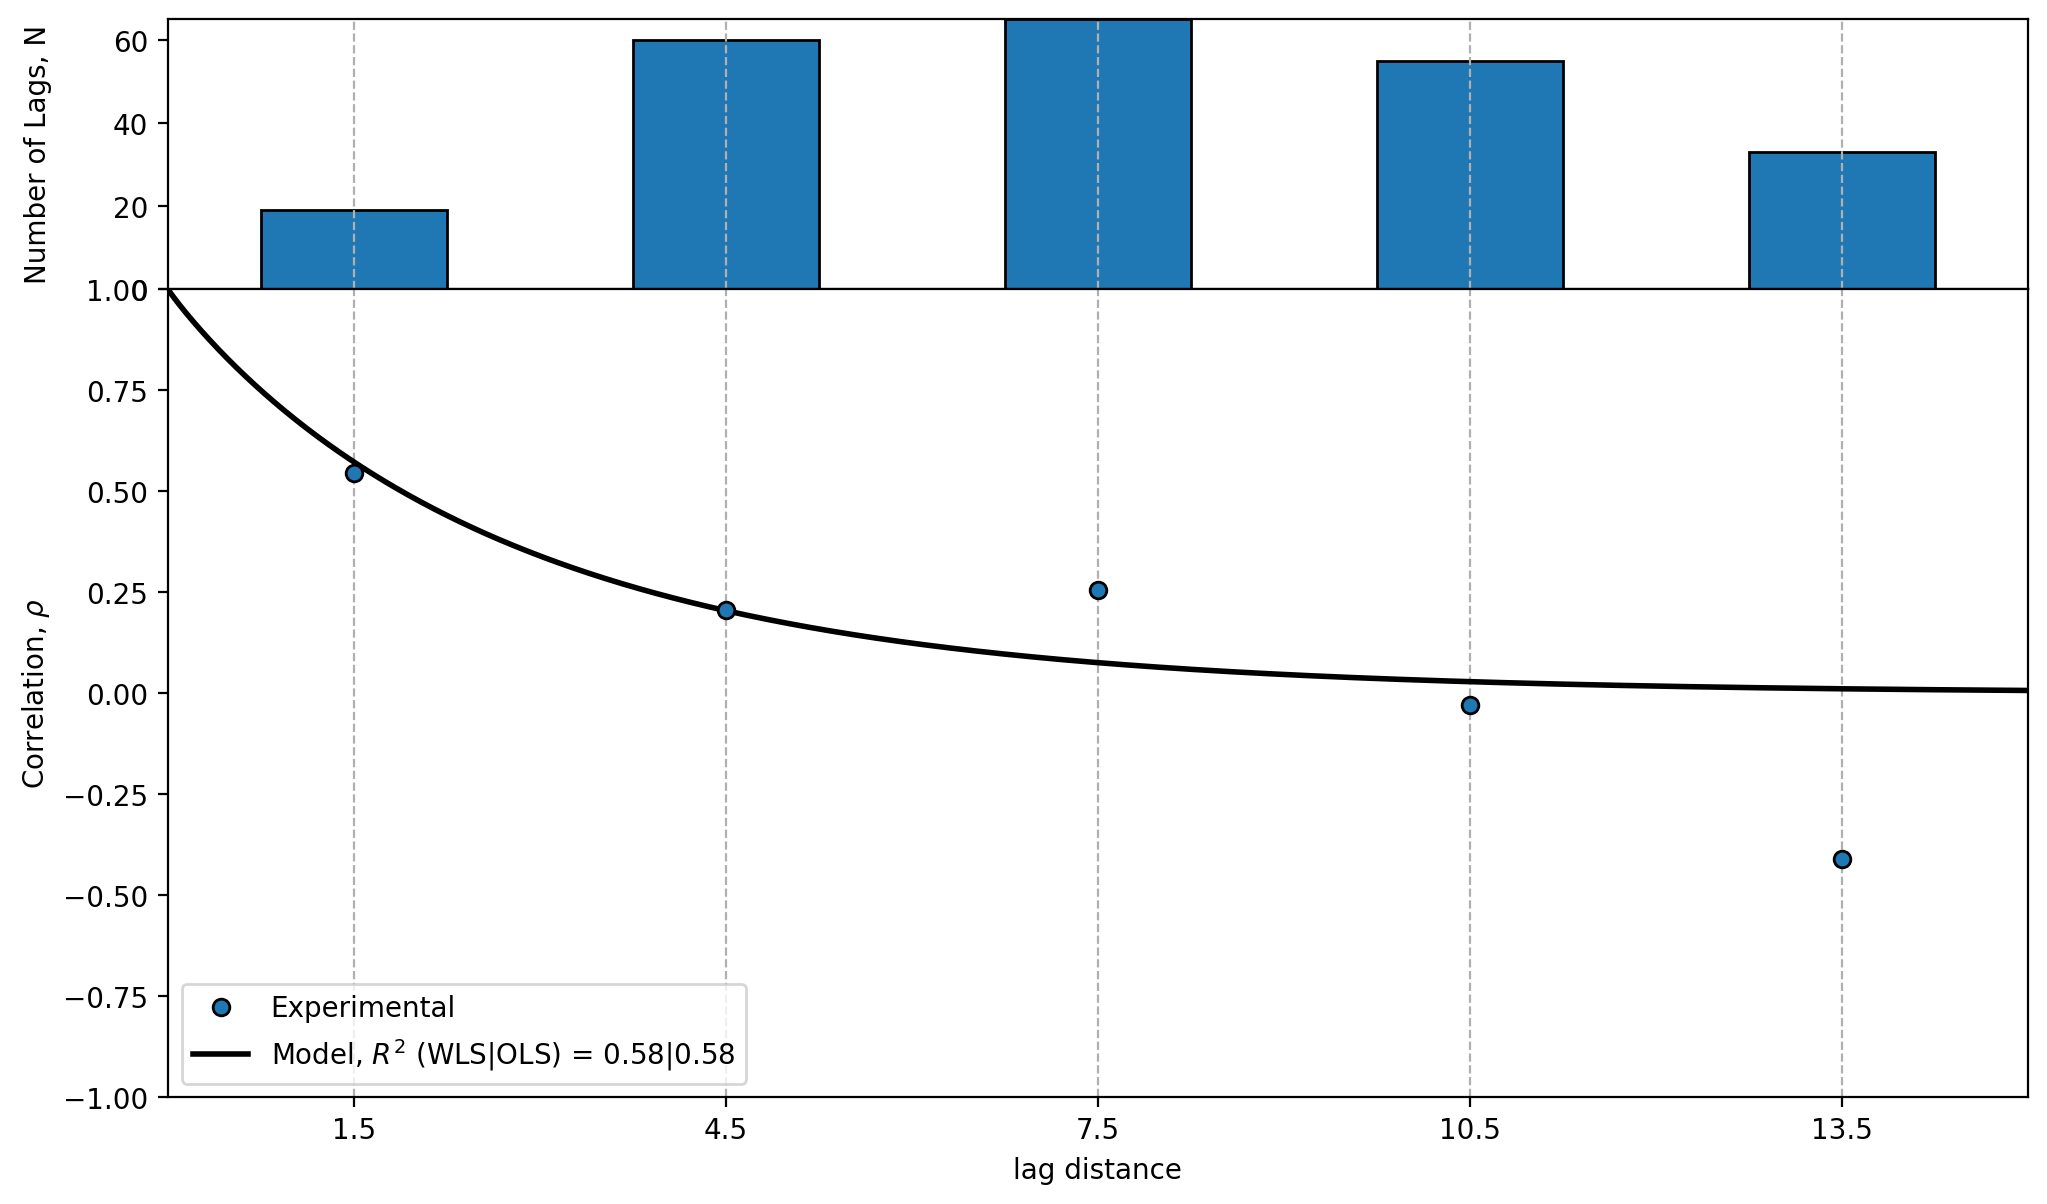

In [305]:
# specify fitting parameters
estimator = "Matheron"
model = "powered_exponential"
weight_fn = None
weight_params = None
xmax_factor = 2

_, _, _, params_tr5_gpd, _, _ = variofit(values = TR_5_gpd['TR_z'], coordinates = TR_5_gpd[['X_km','Y_km']], distance_type = 'cartesian', max_distance = 15, bin_size = 3, estimator_type= estimator, model_type = model, weight_fn = weight_fn, weight_params = weight_params, xmax_factor=xmax_factor, fix_sill = True, plot = True, transform="correlation")

_, _, _, params_tr10_gpd, _, _ = variofit(values = TR_10_gpd['TR_z'], coordinates = TR_10_gpd[['X_km','Y_km']], distance_type = 'cartesian', max_distance = 15, bin_size = 3, estimator_type= estimator, model_type = model, weight_fn = weight_fn, weight_params = weight_params, xmax_factor=xmax_factor, fix_sill = True, plot = True, transform="correlation")

_, _, _, params_tr25_gpd, _, _ = variofit(values = TR_25_gpd['TR_z'], coordinates = TR_25_gpd[['X_km','Y_km']], distance_type = 'cartesian', max_distance = 15, bin_size = 3, estimator_type= estimator, model_type = model, weight_fn = weight_fn, weight_params = weight_params, xmax_factor=xmax_factor, fix_sill = True, plot = True, transform="correlation")

### 4.2.3 Single variograms: GEV

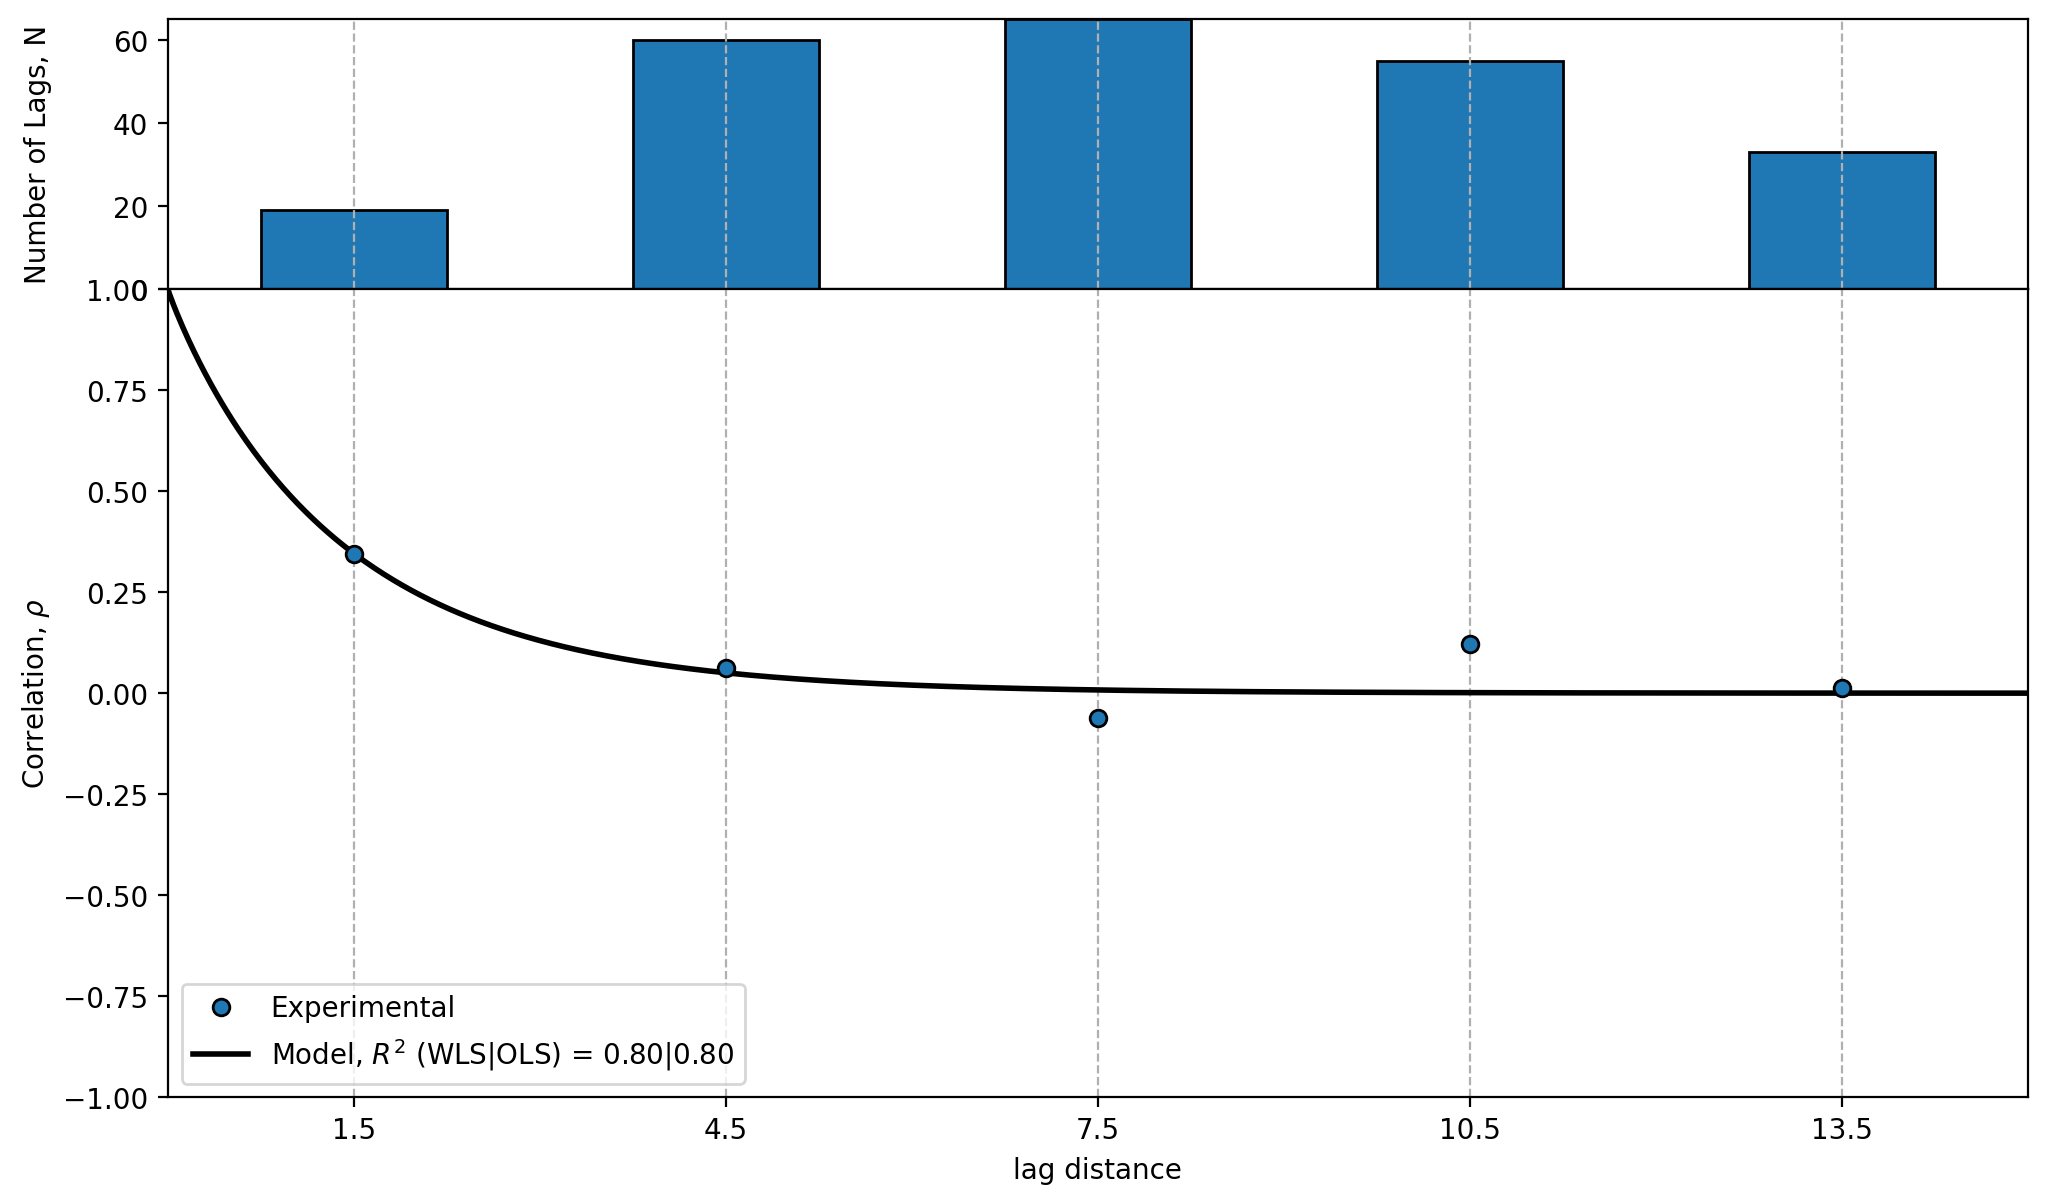

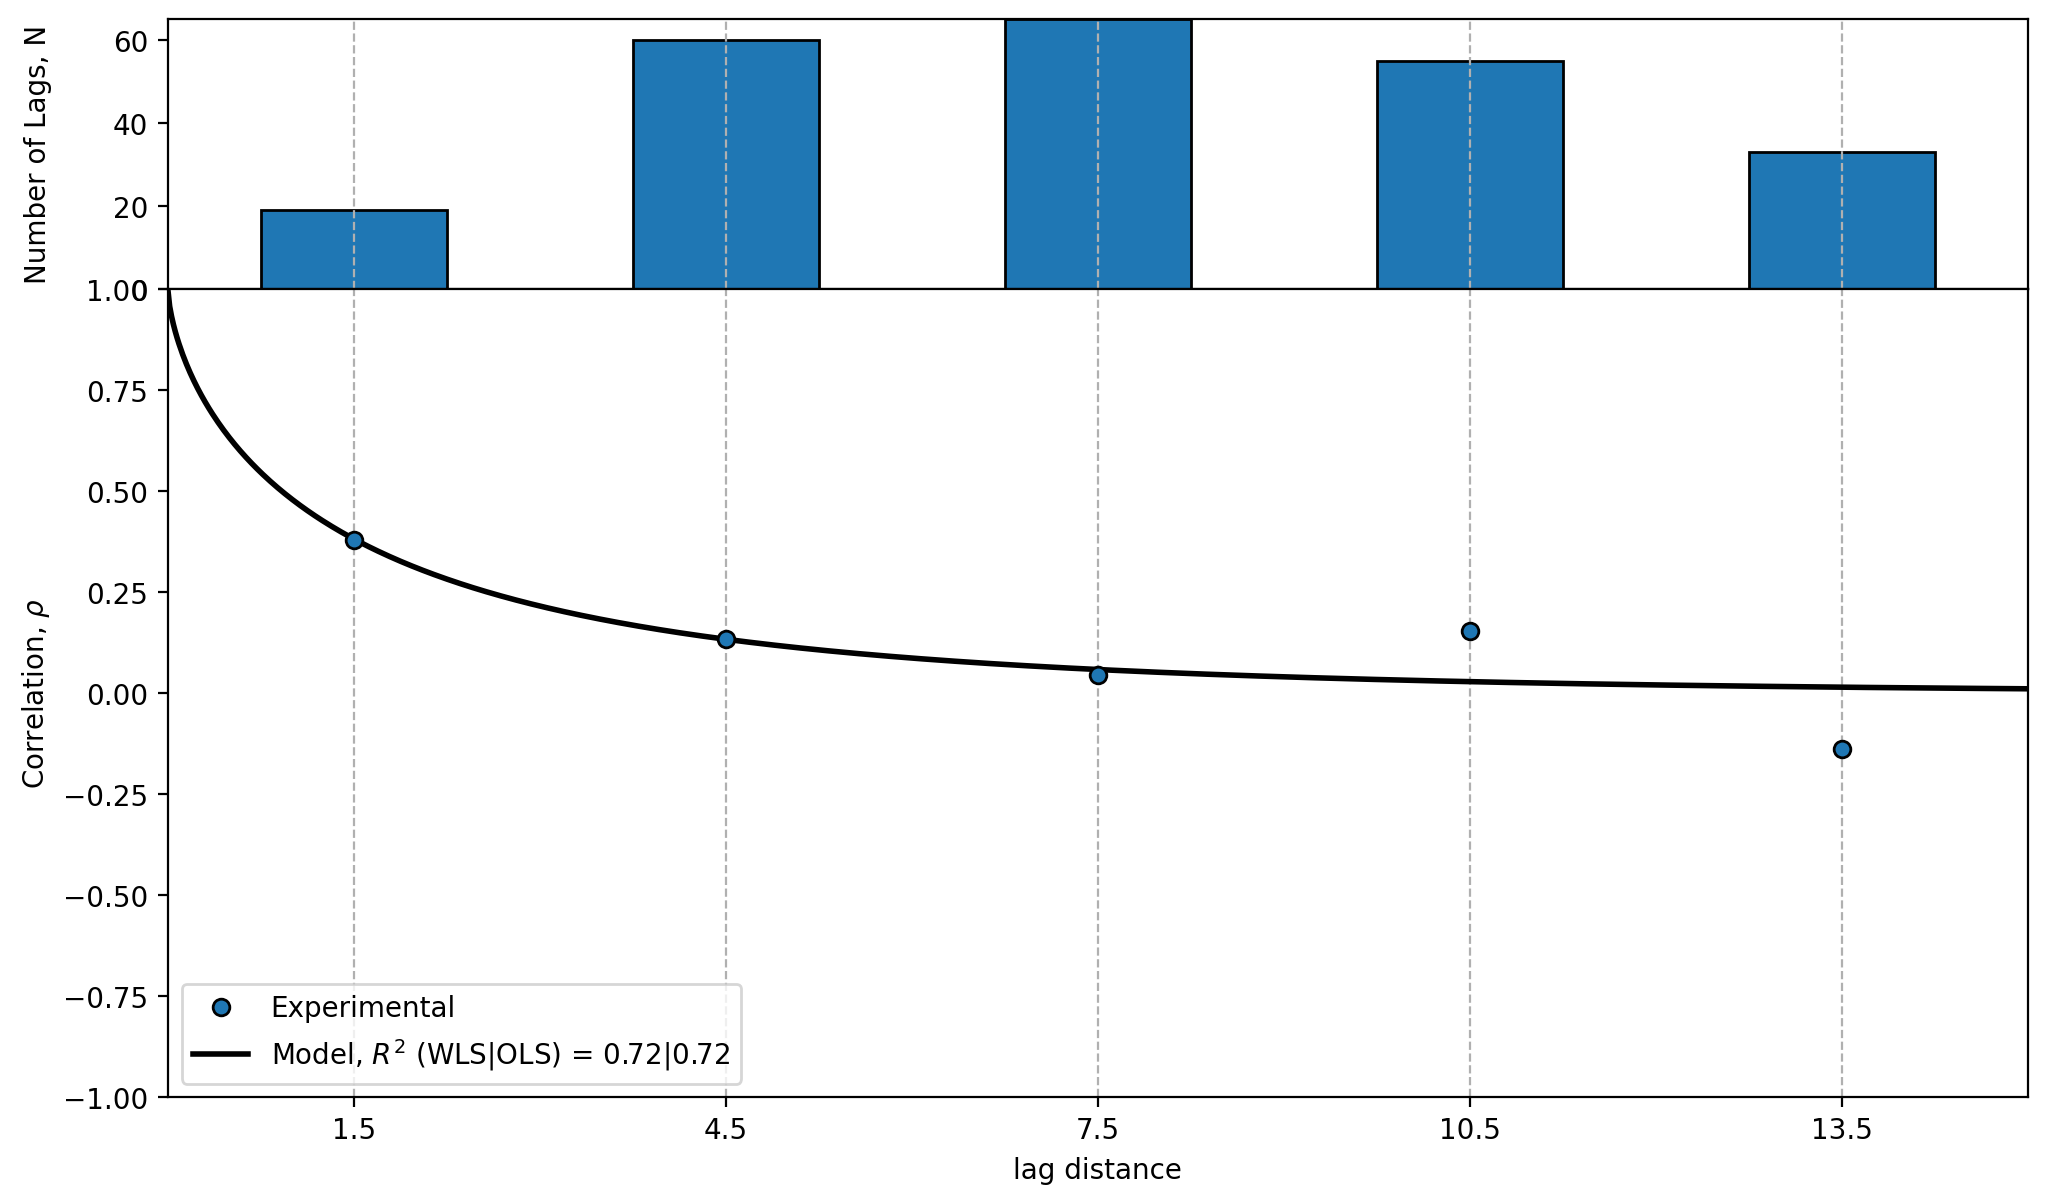

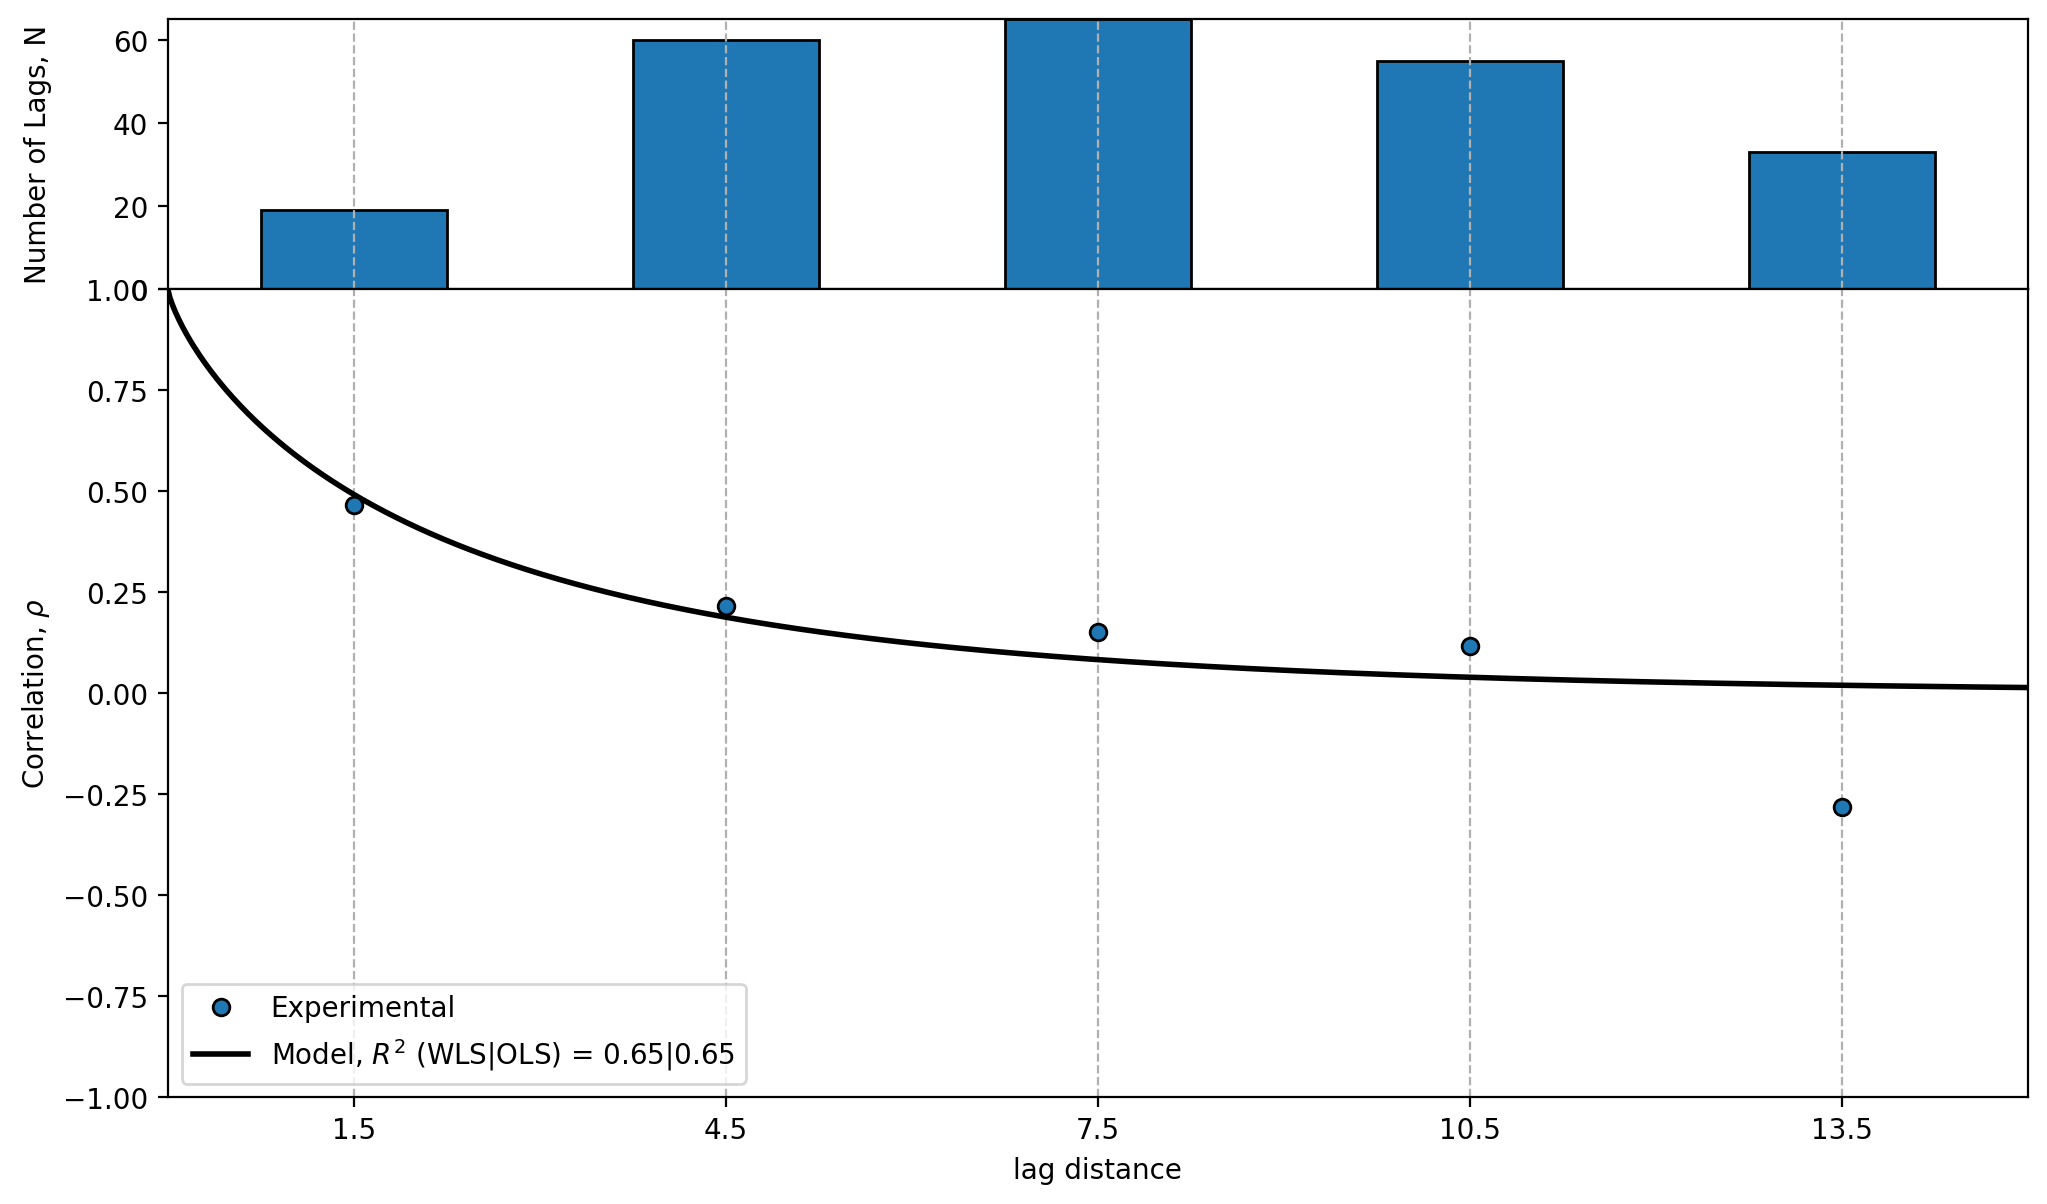

In [306]:
# specify fitting parameters
estimator = "Matheron"
model = "powered_exponential"
weight_fn = None
weight_params = None
xmax_factor = 2

_, _, _, params_tr5_gev, _, _ = variofit(values = TR_5_gev['TR_z'], coordinates = TR_5_gev[['X_km','Y_km']], distance_type = 'cartesian', max_distance = 15, bin_size = 3, estimator_type= estimator, model_type = model, weight_fn = weight_fn, weight_params = weight_params, xmax_factor=xmax_factor, fix_sill = True, plot = True, transform="correlation")

_, _, _, params_tr10_gev, _, _ = variofit(values = TR_10_gev['TR_z'], coordinates = TR_10_gev[['X_km','Y_km']], distance_type = 'cartesian', max_distance = 15, bin_size = 3, estimator_type= estimator, model_type = model, weight_fn = weight_fn, weight_params = weight_params, xmax_factor=xmax_factor, fix_sill = True, plot = True, transform="correlation")

_, _, _, params_tr25_gev, _, _ = variofit(values = TR_25_gev['TR_z'], coordinates = TR_25_gev[['X_km','Y_km']], distance_type = 'cartesian', max_distance = 15, bin_size = 3, estimator_type= estimator, model_type = model, weight_fn = weight_fn, weight_params = weight_params, xmax_factor=xmax_factor, fix_sill = True, plot = True, transform="correlation")

## 4.3 Map of elevation

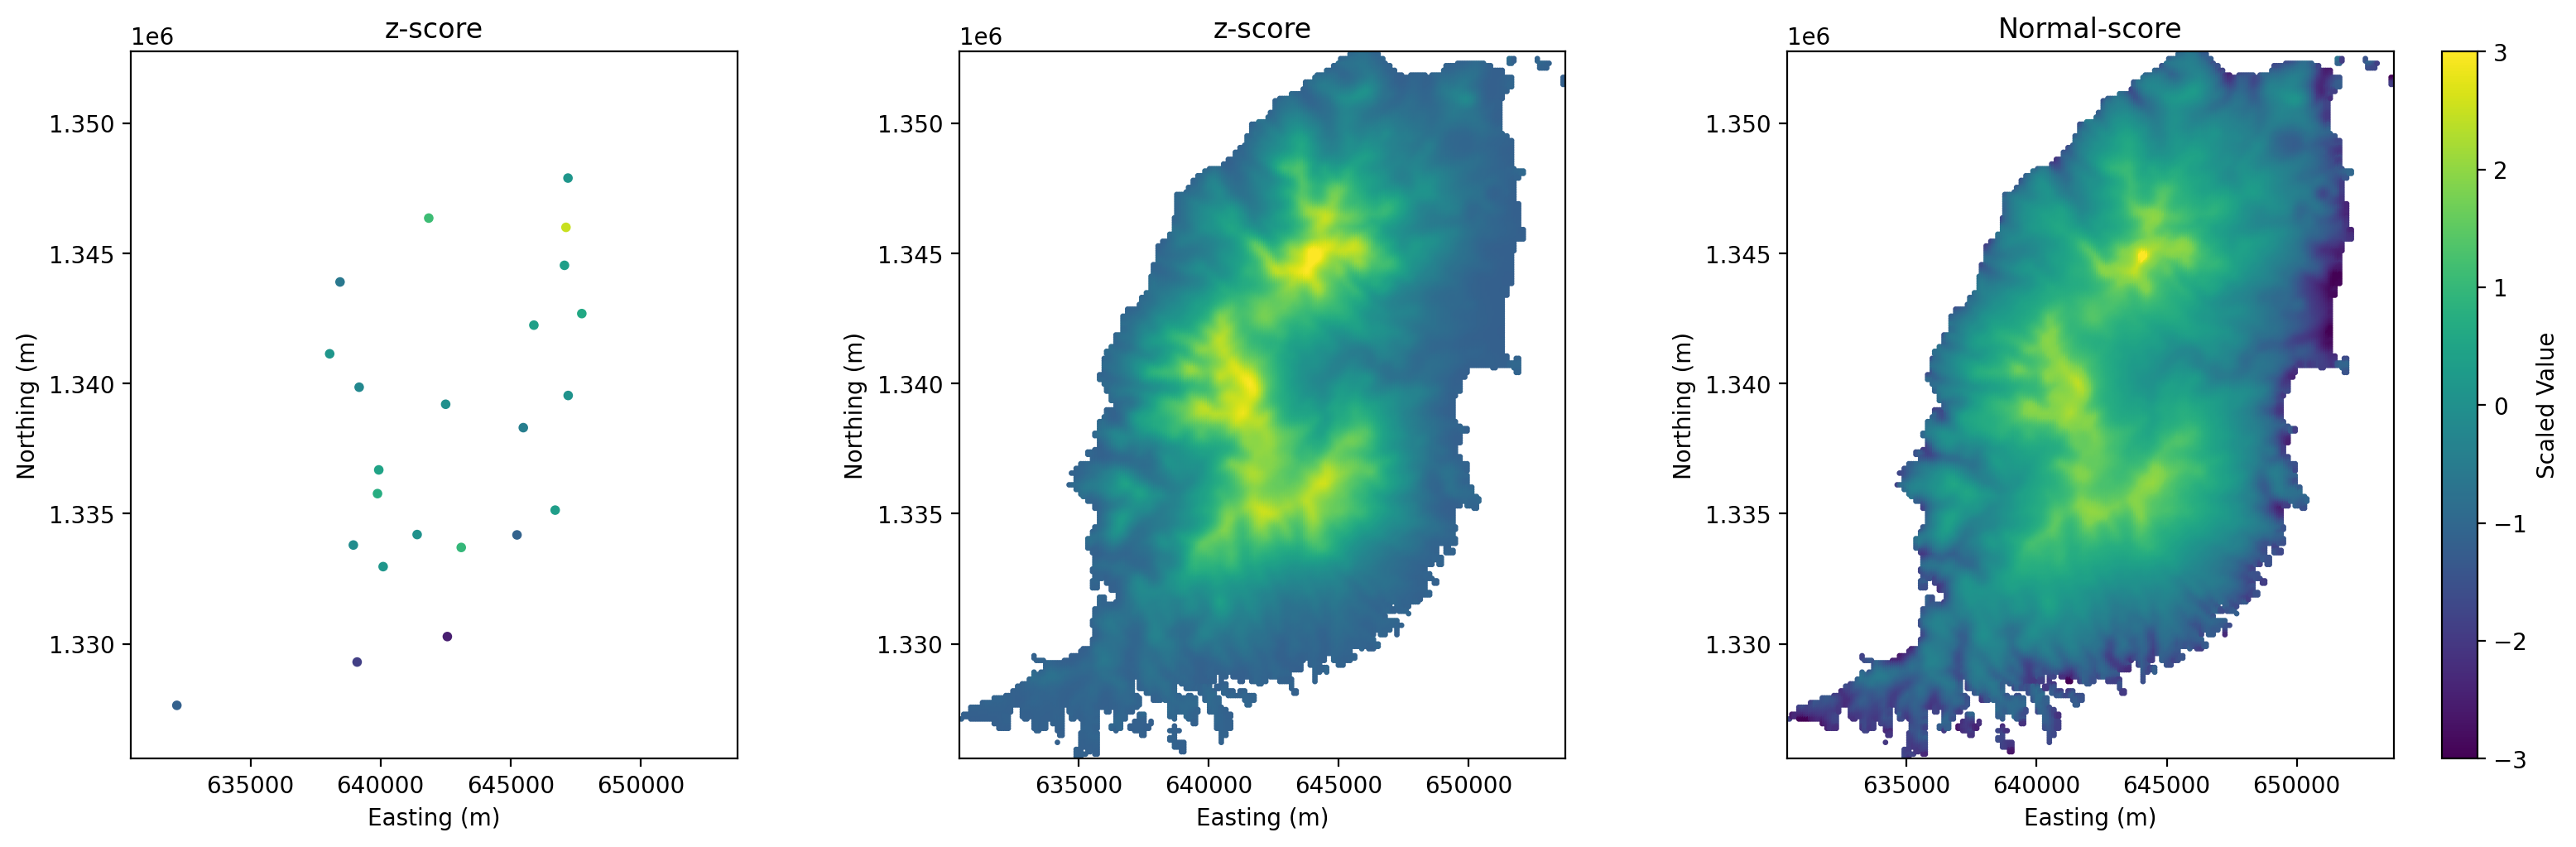

In [307]:
fig, ax = plt.subplots(1, 3, figsize=(16, 5), dpi=200, constrained_layout=True)

im  = ax[0].scatter(TR_25_gev['X_m'],  TR_25_gev['Y_m'],  c=TR_25_gev['TR_z'],        s=10, cmap="viridis", vmin=-3, vmax=3)
im3 = ax[1].scatter(elev['X_m'], elev['Y_m'], c=elev['Elev_z'], s=2, cmap="viridis", vmin=-3, vmax=3)
im4 = ax[2].scatter(elev['X_m'], elev['Y_m'], c=elev['Elev_norm'], s=2, cmap="viridis", vmin=-3, vmax=3)

ax[0].set_title("z-score")
ax[1].set_title("z-score")
ax[2].set_title("Normal-score")

for a in ax:
    a.set_aspect('equal')
    a.set_xlabel("Easting (m)")
    a.set_ylabel("Northing (m)")

cbar = fig.colorbar(im3, ax=ax, orientation='vertical',pad=0.02)
cbar.set_label("Scaled Value")

# Compute global limits across all panels
xmin = min(TR_25_gev['X_m'].min(), elev['X_m'].min())
xmax = max(TR_25_gev['X_m'].max(), elev['X_m'].max())

ymin = min(TR_25_gev['Y_m'].min(), elev['Y_m'].min())
ymax = max(TR_25_gev['Y_m'].max(), elev['Y_m'].max())

# Apply same limits to all axes
for a in ax:
    a.set_xlim(xmin, xmax)
    a.set_ylim(ymin, ymax)

plt.show()

## 4.4 Secondary and cross-variogram

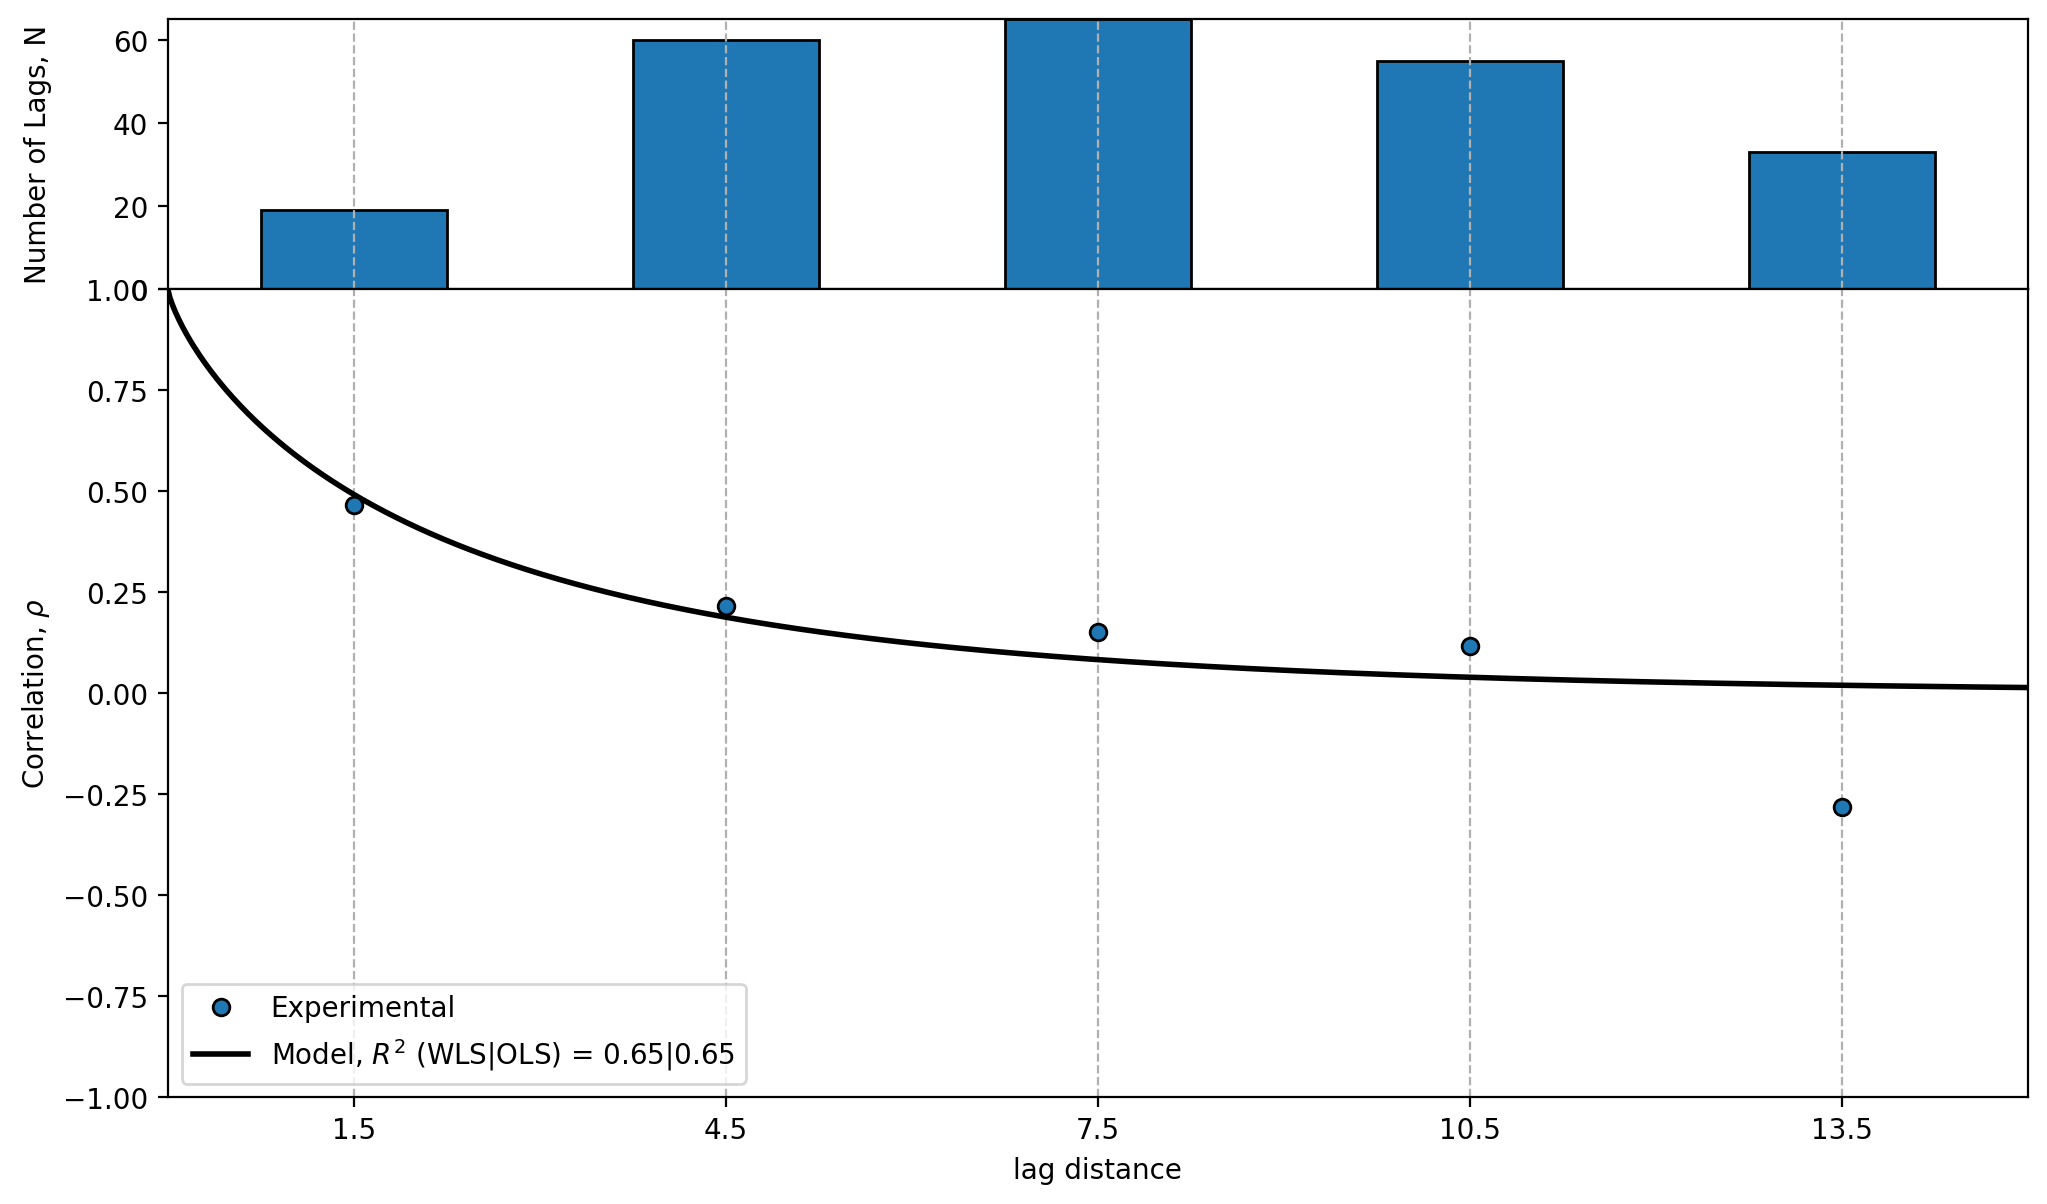

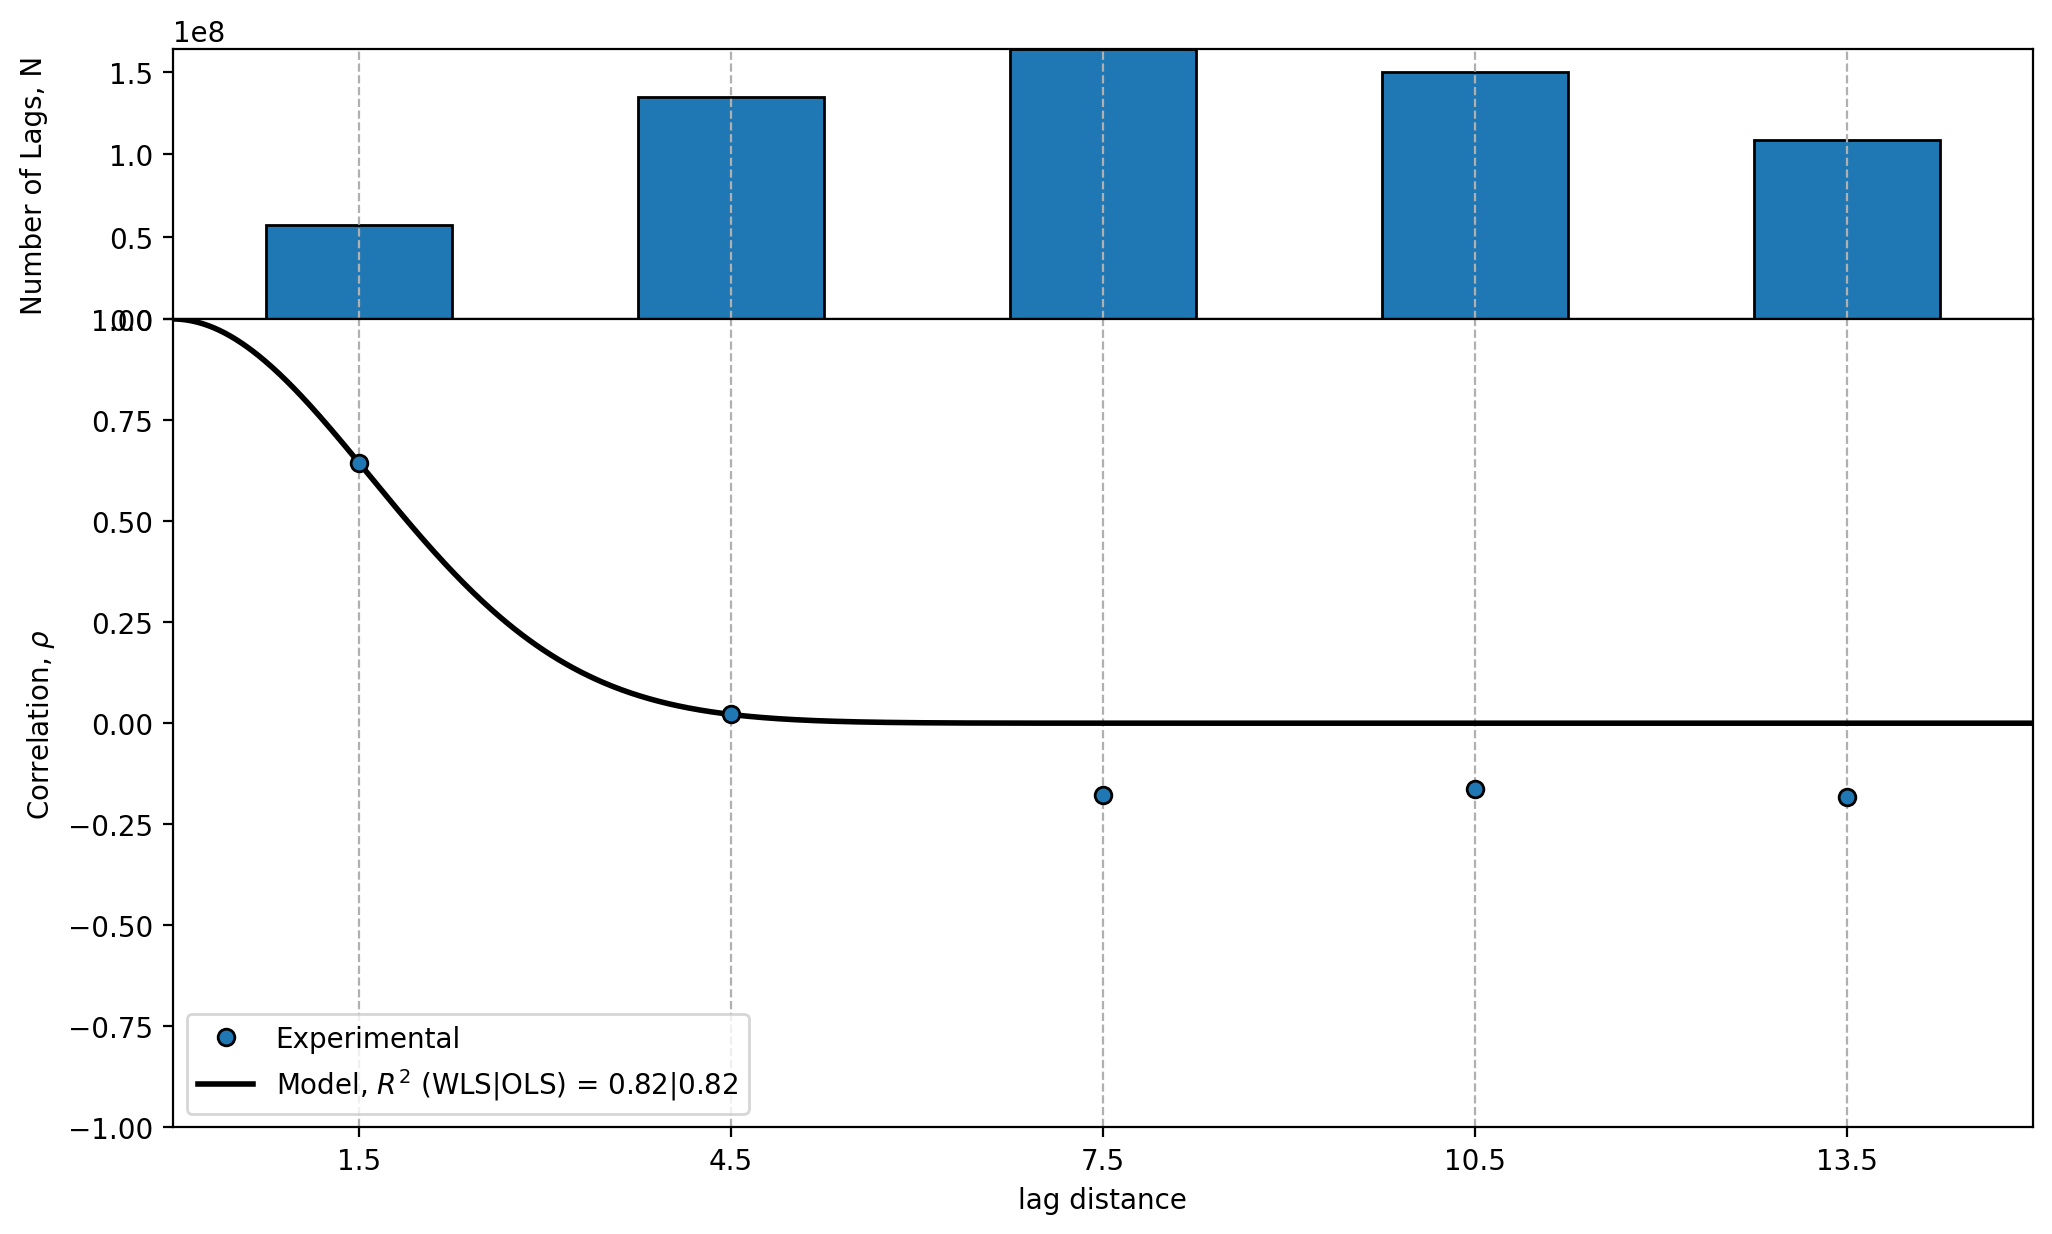

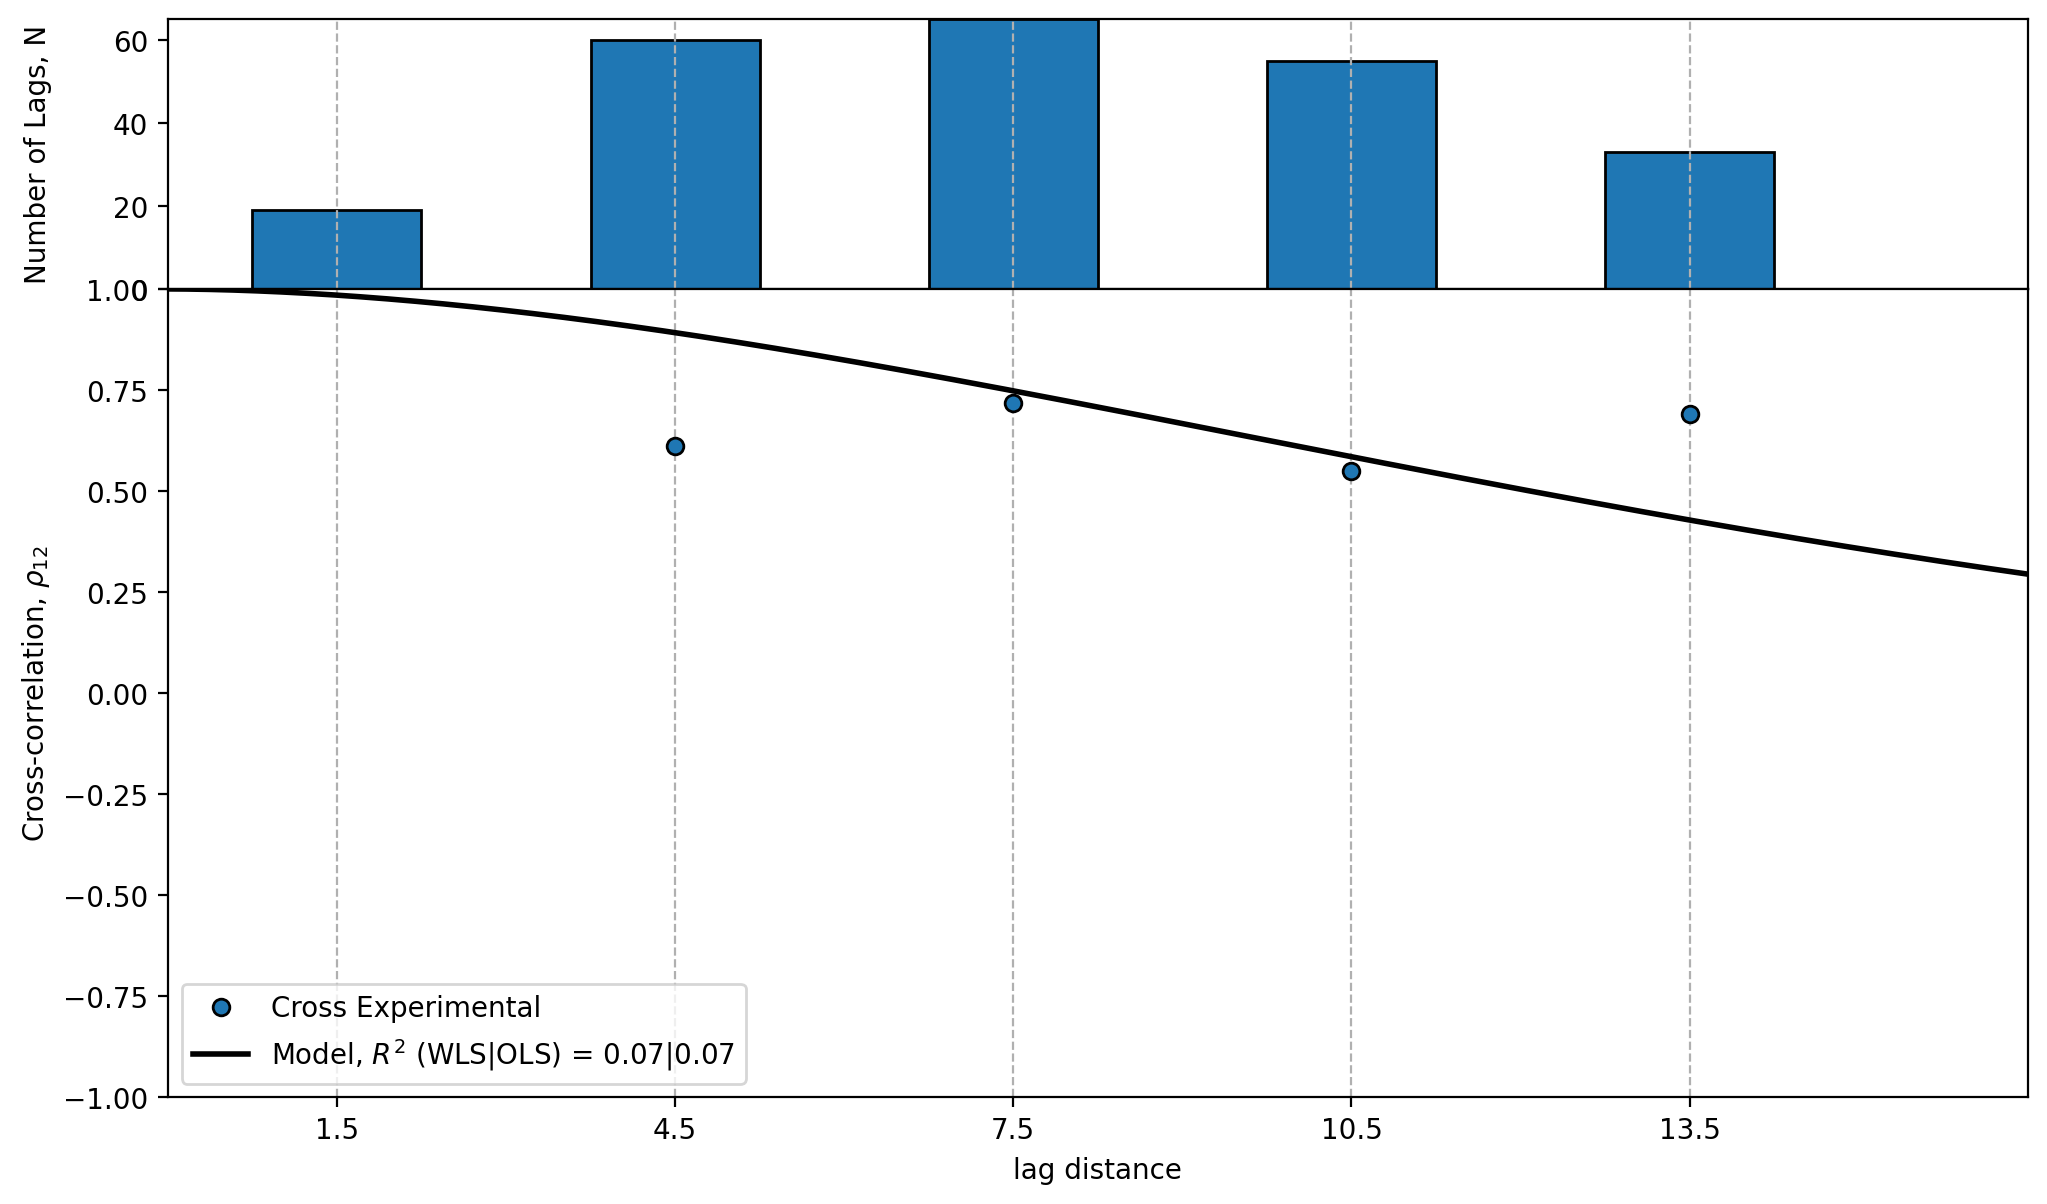

In [308]:
# specify fitting parameters
estimator = "Matheron"
model = "powered_exponential"
weight_fn = None
weight_params = None
xmax_factor = 2

# primary data
h_lag_primary, n_obs_primary, gamma_primary, params_primary, r2_wls_primary, r2_ols_primary = variofit(values = TR_25_gev['TR_z'], coordinates = TR_25_gev[['X_km','Y_km']], distance_type = 'cartesian', max_distance = 15, bin_size = 3, estimator_type= estimator, model_type = model, weight_fn = weight_fn, weight_params = weight_params, xmax_factor=xmax_factor, fix_sill = True, fix_nugget=True, plot = True, transform="correlation")

# secondary data
h_lag_secondary, n_obs_secondary, gamma_secondary, params_secondary, r2_wls_secondary, r2_ols_secondary = variofit(values = elev['Elev_z'], coordinates = elev[['X_km','Y_km']], distance_type = 'cartesian', max_distance = 15, bin_size = 3, estimator_type= estimator, model_type = model, weight_fn = weight_fn, weight_params = weight_params, xmax_factor=xmax_factor, fix_sill = True, fix_nugget = True , plot = True, transform="correlation")

# crossvariogram
h_lag_cross, n_obs_cross, gamma12_cross, params_cross, r2_wls_cross, r2_ols_cross = crossvariofit(values1=TR_25_gev['TR_z'],values2=TR_25_gev['Elev_z'],coordinates=TR_25_gev[['X_km','Y_km']] ,distance_type="cartesian", max_distance=15, bin_size=3, estimator_type=estimator, model_type=model,weight_fn=weight_fn,weight_params=weight_params,fix_nugget=True,fix_sill=True,allow_negative_sill=False, plot=True, transform="correlation"
)

## 4.5 Linear Model of Coregionalization

### 4.5.1 Automatic LMC

Kernel sets:   0%|          | 0/1128 [00:00<?, ?it/s]

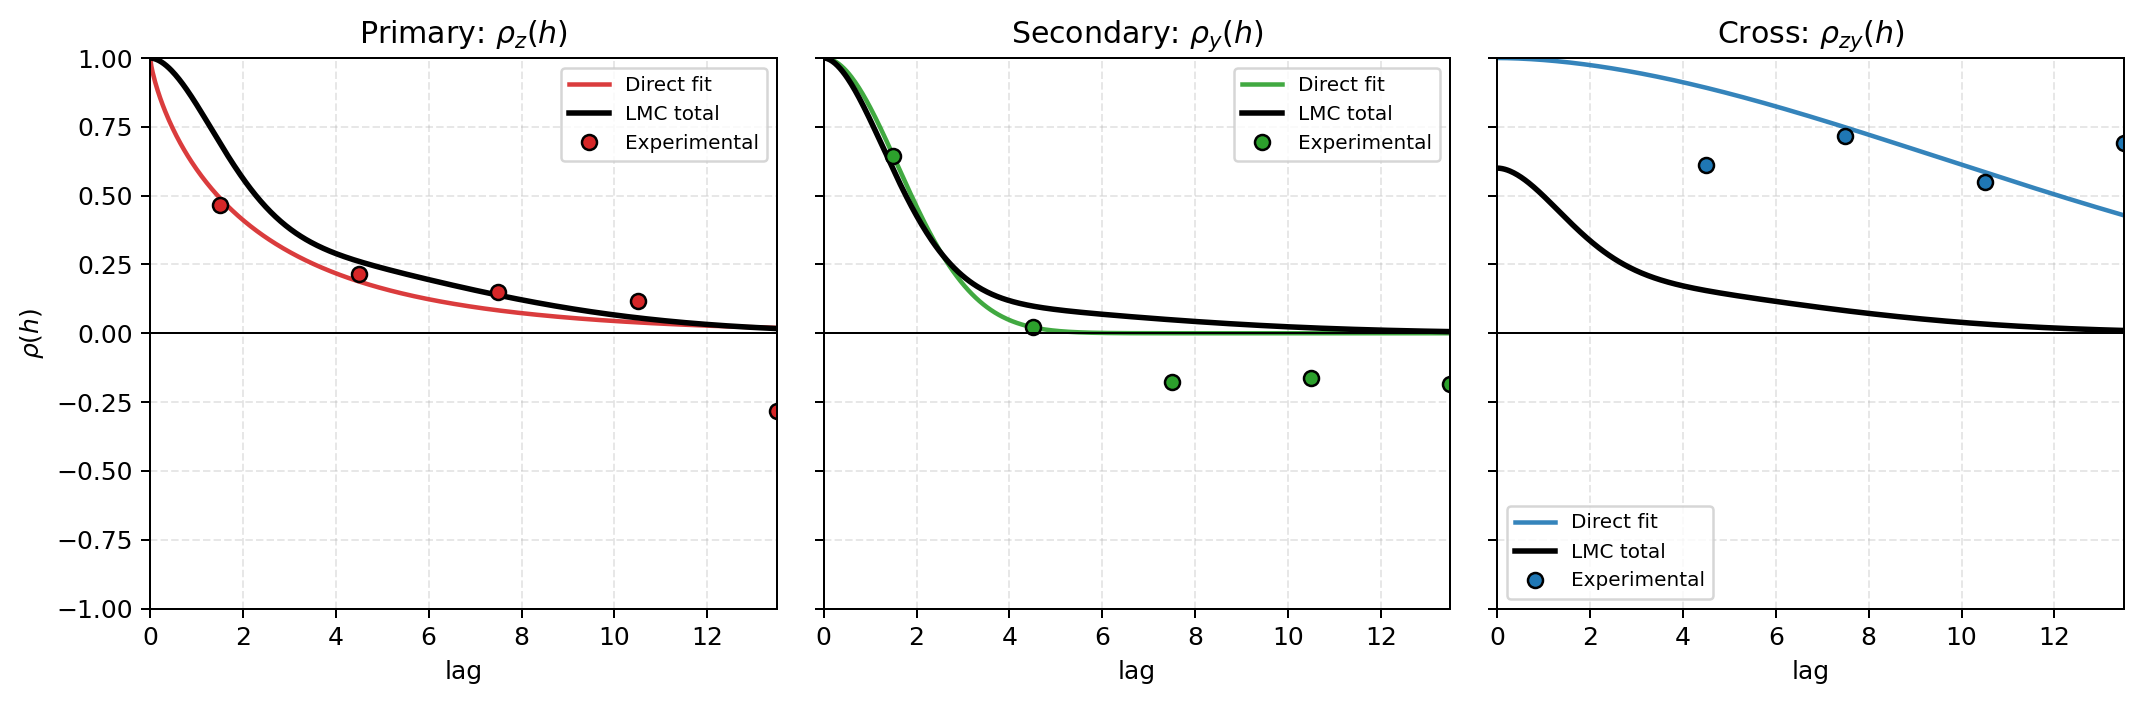

best objective = 0.13123756068505185
best rho0_fit = 0.5999976033351913
best feasible = False
best n_bad_total = 5


In [309]:
h_common, rz_common, ry_common, rzy_common, wz_common, wy_common, wzy_common = align_lmc_experimental_bins(
    h_primary=h_lag_primary,
    rho_primary=gamma_primary,
    n_primary=n_obs_primary,
    h_secondary=h_lag_secondary,
    rho_secondary=gamma_secondary,
    n_secondary=n_obs_secondary,
    h_cross=h_lag_cross,
    rho_cross=gamma12_cross,
    n_cross=n_obs_cross,
)

rho0_target = estimate_collocated_correlation(
    TR_25_gev['TR_z'].to_numpy(),
    TR_25_gev['Elev_z'].to_numpy(),
    method="pearson",
)

search_res = search_lmc_model_space(
    h_common,
    rz_common,
    ry_common,
    rzy_common,
    fixed_structures=None,
    model_family="correlation",
    model_type=model,                 # e.g. "powered_exponential"
    params_primary=params_primary,
    params_secondary=params_secondary,
    params_cross=params_cross,
    n_ranges=9,
    range_spacing="linear",
    range_padding_frac=0.1,
    include_direct_ranges=True,
    include_shape_average=True,
    n_structures=2,
    allow_repeated_kernels=False,
    w_primary=wz_common,
    w_secondary=wy_common,
    w_cross=wzy_common,
    rho0_bounds=[0.2,0.6],
    rho0_target=None,
    cross_misfit_weight_grid=[0.25, 0.5, 1.0, 2.0, 5.0],
    rho0_penalty_weight_grid=[0.0, 1.0, 10.0, 100.0, 1000.0, 1e4],
    normalize_weights=True,
    plot_best=True,
    verbose=False,
)

best = search_res["best"]
best_fit = best["fit"]

print("best objective =", best["objective"])
print("best rho0_fit =", best["rho0_fit"])
print("best feasible =", best["is_feasible"])
print("best n_bad_total =", best["n_bad_total"])

### 4.5.2 Other LMC fits

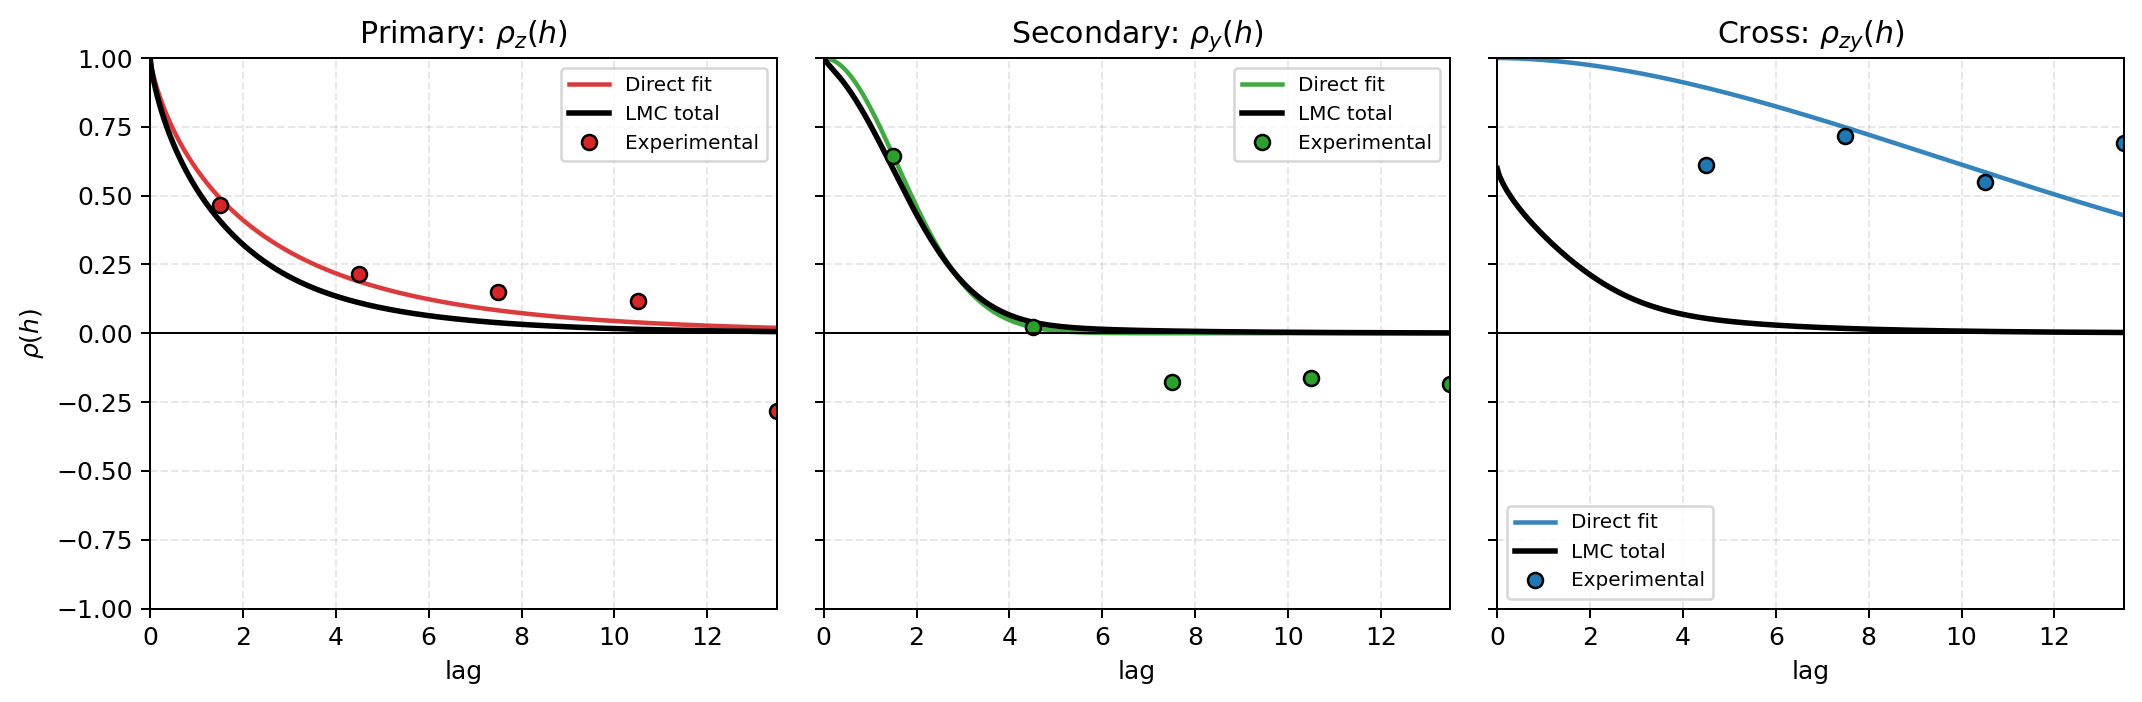

{'h': array([ 0.        ,  0.02705411,  0.05410822,  0.08116232,  0.10821643,
         0.13527054,  0.16232465,  0.18937876,  0.21643287,  0.24348697,
         0.27054108,  0.29759519,  0.3246493 ,  0.35170341,  0.37875752,
         0.40581162,  0.43286573,  0.45991984,  0.48697395,  0.51402806,
         0.54108216,  0.56813627,  0.59519038,  0.62224449,  0.6492986 ,
         0.67635271,  0.70340681,  0.73046092,  0.75751503,  0.78456914,
         0.81162325,  0.83867735,  0.86573146,  0.89278557,  0.91983968,
         0.94689379,  0.9739479 ,  1.001002  ,  1.02805611,  1.05511022,
         1.08216433,  1.10921844,  1.13627255,  1.16332665,  1.19038076,
         1.21743487,  1.24448898,  1.27154309,  1.29859719,  1.3256513 ,
         1.35270541,  1.37975952,  1.40681363,  1.43386774,  1.46092184,
         1.48797595,  1.51503006,  1.54208417,  1.56913828,  1.59619238,
         1.62324649,  1.6503006 ,  1.67735471,  1.70440882,  1.73146293,
         1.75851703,  1.78557114,  1.81262525,

In [310]:
records_by_rho0 = sorted(
    search_res["records"],
    key=lambda r: (
        0 if r["is_feasible"] else 1,
        abs(r["rho0_fit"] - rho0_target),
        r["objective"],
    )
)

rho_tol = 0.02

near_rho_records = [
    r for r in search_res["records"]
    if abs(r["rho0_fit"] - rho0_target) <= rho_tol
]

near_rho_records = sorted(
    near_rho_records,
    key=lambda r: (
        0 if r["is_feasible"] else 1,
        r["objective"],
    )
)

rec = records_by_rho0[0]

plot_lmc_structures(
    h_common,
    rz_common,
    ry_common,
    rzy_common,
    structures=rec["fit"]["structures"],
    direct_models=search_res["direct_models"],
    plot_diagnostic=False,
)

## 4.6 Residual correlograms

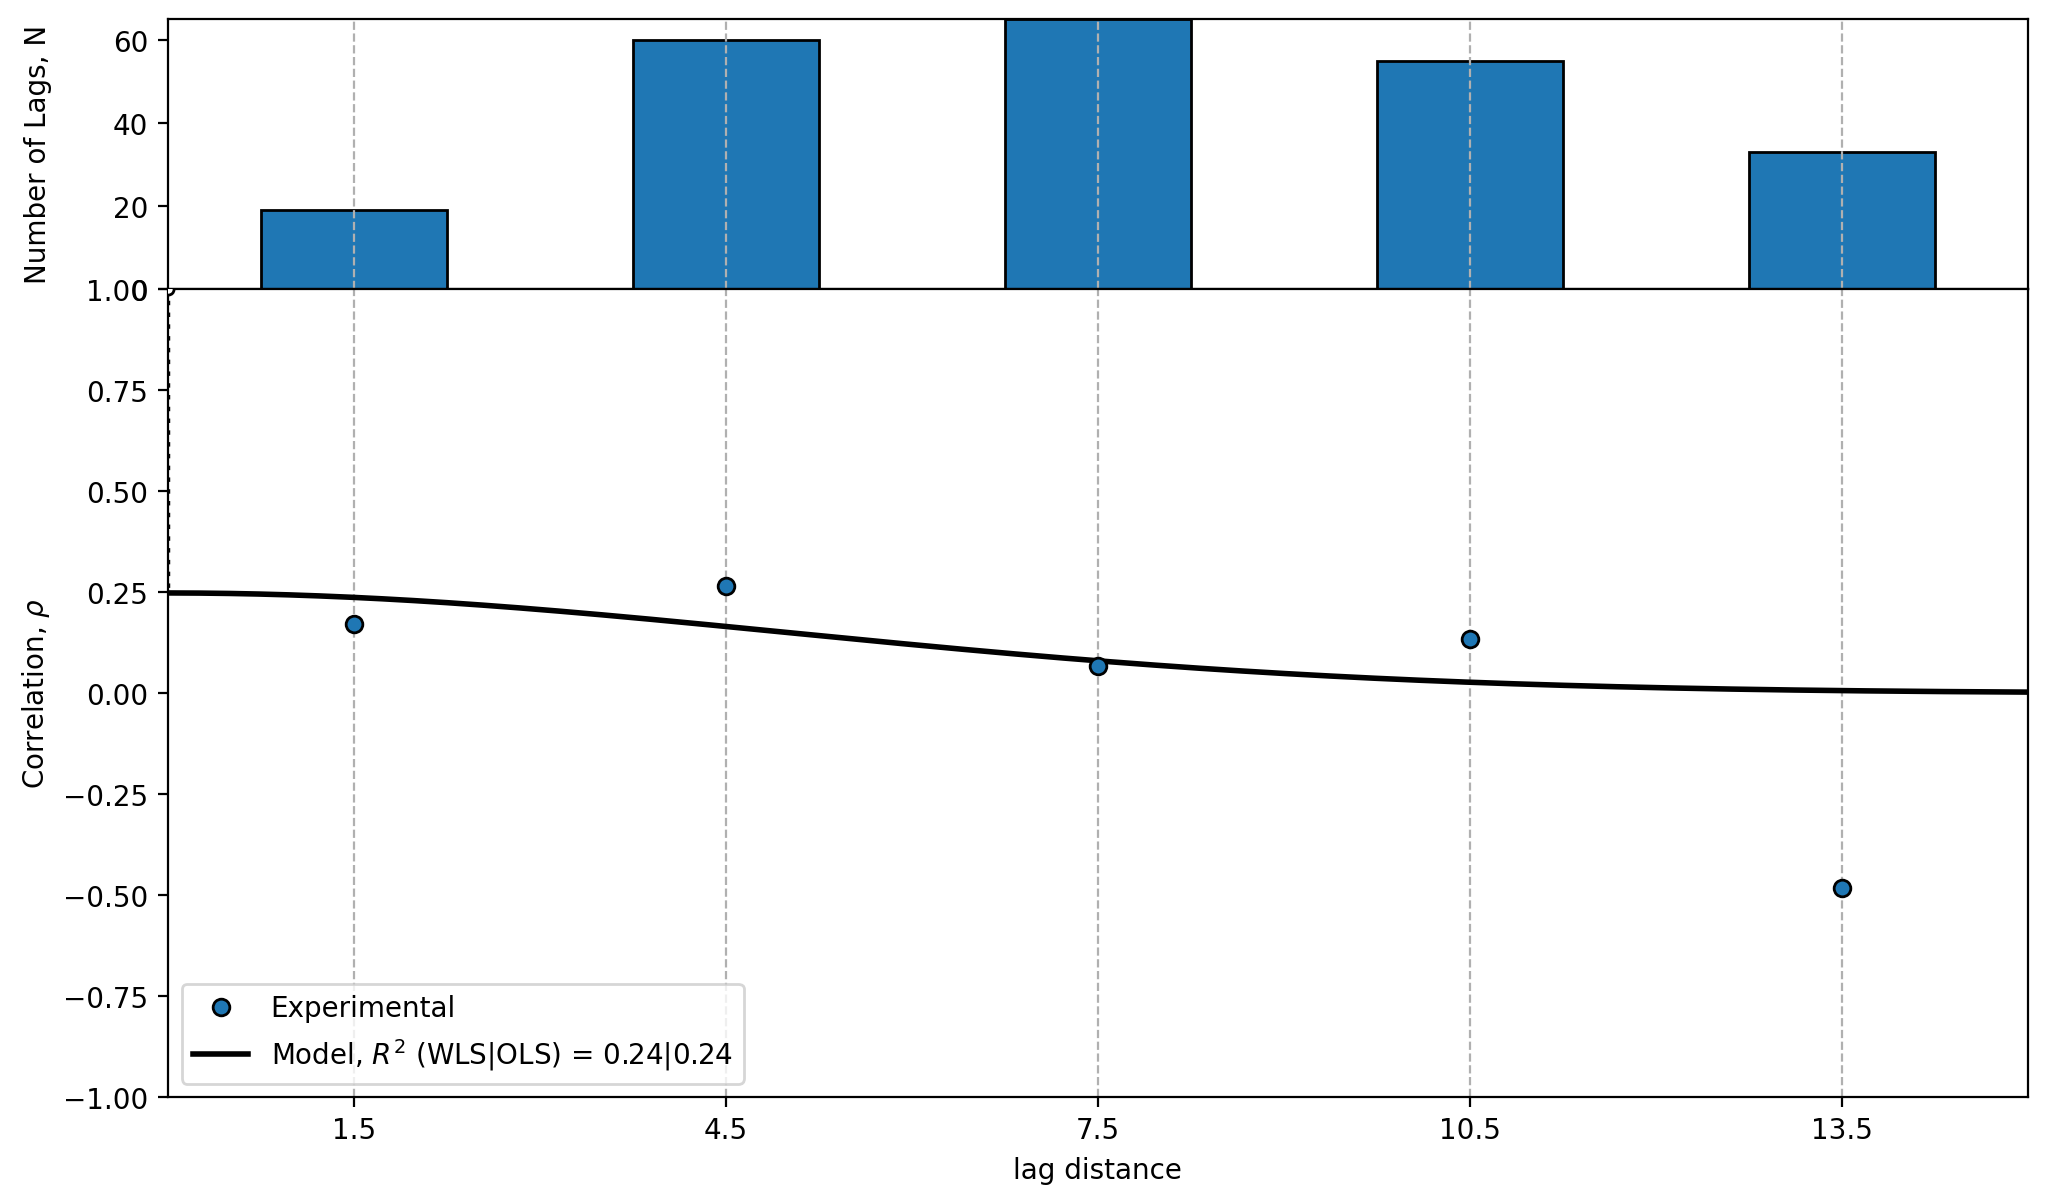

In [311]:
# get correlation between primary and secondary variables
rho0_target = estimate_collocated_correlation(
    TR_25_gev['TR_z'].to_numpy(),
    TR_25_gev['Elev_z'].to_numpy(),
    method="pearson",
)

# rho0_target = 0.35

# Collocated sample pairs at primary locations
z_pair = TR_25_gev['TR_z'].to_numpy(dtype=float)
y_pair = TR_25_gev['Elev_z'].to_numpy(dtype=float)
xy_pair = TR_25_gev[["X_km", "Y_km"]].to_numpy()

# Standardize using one consistent reference
mu_z = z_pair.mean()
sd_z = z_pair.std(ddof=0)
mu_y = y_pair.mean()
sd_y = y_pair.std(ddof=0)

z_std = (z_pair - mu_z) / sd_z
y_std = (y_pair - mu_y) / sd_y

# MM2 residual variable
r_mm2 = (z_std - rho0_target * y_std) / np.sqrt(1.0 - rho0_target**2)

# Fit direct correlogram model for the residual variable
h_lag_resid, n_obs_resid, rho_resid_emp, params_resid, r2_wls_resid, r2_ols_resid = variofit(
    values=r_mm2,
    coordinates=xy_pair,
    distance_type="cartesian",
    max_distance=15,
    bin_size=3,
    estimator_type=estimator,
    model_type=model,
    weight_fn=weight_fn,
    weight_params=weight_params,
    xmax_factor=xmax_factor,
    fix_sill=True,
    fix_nugget=False,
    plot=True,
    transform="correlation",
)

# make models from correlograms
primary_model = make_covmodel_spec(
    model_family="variogram",
    model_type="powered_exponential",
    params=params_primary,
)

secondary_model = make_covmodel_spec(
    model_family="variogram",
    model_type="powered_exponential",
    params=params_secondary,
)

residual_model = make_covmodel_spec(
    model_family="variogram",
    model_type="powered_exponential",
    params=params_resid,
)

# 5.0 Kriging: Ordinary, Ordinary Cokriging and Ordinary Intrinsic Collocated CoKriging

In [312]:
run_loo = False
values = TR_50_gev
mu_values = values['TR_mean'].mean()
sig_values = values['TR_mean'].std(ddof=0)
params_ok = params_tr25_gev
# values = values[~(values.station.isin(["Peggy's Whim (WTP)","Bacolet III", "Blaize (TANK)", "Bon Accord (WTP)", "Radix (WTP)"]))].reset_index(drop=True)
# values = values[~(values.station.isin(["Peggy's Whim (WTP)","Bacolet III",  "Blaize (TANK)", "Clozier (Tank)"]))].reset_index(drop=True)
# values = values[~(values.station.isin(["Radix (WTP)", "Bon Accord (WTP)","Peggy's Whim (WTP)", "Blaize (TANK)", "Grand Etang (LAKE)", "Clozier (Tank)","Mamma Cannes (WTP)", "Pomme Rose (WTP)", "Plaisance (WTP)", "Munich (WTP)"]))].reset_index(drop=True)
# values = values[~(values.station.isin(["Radix (WTP)", "Bon Accord (WTP)","Peggy's Whim (WTP)", "Blaize (TANK)", "Grand Etang (LAKE)", "Clozier (Tank)","Plaisance (WTP)", "Munich (WTP)"]))].reset_index(drop=True)
# values = values[~(values.station.isin(["Radix (WTP)", "Bon Accord (WTP)", "Blaize (TANK)", "Grand Etang (LAKE)", "Clozier (Tank)","Plaisance (WTP)", "Munich (WTP)"]))].reset_index(drop=True)
# values = values[~(values.station.isin(["Bacolet III"]))].reset_index(drop=True)

## 5.1 Ordinary Kriging

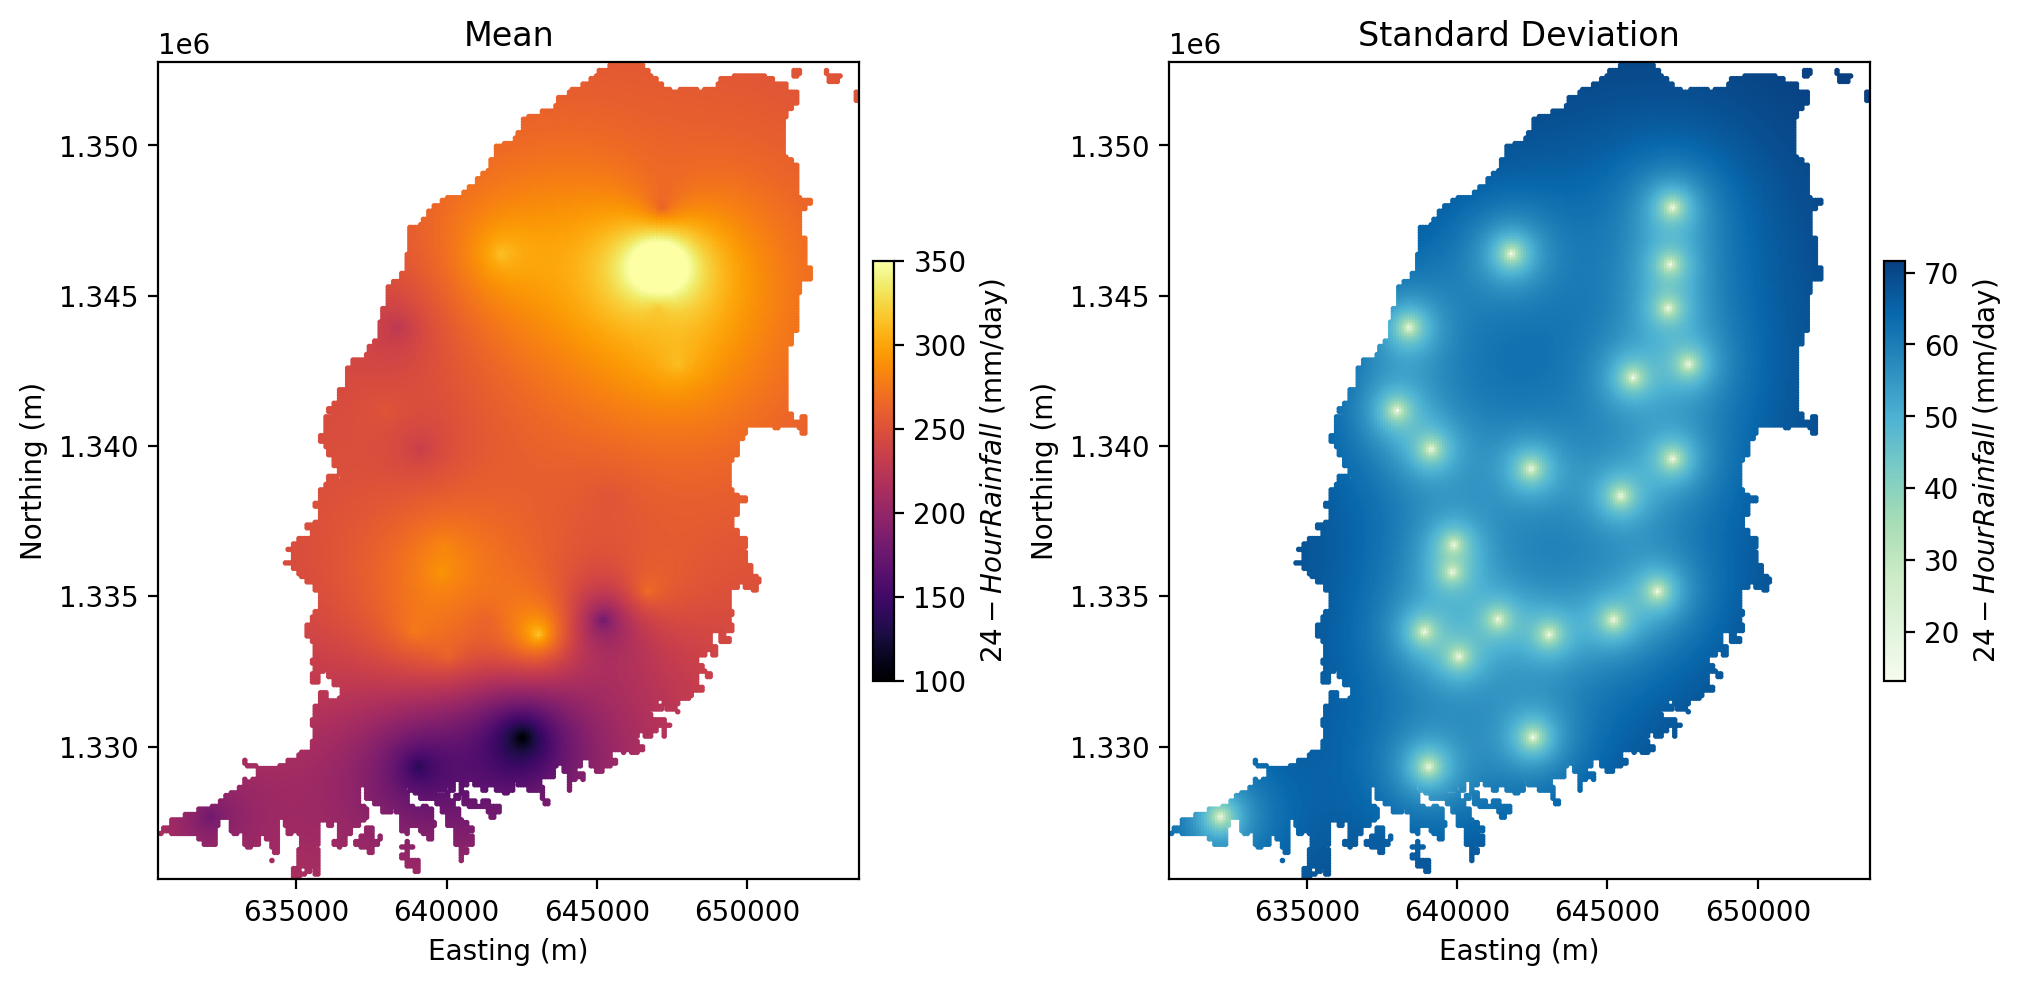

In [313]:
if not run_loo:
    est, var = ordinary_kriging(
            values=values['TR_z'],
            coords=values[['X_km','Y_km']],
            targets=elev[['X_km','Y_km']],
            model_family="variogram",
            model_type=model,
            params=params_ok,
            distance_type="cartesian",
            jitter=1e-10,
            return_weights=False
            )

    fig, ax = plt.subplots(1, 2, figsize=(10, 6), dpi=200, constrained_layout=True)

    # plots
    im1 = ax[0].scatter(
        elev["X_m"], elev["Y_m"],
        s=1, c=est * sig_values + mu_values,
        cmap="inferno", vmin=100, vmax=350
    )

    im2 = ax[1].scatter(
        elev["X_m"], elev["Y_m"],
        s=1, c=np.sqrt(var) * sig_values,
        cmap="GnBu"
    )

    # titles
    ax[0].set_title("Mean")
    ax[1].set_title("Standard Deviation")

    # shared axis limits
    xmin = elev["X_m"].min()
    xmax = elev["X_m"].max()
    ymin = elev["Y_m"].min()
    ymax = elev["Y_m"].max()

    for a in ax:
        a.set_aspect("equal")
        a.set_xlim(xmin, xmax)
        a.set_ylim(ymin, ymax)
        a.set_xlabel("Easting (m)")
        a.set_ylabel("Northing (m)")

    cbar1 = fig.colorbar(im1, ax=ax[0], orientation="vertical",
                         fraction=0.03, pad=0.02)
    cbar1.set_label(r"$24-Hour Rainfall$ (mm/day)")
    cbar2 = fig.colorbar(im2, ax=ax[1], orientation="vertical",
                         fraction=0.03, pad=0.02)
    cbar2.set_label(r"$24-Hour Rainfall$ (mm/day)")
    plt.show()

else:
    mu_list = []
    std_error_list = []
    dmin_list = []

    for sta in tqdm(values.station.tolist(),desc="LOO",total=len(values)):

        sta_i = values[values.station == sta].reset_index(drop=True)
        sta_j = values[values.station != sta].reset_index(drop=True)

        # nearest neighbour distance (km)
        dx = sta_i.X_km.values - sta_j.X_km.values
        dy = sta_i.Y_km.values - sta_j.Y_km.values
        dmin = np.min(np.sqrt(dx*dx + dy*dy))
        dmin_list.append(dmin)

        est, var = ordinary_kriging(
            values=sta_j['TR_z'],
            coords=sta_j[['X_km','Y_km']],
            targets=sta_i[['X_km','Y_km']],
            model_family="variogram",
            model_type=model,
            params=params_ok,
            distance_type="cartesian",
            jitter=1e-10,
            return_weights=False
        )

        # store values
        est_val   = est.item()
        var_val   = var.item()

        # store values
        mu_list.append(est_val * sig_values + mu_values)
        std_error_list.append(np.sqrt(var_val) * sig_values)

    # append to dataframe
    values['dmin'] = dmin_list
    values['ok_TR_mu'] = mu_list
    values['ok_TR_std'] = std_error_list

## 5.2 Ordinary Intrinsic Co-located Cokriging

### 5.2.1 MM1

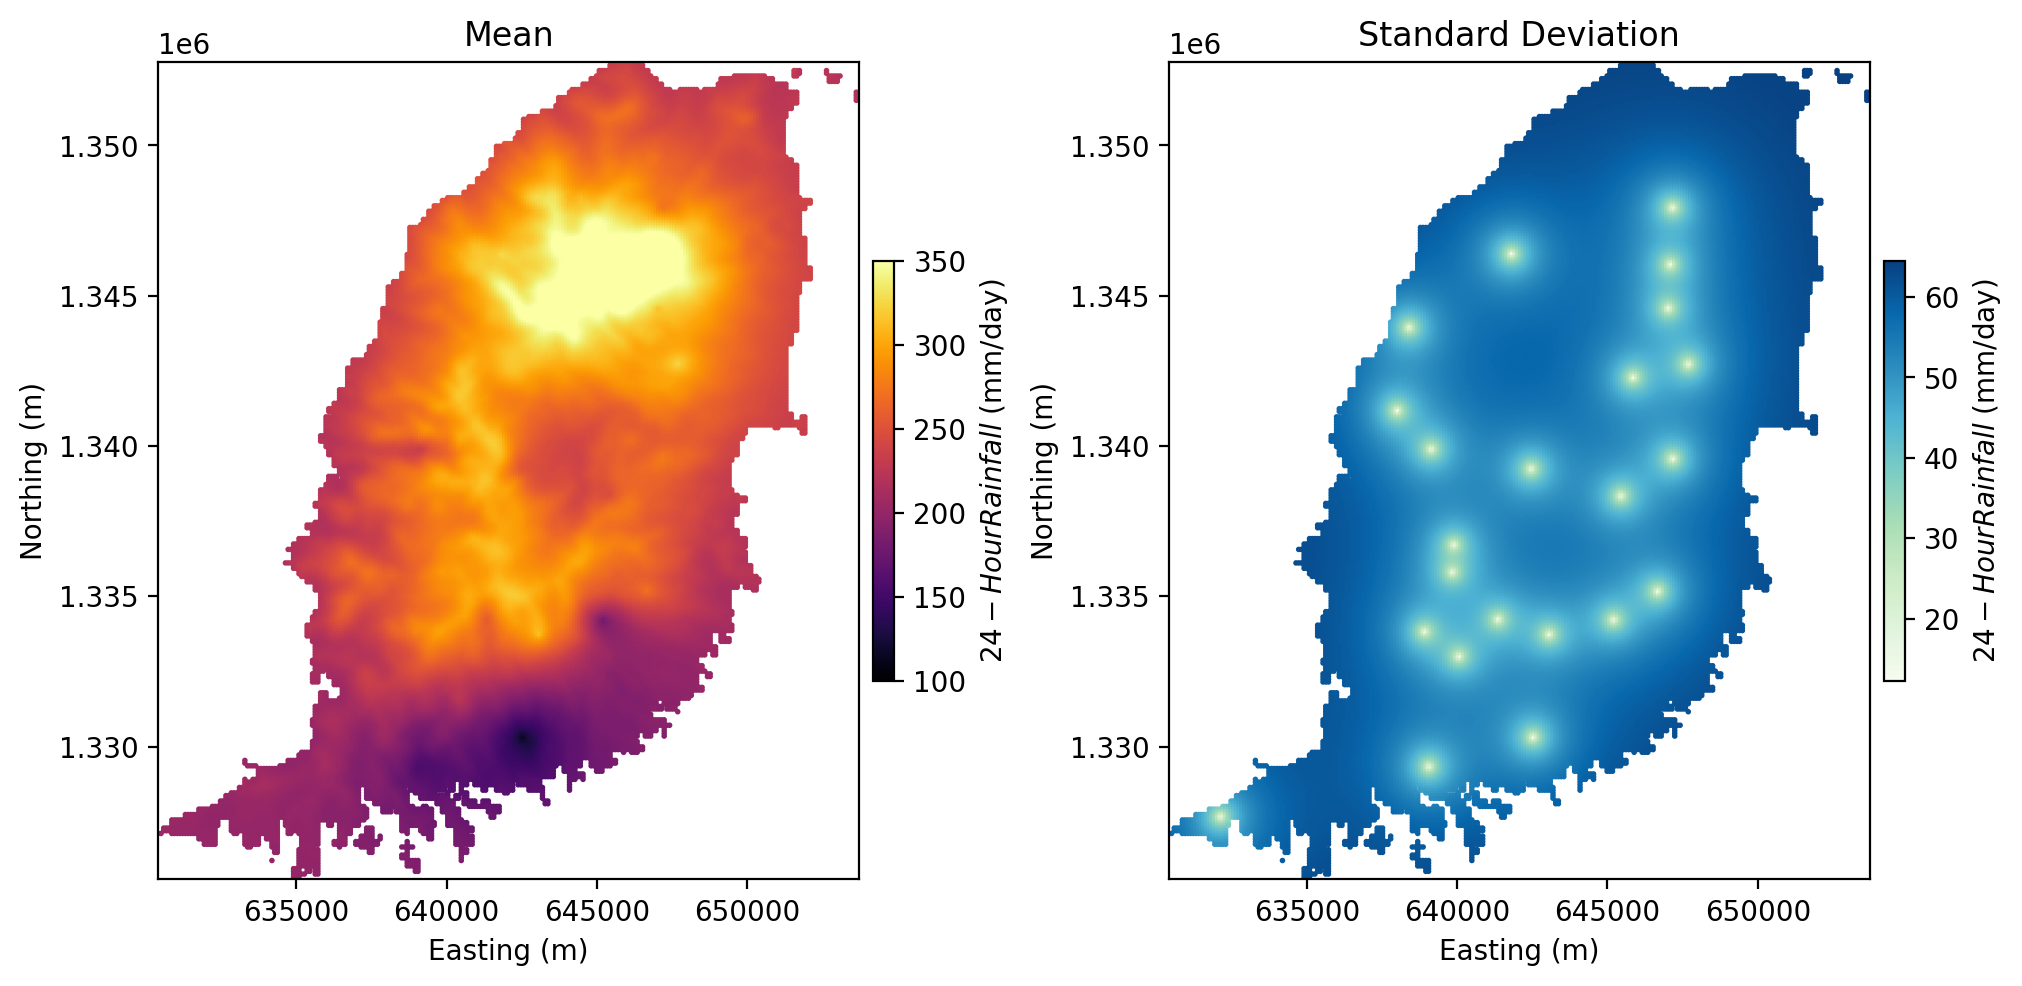

In [314]:
# ICCK MM1
if not run_loo:
    est_mm1, var_mm1 = OICCK_MM1(
        primary_values=values['TR_z'].to_numpy(),
        primary_coords=values[["X_km", "Y_km"]].to_numpy(),
        secondary_values=values["Elev_z"].to_numpy(),
        secondary_coords=values[["X_km", "Y_km"]].to_numpy(),
        collocated_secondary_values=elev["Elev_z"].to_numpy(),
        targets=elev[["X_km", "Y_km"]].to_numpy(),
        rho0=rho0_target,
        primary_model=primary_model,
        secondary_values_for_standardization=values["Elev_z"].to_numpy(),
        distance_type="cartesian",
        rotation_matrix=None,
        standardize=True,
        jitter=1e-10,
        check_positive_definite=True,
        return_weights=False,
        show_progress=True
    )

    fig, ax = plt.subplots(1, 2, figsize=(10, 6), dpi=200, constrained_layout=True)
    im1 = ax[0].scatter(
        elev["X_m"], elev["Y_m"],
        s=1, c=est_mm1 * sig_values + mu_values,
        cmap="inferno", vmin=100, vmax=350
    )

    im2 = ax[1].scatter(
        elev["X_m"], elev["Y_m"],
        s=1, c=np.sqrt(var_mm1) * sig_values,
        cmap="GnBu"
    )
    ax[0].set_title("Mean")
    ax[1].set_title("Standard Deviation")
    xmin = elev["X_m"].min()
    xmax = elev["X_m"].max()
    ymin = elev["Y_m"].min()
    ymax = elev["Y_m"].max()

    for a in ax:
        a.set_aspect("equal")
        a.set_xlim(xmin, xmax)
        a.set_ylim(ymin, ymax)
        a.set_xlabel("Easting (m)")
        a.set_ylabel("Northing (m)")

    cbar1 = fig.colorbar(im1, ax=ax[0], orientation="vertical",
                         fraction=0.03, pad=0.02)
    cbar1.set_label(r"$24-Hour Rainfall$ (mm/day)")
    cbar2 = fig.colorbar(im2, ax=ax[1], orientation="vertical",
                         fraction=0.03, pad=0.02)
    cbar2.set_label(r"$24-Hour Rainfall$ (mm/day)")
    plt.show()

else:
    mu_list = []
    std_error_list = []
    dmin_list = []

    for sta in tqdm(values.station.tolist(), desc="LOO", total=len(values)):

        # Split into left-out station and training set
        sta_i = values[values.station == sta].reset_index(drop=True)
        sta_j = values[values.station != sta].reset_index(drop=True)

        # nearest neighbour distance (km)
        dx = sta_i.X_km.values - sta_j.X_km.values
        dy = sta_i.Y_km.values - sta_j.Y_km.values
        dmin = np.min(np.sqrt(dx*dx + dy*dy))
        dmin_list.append(dmin)

        # ICCK-MM1 prediction at the left-out station
        est_mm1, var_mm1 = OICCK_MM1(
            primary_values=sta_j['TR_z'].to_numpy(),
            primary_coords=sta_j[["X_km", "Y_km"]].to_numpy(),
            secondary_values=sta_j["Elev_z"].to_numpy(),
            secondary_coords=sta_j[["X_km", "Y_km"]].to_numpy(),
            collocated_secondary_values=sta_i["Elev_z"].to_numpy(),
            targets=sta_i[["X_km", "Y_km"]].to_numpy(),
            rho0=rho0_target,
            primary_model=primary_model,
            secondary_values_for_standardization=sta_j["Elev_z"].to_numpy(),
            distance_type="cartesian",
            rotation_matrix=None,
            standardize=True,
            jitter=1e-10,
            check_positive_definite=True,
            return_weights=False,
            show_progress=False
        )

        # est_mm1 and var_mm1 are length-1 arrays
        est_val = est_mm1[0]
        var_val = var_mm1[0]

        # back-transform
        mu_list.append(est_val * sig_values + mu_values)
        std_error_list.append(np.sqrt(var_val) * sig_values)

    # append to dataframe
    values['dmin'] = dmin_list
    values['oicckm1_TR_mu'] = mu_list
    values['oicckm1_TR_std'] = std_error_list

### 5.2.2 MM2

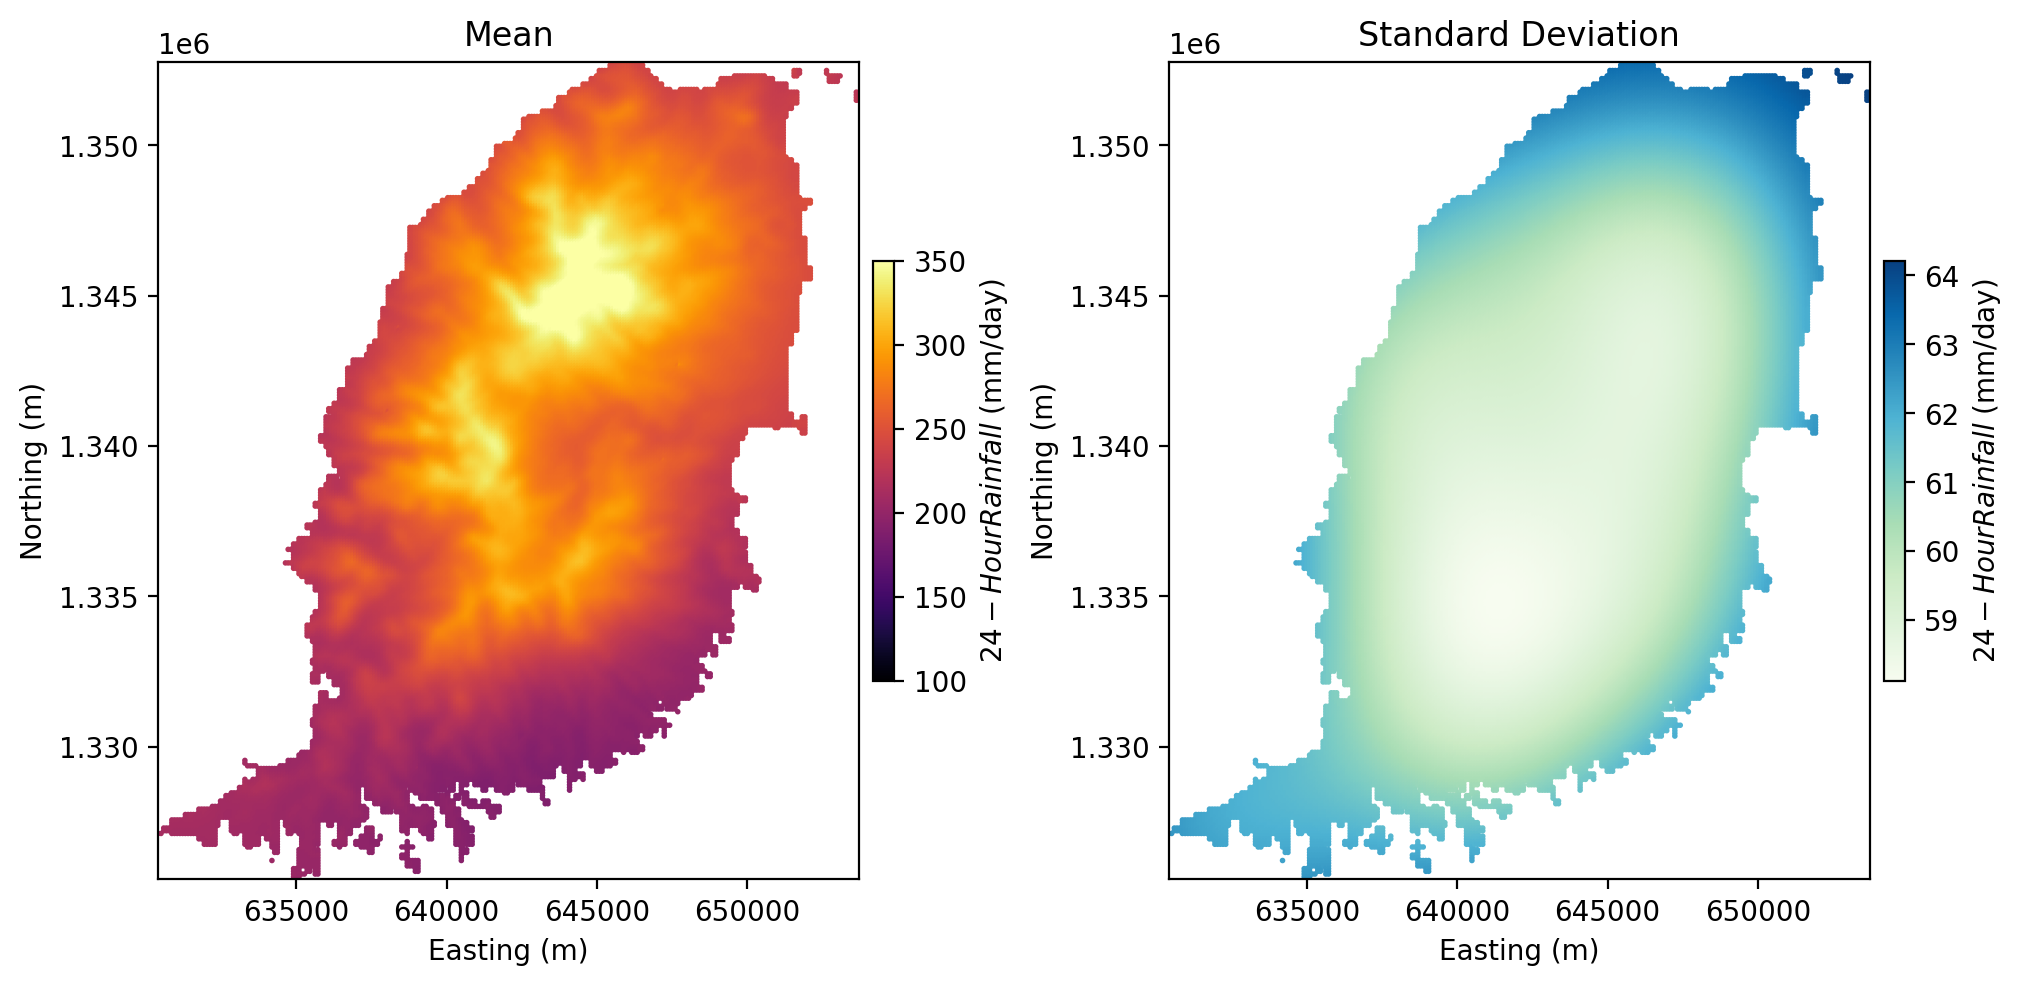

In [315]:
# ICCK MM2
if not run_loo:
    est_mm2, var_mm2 = OICCK_MM2(
        primary_values=values['TR_z'].to_numpy(),
        primary_coords=values[["X_km", "Y_km"]].to_numpy(),
        secondary_values=values["Elev_z"].to_numpy(),
        secondary_coords=values[["X_km", "Y_km"]].to_numpy(),
        collocated_secondary_values=elev["Elev_z"].to_numpy(),
        targets=elev[["X_km", "Y_km"]].to_numpy(),
        rho0=rho0_target,
        secondary_model=secondary_model,
        residual_model=residual_model,
        secondary_values_for_standardization=values["Elev_z"].to_numpy(),
        distance_type="cartesian",
        rotation_matrix=None,
        standardize=True,
        jitter=1e-10,
        check_positive_definite=True,
        return_weights=False,
        show_progress=True
    )

    fig, ax = plt.subplots(1, 2, figsize=(10, 6), dpi=200, constrained_layout=True)
    im1 = ax[0].scatter(
        elev["X_m"], elev["Y_m"],
        s=1, c=est_mm2 * sig_values + mu_values,
        cmap="inferno", vmin=100, vmax=350
    )
    im2 = ax[1].scatter(
        elev["X_m"], elev["Y_m"],
        s=1, c=np.sqrt(var_mm2) * sig_values,
        cmap="GnBu"
    )
    ax[0].set_title("Mean")
    ax[1].set_title("Standard Deviation")
    xmin = elev["X_m"].min()
    xmax = elev["X_m"].max()
    ymin = elev["Y_m"].min()
    ymax = elev["Y_m"].max()
    for a in ax:
        a.set_aspect("equal")
        a.set_xlim(xmin, xmax)
        a.set_ylim(ymin, ymax)
        a.set_xlabel("Easting (m)")
        a.set_ylabel("Northing (m)")
    cbar1 = fig.colorbar(im1, ax=ax[0], orientation="vertical",fraction=0.03, pad=0.02)
    cbar1.set_label(r"$24-Hour Rainfall$ (mm/day)")
    cbar2 = fig.colorbar(im2, ax=ax[1], orientation="vertical",fraction=0.03, pad=0.02)
    cbar2.set_label(r"$24-Hour Rainfall$ (mm/day)")
    plt.show()

else:
    mu_list = []
    std_error_list = []
    dmin_list = []

    for sta in tqdm(values.station.tolist(), desc="LOO", total=len(values)):

        # Split into left-out station and training set
        sta_i = values[values.station == sta].reset_index(drop=True)
        sta_j = values[values.station != sta].reset_index(drop=True)

        # nearest neighbour distance (km)
        dx = sta_i.X_km.values - sta_j.X_km.values
        dy = sta_i.Y_km.values - sta_j.Y_km.values
        dmin = np.min(np.sqrt(dx*dx + dy*dy))
        dmin_list.append(dmin)

        # ICCK-MM2 prediction at the left-out station
        est_mm2, var_mm2 = OICCK_MM2(
            primary_values=sta_j['TR_z'].to_numpy(),
            primary_coords=sta_j[["X_km", "Y_km"]].to_numpy(),
            secondary_values=sta_j["Elev_z"].to_numpy(),
            secondary_coords=sta_j[["X_km", "Y_km"]].to_numpy(),
            collocated_secondary_values=sta_i["Elev_z"].to_numpy(),
            targets=sta_i[["X_km", "Y_km"]].to_numpy(),
            rho0=rho0_target,
            secondary_model=secondary_model,
            residual_model=residual_model,
            secondary_values_for_standardization=sta_j["Elev_z"].to_numpy(),
            distance_type="cartesian",
            rotation_matrix=None,
            standardize=True,
            jitter=1e-10,
            check_positive_definite=True,
            return_weights=False,
            show_progress=False
        )

        # est_mm2 and var_mm2 are length-1 arrays
        est_val = est_mm2[0]
        var_val = var_mm2[0]

        # back-transform
        mu_list.append(est_val * sig_values + mu_values)
        std_error_list.append(np.sqrt(var_val) * sig_values)

    # append to dataframe
    values['dmin'] = dmin_list
    values['oicckm2_TR_mu'] = mu_list
    values['oicckm2_TR_std'] = std_error_list

## 5.3 Ordinary Cokriging

Processing estimate:   0%|          | 0/38816 [00:00<?, ?it/s]

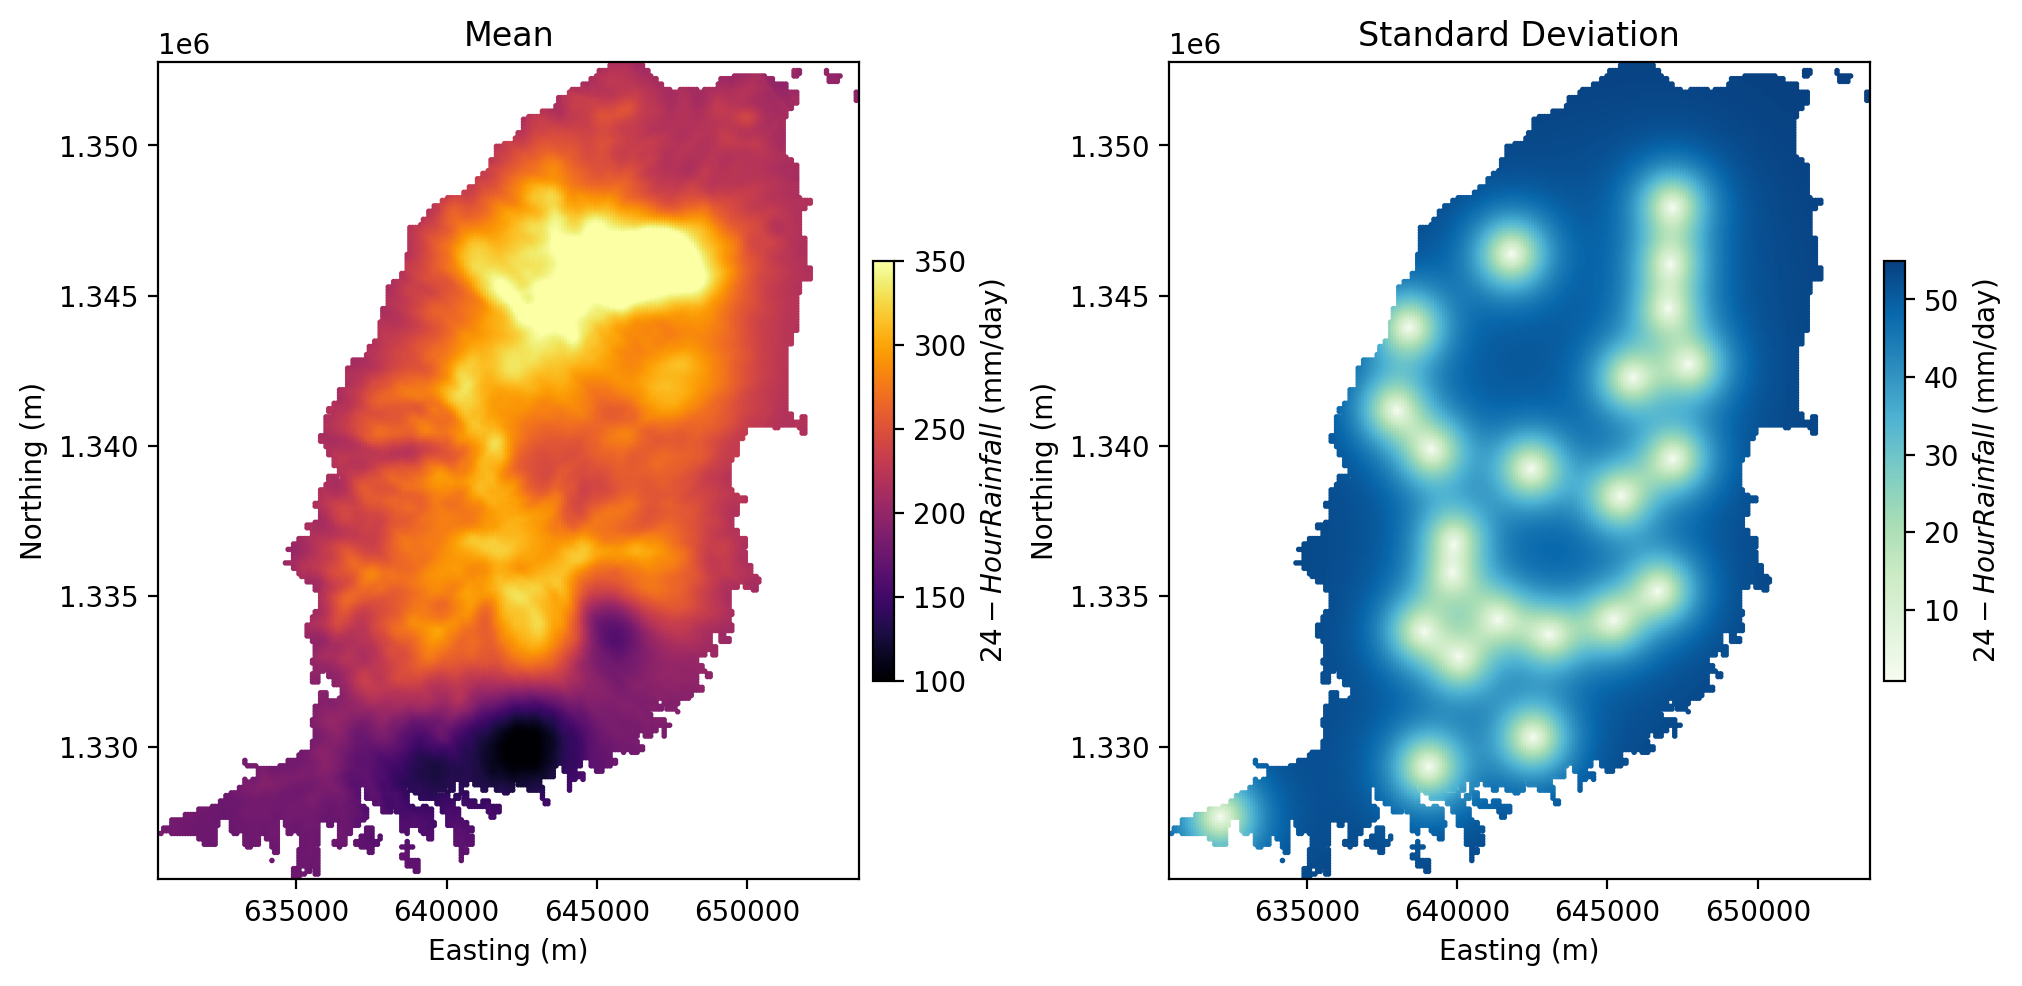

In [316]:
# use bestfit structures
structures = best_fit["structures"]

if not run_loo:
    est_ock, var_ock = ordinary_cokriging(
        primary_values=values['TR_z'].to_numpy(),
        primary_coords=values[["X_km", "Y_km"]].to_numpy(),
        secondary_values=elev["Elev_z"].to_numpy(),
        secondary_coords=elev[["X_km", "Y_km"]].to_numpy(),
        targets=elev[["X_km", "Y_km"]].to_numpy(),
        covariance_mode="lmc",
        structures=structures,
        distance_type="cartesian",
        rotation_matrix=None,
        standardize=True,
        jitter=1e-10,
        check_positive_definite=True,
        return_weights=False,
        max_neighbors_secondary=256,
        max_neighbors_primary=256,
    )

    fig, ax = plt.subplots(1, 2, figsize=(10, 6), dpi=200, constrained_layout=True)
    im1 = ax[0].scatter(
        elev["X_m"], elev["Y_m"],
        s=1, c=est_ock * sig_values + mu_values,
        cmap="inferno", vmin=100, vmax=350
    )
    im2 = ax[1].scatter(
        elev["X_m"], elev["Y_m"],
        s=1, c=np.sqrt(var_ock) * sig_values,
        cmap="GnBu"
    )
    ax[0].set_title("Mean")
    ax[1].set_title("Standard Deviation")
    xmin = elev["X_m"].min()
    xmax = elev["X_m"].max()
    ymin = elev["Y_m"].min()
    ymax = elev["Y_m"].max()
    for a in ax:
        a.set_aspect("equal")
        a.set_xlim(xmin, xmax)
        a.set_ylim(ymin, ymax)
        a.set_xlabel("Easting (m)")
        a.set_ylabel("Northing (m)")
    cbar1 = fig.colorbar(im1, ax=ax[0], orientation="vertical",fraction=0.03, pad=0.02)
    cbar1.set_label(r"$24-Hour Rainfall$ (mm/day)")
    cbar2 = fig.colorbar(im2, ax=ax[1], orientation="vertical",fraction=0.03, pad=0.02)
    cbar2.set_label(r"$24-Hour Rainfall$ (mm/day)")
    plt.show()

else:
    mu_list = []
    std_error_list = []
    dmin_list = []

    for sta in tqdm(values.station.tolist(), desc="LOO", total=len(values)):

        # Split into left-out station and training set
        sta_i = values[values.station == sta].reset_index(drop=True)
        sta_j = values[values.station != sta].reset_index(drop=True)

        # nearest neighbour distance (km)
        dx = sta_i.X_km.values - sta_j.X_km.values
        dy = sta_i.Y_km.values - sta_j.Y_km.values
        dmin = np.min(np.sqrt(dx*dx + dy*dy))
        dmin_list.append(dmin)

        est_ock, var_ock = ordinary_cokriging(
            primary_values=sta_j['TR_z'].to_numpy(),
            primary_coords=sta_j[["X_km", "Y_km"]].to_numpy(),
            secondary_values = sta_j["Elev_z"].to_numpy(),
            secondary_coords = sta_j[["X_km", "Y_km"]].to_numpy(),
            targets=sta_i[["X_km", "Y_km"]].to_numpy(),
            covariance_mode="lmc",
            structures=structures,
            distance_type="cartesian",
            rotation_matrix=None,
            standardize=True,
            jitter=1e-10,
            check_positive_definite=True,
            return_weights=False,
            show_progress=False,
        )

        # store values
        est_val   = est_ock.item()
        var_val   = var_ock.item()

        # store values
        mu_list.append(est_val * sig_values + mu_values)
        std_error_list.append(np.sqrt(var_val) * sig_values)

    # append to dataframe
    values['dmin'] = dmin_list
    values['ock_TR_mu'] = mu_list
    values['ock_TR_std'] = std_error_list

## 5.4 RMSE

In [317]:
if run_loo:

    # Model dictionary with mean + std columns
    models = {
        "Ordinary Kriging": {
            "mu": "ok_TR_mu",
            "std": "ok_TR_std",
        },
        "Ordinary CoKriging": {
            "mu": "ock_TR_mu",
            "std": "ock_TR_std",
        },
        "Intrinsic Collocated CoKriging Markov Model 1": {
            "mu": "oicckm1_TR_mu",
            "std": "oicckm1_TR_std",
        },
        "Intrinsic Collocated CoKriging Markov Model 2": {
            "mu": "oicckm2_TR_mu",
            "std": "oicckm2_TR_std",
        },
    }

    truth = values["TR_mean"].to_numpy()

    # Compute metrics
    metrics_dict = {}

    for name, cols in models.items():
        est = values[cols["mu"]].to_numpy()
        rmse = np.sqrt(mean_squared_error(truth, est))
        mae  = mean_absolute_error(truth, est)
        bias = np.mean(est - truth)
        metrics_dict[name] = {
            "RMSE": rmse,
            "MAE": mae,
            "BIAS": bias,
        }

    # Plotting
    fig, ax = plt.subplots(2, 2, figsize=(8, 8),dpi=150, constrained_layout=True,sharex=True, sharey=True)
    ax = ax.flatten()
    x45 = np.linspace(truth.min(), truth.max(), 200)

    for i, (name, cols) in enumerate(models.items()):
        est = values[cols["mu"]].to_numpy()
        std = values[cols["std"]].to_numpy()
        rmse = metrics_dict[name]["RMSE"]
        mae  = metrics_dict[name]["MAE"]
        bias = metrics_dict[name]["BIAS"]

        # Horizontal error bars (estimate uncertainty)
        ax[i].errorbar(
            est, truth,
            xerr=std,
            fmt='o',
            markersize=3,
            color="black",
            ecolor="gray",
            elinewidth=0.8,
            alpha=0.8,
        )

        # Regression line
        p = np.poly1d(np.polyfit(truth, est, 1))
        ax[i].plot(truth, p(truth), color="red")

        # 1:1 line
        ax[i].plot(x45, x45, color="blue")
        ax[i].set_aspect("equal", "box")
        ax[i].set_title(name, fontsize=10)
        ax[i].text(0.05, 0.92, f"RMSE = {rmse:.2f}", transform=ax[i].transAxes, fontsize=9)
        ax[i].text(0.05, 0.84, f"MAE  = {mae:.2f}",  transform=ax[i].transAxes, fontsize=9)
        ax[i].text(0.05, 0.76, f"Bias = {bias:.2f}", transform=ax[i].transAxes, fontsize=9)
    for j in range(i + 1, len(ax)):
        fig.delaxes(ax[j])
    fig.supxlabel("Estimate", fontsize=14)
    fig.supylabel("Truth", fontsize=14)
    plt.show()

# 6.0 Variogram and cross-variograms for rainfall extremes: standard deviation

## 6.1 Rainfall standard deviation extremes variograms

### 6.1.1 Multi-variograms across all return periods (TR)

In [ ]:
# specify fitting parameters
estimator = "Matheron"
model = "powered_exponential"
weight_fn = None
weight_params = None
xmax_factor = 2

summary_gev, df_n_obs, df_gamma, results = variofitmulti(
    df=gev_long,
    values_col="TR_std_z",
    index_col="TR",
    coord_cols=("X_km","Y_km"),
    distance_type="cartesian",
    max_distance=15,
    bin_size=3,
    estimator_type=estimator,
    model_type=model,
    weight_fn=weight_fn,
    weight_params = weight_params,
    xmax_factor=xmax_factor,
    fix_sill= True,
    plot_single=False,
    plot_summary=True,
    transform="correlation"
)

summary_gpd, df_n_obs, df_gamma, results = variofitmulti(
    df=gpd_long,
    values_col="TR_std_z",
    index_col="TR",
    coord_cols=("X_km","Y_km"),
    distance_type="cartesian",
    max_distance=15,
    bin_size=3,
    estimator_type=estimator,
    model_type=model,
    weight_fn=weight_fn,
    weight_params = weight_params,
    xmax_factor=xmax_factor,
    fix_sill= True,
    plot_single=False,
    plot_summary=True,
    transform="correlation"
)

### 6.1.2 Single variograms: GPD and GEV

In [ ]:
# specify fitting parameters
estimator = "Matheron"
model = "powered_exponential"
weight_fn = None
weight_params = None
xmax_factor = 2

_, _, _, params_trstd25_gpd, _, _ = variofit(values = TR_25_gpd['TR_std_z'], coordinates = TR_25_gpd[['X_km','Y_km']], distance_type = 'cartesian', max_distance = 15, bin_size = 3, estimator_type= estimator, model_type = model, weight_fn = weight_fn, weight_params = weight_params, xmax_factor=xmax_factor, fix_sill = True, plot = True, transform="correlation")

_, _, _, params_trstd25_gev, _, _ = variofit(values = TR_25_gev['TR_std_z'], coordinates = TR_25_gev[['X_km','Y_km']], distance_type = 'cartesian', max_distance = 15, bin_size = 3, estimator_type= estimator, model_type = model, weight_fn = weight_fn, weight_params = weight_params, xmax_factor=xmax_factor, fix_sill = True, plot = True, transform="correlation")

## 6.2 Secondary and cross-variograms

In [ ]:
# specify fitting parameters
estimator = "Matheron"
model = "powered_exponential"
weight_fn = None
weight_params = None
xmax_factor = 2

# primary data
h_lag_primary_std, n_obs_primary_std, gamma_primary_std, params_primary_std, _, _ = variofit(values = TR_25_gev['TR_std_z'], coordinates = TR_25_gev[['X_km','Y_km']], distance_type = 'cartesian', max_distance = 15, bin_size = 3, estimator_type= estimator, model_type = model, weight_fn = weight_fn, weight_params = weight_params, xmax_factor=xmax_factor, fix_sill = True ,plot = True, transform="correlation")

# secondary data
h_lag_secondary_std, n_obs_secondary_std, gamma_secondary_std, params_secondary_std, _, _ = variofit(values = elev['Elev_z'], coordinates = elev[['X_km','Y_km']], distance_type = 'cartesian', max_distance = 15, bin_size = 3, estimator_type= estimator, model_type = model, weight_fn = weight_fn, weight_params = weight_params, xmax_factor=xmax_factor, fix_sill = True, fix_nugget = True , plot = True, transform="correlation")

# crossvariogram
h_lag_cross_std, n_obs_cross_std, gamma12_cross_std, params_cross_std, _, _ = crossvariofit(values1=TR_25_gev['TR_std_z'],values2=TR_25_gev['Elev_z'],coordinates=TR_25_gev[['X_km','Y_km']] ,distance_type="cartesian", max_distance=15, bin_size=3, estimator_type=estimator, model_type=model,weight_fn=weight_fn,weight_params=weight_params,fix_nugget=True,fix_sill=True,allow_negative_sill=False, plot=True, transform="correlation"
)

## 6.3 Linear Model of Coregionalization

In [ ]:
h_common, rz_common, ry_common, rzy_common, wz_common, wy_common, wzy_common = align_lmc_experimental_bins(
    h_primary=h_lag_primary_std,
    rho_primary=gamma_primary_std,
    n_primary=n_obs_primary_std,
    h_secondary=h_lag_secondary_std,
    rho_secondary=gamma_secondary_std,
    n_secondary=n_obs_secondary_std,
    h_cross=h_lag_cross_std,
    rho_cross=gamma12_cross_std,
    n_cross=n_obs_cross_std,
)

rho0_target = estimate_collocated_correlation(
    TR_25_gev['TR_std_z'].to_numpy(),
    TR_25_gev['Elev_z'].to_numpy(),
    method="pearson",
)

search_res = search_lmc_model_space(
    h_common,
    rz_common,
    ry_common,
    rzy_common,
    fixed_structures=None,
    model_family="variogram",
    model_type=model,                 # e.g. "powered_exponential"
    params_primary=params_primary_std,
    params_secondary=params_secondary_std,
    params_cross=params_cross_std,
    n_ranges=9,
    range_spacing="linear",
    range_padding_frac=0.1,
    include_direct_ranges=True,
    include_shape_average=True,
    n_structures=2,
    allow_repeated_kernels=False,
    w_primary=wz_common,
    w_secondary=wy_common,
    w_cross=wzy_common,
    rho0_bounds=[0.2,0.6],
    rho0_target=None,
    cross_misfit_weight_grid=[0.25, 0.5, 1.0, 2.0, 5.0],
    rho0_penalty_weight_grid=[0.0, 1.0, 10.0, 100.0, 1000.0, 1e4],
    normalize_weights=True,
    plot_best=True,
    verbose=False,
)

best = search_res["best"]
best_fit = best["fit"]

print("best objective =", best["objective"])
print("best rho0_fit =", best["rho0_fit"])
print("best feasible =", best["is_feasible"])
print("best n_bad_total =", best["n_bad_total"])

## 6.4 Residual correlograms

In [ ]:
# get correlation between primary and secondary variables
rho0_target = estimate_collocated_correlation(
    TR_25_gev['TR_std_z'].to_numpy(),
    TR_25_gev['Elev_z'].to_numpy(),
    method="pearson",
)

# rho0_target = 0.35

# Collocated sample pairs at primary locations
z_pair = TR_25_gev['TR_std_z'].to_numpy(dtype=float)
y_pair = TR_25_gev['Elev_z'].to_numpy(dtype=float)
xy_pair = TR_25_gev[["X_km", "Y_km"]].to_numpy()

# Standardize using one consistent reference
mu_z = z_pair.mean()
sd_z = z_pair.std(ddof=0)
mu_y = y_pair.mean()
sd_y = y_pair.std(ddof=0)

z_std = (z_pair - mu_z) / sd_z
y_std = (y_pair - mu_y) / sd_y

# MM2 residual variable
r_mm2 = (z_std - rho0_target * y_std) / np.sqrt(1.0 - rho0_target**2)

# Fit direct correlogram model for the residual variable
h_lag_resid_std, n_obs_resid_std, rho_resid_emp_std, params_resid_std, r2_wls_resid_std, r2_ols_resid_std = variofit(
    values=r_mm2,
    coordinates=xy_pair,
    distance_type="cartesian",
    max_distance=15,
    bin_size=3,
    estimator_type=estimator,
    model_type=model,
    weight_fn=weight_fn,
    weight_params=weight_params,
    xmax_factor=xmax_factor,
    fix_sill=True,
    fix_nugget=False,
    plot=True,
    transform="correlation",
)

# make models from correlograms
primary_model = make_covmodel_spec(
    model_family="variogram",
    model_type="powered_exponential",
    params=params_primary_std,
)

secondary_model = make_covmodel_spec(
    model_family="variogram",
    model_type="powered_exponential",
    params=params_secondary_std,
)

residual_model = make_covmodel_spec(
    model_family="variogram",
    model_type="powered_exponential",
    params=params_resid_std,
)

## 6.5 Kriging: Ordinary Cokriging and Ordinary Intrinsic Co-located Kriging

### 6.5.1 Create dataset

In [ ]:
run_loo = True
values = TR_50_gev
mu_values = values['TR_std'].mean()
sig_values = values['TR_std'].std(ddof=0)
# values = values[~(values.station.isin(["Radix (WTP)", "Bon Accord (WTP)","Peggy's Whim (WTP)", "Blaize (TANK)", "Grand Etang (LAKE)", "Clozier (Tank)","Plaisance (WTP)", "Munich (WTP)"]))].reset_index(drop=True)
values = values[~(values.station.isin(["Radix (WTP)", "Bon Accord (WTP)", "Blaize (TANK)", "Grand Etang (LAKE)", "Clozier (Tank)","Plaisance (WTP)", "Munich (WTP)"]))].reset_index(drop=True)

### 6.5.2 Ordinary Intrinsic Co-located Kriging M1

In [ ]:
# ICCK MM1
if not run_loo:
    est_mm1, var_mm1 = OICCK_MM1(
        primary_values=values['TR_std_z'].to_numpy(),
        primary_coords=values[["X_km", "Y_km"]].to_numpy(),
        secondary_values=values["Elev_z"].to_numpy(),
        secondary_coords=values[["X_km", "Y_km"]].to_numpy(),
        collocated_secondary_values=elev["Elev_z"].to_numpy(),
        targets=elev[["X_km", "Y_km"]].to_numpy(),
        rho0=rho0_target,
        primary_model=primary_model,
        secondary_values_for_standardization=values["Elev_z"].to_numpy(),
        distance_type="cartesian",
        rotation_matrix=None,
        standardize=True,
        jitter=1e-10,
        check_positive_definite=True,
        return_weights=False,
        show_progress=True
    )

    fig, ax = plt.subplots(1, 2, figsize=(10, 6), dpi=200, constrained_layout=True)
    im1 = ax[0].scatter(
        elev["X_m"], elev["Y_m"],
        s=1, c=est_mm1 * sig_values + mu_values,
        cmap="inferno", vmin=30, vmax=160
    )

    im2 = ax[1].scatter(
        elev["X_m"], elev["Y_m"],
        s=1, c=np.sqrt(var_mm1) * sig_values,
        cmap="GnBu"
    )
    ax[0].set_title("Mean")
    ax[1].set_title("Standard Deviation")
    xmin = elev["X_m"].min()
    xmax = elev["X_m"].max()
    ymin = elev["Y_m"].min()
    ymax = elev["Y_m"].max()

    for a in ax:
        a.set_aspect("equal")
        a.set_xlim(xmin, xmax)
        a.set_ylim(ymin, ymax)
        a.set_xlabel("Easting (m)")
        a.set_ylabel("Northing (m)")

    cbar1 = fig.colorbar(im1, ax=ax[0], orientation="vertical",
                         fraction=0.03, pad=0.02)
    cbar1.set_label(r"$\sigma_{24-Hour Rainfall}$ (mm/day)")
    cbar2 = fig.colorbar(im2, ax=ax[1], orientation="vertical",
                         fraction=0.03, pad=0.02)
    cbar2.set_label(r"$\sigma_{24-Hour Rainfall}$ (mm/day)")
    plt.show()

else:
    mu_list = []
    std_error_list = []
    dmin_list = []

    for sta in tqdm(values.station.tolist(), desc="LOO", total=len(values)):

        # Split into left-out station and training set
        sta_i = values[values.station == sta].reset_index(drop=True)
        sta_j = values[values.station != sta].reset_index(drop=True)

        # nearest neighbour distance (km)
        dx = sta_i.X_km.values - sta_j.X_km.values
        dy = sta_i.Y_km.values - sta_j.Y_km.values
        dmin = np.min(np.sqrt(dx*dx + dy*dy))
        dmin_list.append(dmin)

        # ICCK-MM1 prediction at the left-out station
        est_mm1, var_mm1 = OICCK_MM1(
            primary_values=sta_j['TR_std_z'].to_numpy(),
            primary_coords=sta_j[["X_km", "Y_km"]].to_numpy(),
            secondary_values=sta_j["Elev_z"].to_numpy(),
            secondary_coords=sta_j[["X_km", "Y_km"]].to_numpy(),
            collocated_secondary_values=sta_i["Elev_z"].to_numpy(),
            targets=sta_i[["X_km", "Y_km"]].to_numpy(),
            rho0=rho0_target,
            primary_model=primary_model,
            secondary_values_for_standardization=sta_j["Elev_z"].to_numpy(),
            distance_type="cartesian",
            rotation_matrix=None,
            standardize=True,
            jitter=1e-10,
            check_positive_definite=True,
            return_weights=False,
            show_progress=False
        )

        # est_mm1 and var_mm1 are length-1 arrays
        est_val = est_mm1[0]
        var_val = var_mm1[0]

        # back-transform
        mu_list.append(est_val * sig_values + mu_values)
        std_error_list.append(np.sqrt(var_val) * sig_values)

    # append to dataframe
    values['dmin'] = dmin_list
    values['oicckm1_TR_std_mu'] = mu_list
    values['oicckm1_TR_std_std'] = std_error_list

### 6.5.3 Ordinary Intrinsic Co-located Kriging M2

In [ ]:
# ICCK MM2
if not run_loo:
    est_mm2, var_mm2 = OICCK_MM2(
        primary_values=values['TR_std_z'].to_numpy(),
        primary_coords=values[["X_km", "Y_km"]].to_numpy(),
        secondary_values=values["Elev_z"].to_numpy(),
        secondary_coords=values[["X_km", "Y_km"]].to_numpy(),
        collocated_secondary_values=elev["Elev_z"].to_numpy(),
        targets=elev[["X_km", "Y_km"]].to_numpy(),
        rho0=rho0_target,
        secondary_model=secondary_model,
        residual_model=residual_model,
        secondary_values_for_standardization=values["Elev_z"].to_numpy(),
        distance_type="cartesian",
        rotation_matrix=None,
        standardize=True,
        jitter=1e-10,
        check_positive_definite=True,
        return_weights=False,
        show_progress=True
    )

    fig, ax = plt.subplots(1, 2, figsize=(10, 6), dpi=200, constrained_layout=True)
    im1 = ax[0].scatter(
        elev["X_m"], elev["Y_m"],
        s=1, c=est_mm2 * sig_values + mu_values,
        cmap="inferno", vmin=30, vmax=160
    )
    im2 = ax[1].scatter(
        elev["X_m"], elev["Y_m"],
        s=1, c=np.sqrt(var_mm2) * sig_values,
        cmap="GnBu"
    )
    ax[0].set_title("Mean")
    ax[1].set_title("Standard Deviation")
    xmin = elev["X_m"].min()
    xmax = elev["X_m"].max()
    ymin = elev["Y_m"].min()
    ymax = elev["Y_m"].max()
    for a in ax:
        a.set_aspect("equal")
        a.set_xlim(xmin, xmax)
        a.set_ylim(ymin, ymax)
        a.set_xlabel("Easting (m)")
        a.set_ylabel("Northing (m)")
    cbar1 = fig.colorbar(im1, ax=ax[0], orientation="vertical",fraction=0.03, pad=0.02)
    cbar1.set_label(r"$\sigma_{24-Hour Rainfall}$ (mm/day)")
    cbar2 = fig.colorbar(im2, ax=ax[1], orientation="vertical",fraction=0.03, pad=0.02)
    cbar2.set_label(r"$\sigma_{24-Hour Rainfall}$ (mm/day)")
    plt.show()

else:
    mu_list = []
    std_error_list = []
    dmin_list = []

    for sta in tqdm(values.station.tolist(), desc="LOO", total=len(values)):

        # Split into left-out station and training set
        sta_i = values[values.station == sta].reset_index(drop=True)
        sta_j = values[values.station != sta].reset_index(drop=True)

        # nearest neighbour distance (km)
        dx = sta_i.X_km.values - sta_j.X_km.values
        dy = sta_i.Y_km.values - sta_j.Y_km.values
        dmin = np.min(np.sqrt(dx*dx + dy*dy))
        dmin_list.append(dmin)

        # ICCK-MM2 prediction at the left-out station
        est_mm2, var_mm2 = OICCK_MM2(
            primary_values=sta_j['TR_std_z'].to_numpy(),
            primary_coords=sta_j[["X_km", "Y_km"]].to_numpy(),
            secondary_values=sta_j["Elev_z"].to_numpy(),
            secondary_coords=sta_j[["X_km", "Y_km"]].to_numpy(),
            collocated_secondary_values=sta_i["Elev_z"].to_numpy(),
            targets=sta_i[["X_km", "Y_km"]].to_numpy(),
            rho0=rho0_target,
            secondary_model=secondary_model,
            residual_model=residual_model,
            secondary_values_for_standardization=sta_j["Elev_z"].to_numpy(),
            distance_type="cartesian",
            rotation_matrix=None,
            standardize=True,
            jitter=1e-10,
            check_positive_definite=True,
            return_weights=False,
            show_progress=False
        )

        # est_mm2 and var_mm2 are length-1 arrays
        est_val = est_mm2[0]
        var_val = var_mm2[0]

        # back-transform
        mu_list.append(est_val * sig_values + mu_values)
        std_error_list.append(np.sqrt(var_val) * sig_values)

    # append to dataframe
    values['dmin'] = dmin_list
    values['oicckm2_TR_std_mu'] = mu_list
    values['oicckm2_TR_std_std'] = std_error_list

### 6.5.4 Ordinary Cokriging

In [ ]:
# use bestfit structures
structures = best_fit["structures"]

if not run_loo:
    est_ock, var_ock = ordinary_cokriging(
        primary_values=values['TR_std_z'].to_numpy(),
        primary_coords=values[["X_km", "Y_km"]].to_numpy(),
        secondary_values=elev["Elev_z"].to_numpy(),
        secondary_coords=elev[["X_km", "Y_km"]].to_numpy(),
        targets=elev[["X_km", "Y_km"]].to_numpy(),
        covariance_mode="lmc",
        structures=structures,
        distance_type="cartesian",
        rotation_matrix=None,
        standardize=True,
        jitter=1e-10,
        check_positive_definite=True,
        return_weights=False,
        max_neighbors_secondary=256,
        max_neighbors_primary=256,
    )

    fig, ax = plt.subplots(1, 2, figsize=(10, 6), dpi=200, constrained_layout=True)
    im1 = ax[0].scatter(
        elev["X_m"], elev["Y_m"],
        s=1, c=est_ock * sig_values + mu_values,
        cmap="inferno", vmin=30, vmax=160
    )
    im2 = ax[1].scatter(
        elev["X_m"], elev["Y_m"],
        s=1, c=np.sqrt(var_ock) * sig_values,
        cmap="GnBu"
    )
    ax[0].set_title("Mean")
    ax[1].set_title("Standard Deviation")
    xmin = elev["X_m"].min()
    xmax = elev["X_m"].max()
    ymin = elev["Y_m"].min()
    ymax = elev["Y_m"].max()
    for a in ax:
        a.set_aspect("equal")
        a.set_xlim(xmin, xmax)
        a.set_ylim(ymin, ymax)
        a.set_xlabel("Easting (m)")
        a.set_ylabel("Northing (m)")
    cbar1 = fig.colorbar(im1, ax=ax[0], orientation="vertical",fraction=0.03, pad=0.02)
    cbar1.set_label(r"$\sigma_{24-Hour Rainfall}$ (mm/day)")
    cbar2 = fig.colorbar(im2, ax=ax[1], orientation="vertical",fraction=0.03, pad=0.02)
    cbar2.set_label(r"$\sigma_{24-Hour Rainfall}$ (mm/day)")
    plt.show()

else:
    mu_list = []
    std_error_list = []
    dmin_list = []

    for sta in tqdm(values.station.tolist(), desc="LOO", total=len(values)):

        # Split into left-out station and training set
        sta_i = values[values.station == sta].reset_index(drop=True)
        sta_j = values[values.station != sta].reset_index(drop=True)

        # nearest neighbour distance (km)
        dx = sta_i.X_km.values - sta_j.X_km.values
        dy = sta_i.Y_km.values - sta_j.Y_km.values
        dmin = np.min(np.sqrt(dx*dx + dy*dy))
        dmin_list.append(dmin)

        est_ock, var_ock = ordinary_cokriging(
            primary_values=sta_j['TR_std_z'].to_numpy(),
            primary_coords=sta_j[["X_km", "Y_km"]].to_numpy(),
            secondary_values = sta_j["Elev_z"].to_numpy(),
            secondary_coords = sta_j[["X_km", "Y_km"]].to_numpy(),
            targets=sta_i[["X_km", "Y_km"]].to_numpy(),
            covariance_mode="lmc",
            structures=structures,
            distance_type="cartesian",
            rotation_matrix=None,
            standardize=True,
            jitter=1e-10,
            check_positive_definite=True,
            return_weights=False,
            show_progress=False,
        )

        # store values
        est_val   = est_ock.item()
        var_val   = var_ock.item()

        # store values
        mu_list.append(est_val * sig_values + mu_values)
        std_error_list.append(np.sqrt(var_val) * sig_values)

    # append to dataframe
    values['dmin'] = dmin_list
    values['ock_TR_std_mu'] = mu_list
    values['ock_TR_std_std'] = std_error_list

### 6.5.5 RMSE

In [ ]:
if run_loo:

    # Model dictionary with mean + std columns
    models = {
        "Ordinary CoKriging": {
            "mu": "ock_TR_std_mu",
            "std": "ock_TR_std_std",
        },
        "Intrinsic Collocated CoKriging Markov Model 1": {
            "mu": "oicckm1_TR_std_mu",
            "std": "oicckm1_TR_std_std",
        },
        "Intrinsic Collocated CoKriging Markov Model 2": {
            "mu": "oicckm2_TR_std_mu",
            "std": "oicckm2_TR_std_std",
        },
    }

    truth = values["TR_std"].to_numpy()

    # Compute metrics
    metrics_dict = {}

    for name, cols in models.items():
        est = values[cols["mu"]].to_numpy()
        rmse = np.sqrt(mean_squared_error(truth, est))
        mae  = mean_absolute_error(truth, est)
        bias = np.mean(est - truth)
        metrics_dict[name] = {
            "RMSE": rmse,
            "MAE": mae,
            "BIAS": bias,
        }

    # Plotting
    fig, ax = plt.subplots(1, 3, figsize=(12, 8), dpi=150, sharex=True, sharey=True, constrained_layout=True)
    ax = ax.flatten()
    x45 = np.linspace(truth.min(), truth.max(), 200)

    for i, (name, cols) in enumerate(models.items()):
        est = values[cols["mu"]].to_numpy()
        std = values[cols["std"]].to_numpy()
        rmse = metrics_dict[name]["RMSE"]
        mae  = metrics_dict[name]["MAE"]
        bias = metrics_dict[name]["BIAS"]

        # Horizontal error bars (estimate uncertainty)
        ax[i].errorbar(
            est, truth,
            xerr=std,
            fmt='o',
            markersize=3,
            color="black",
            ecolor="gray",
            elinewidth=0.8,
            alpha=0.8,
        )

        # Regression line
        p = np.poly1d(np.polyfit(truth, est, 1))
        ax[i].plot(truth, p(truth), color="red")

        # 1:1 line
        ax[i].plot(x45, x45, color="blue")
        ax[i].set_aspect("equal", "box")
        ax[i].set_title(name, fontsize=10)
        ax[i].text(0.05, 0.92, f"RMSE = {rmse:.2f}", transform=ax[i].transAxes, fontsize=9)
        ax[i].text(0.05, 0.84, f"MAE  = {mae:.2f}",  transform=ax[i].transAxes, fontsize=9)
        ax[i].text(0.05, 0.76, f"Bias = {bias:.2f}", transform=ax[i].transAxes, fontsize=9)
        ax[i].set_xlabel("Estimate")
    for j in range(i + 1, len(ax)):
        fig.delaxes(ax[j])
    ax[0].set_ylabel("Truth")
    plt.show()